# Подготовка данных

In [288]:
import seaborn as sns
from matplotlib import pyplot as plt
import ast
import pandas as pd
import math

class Experiment:
    def __init__(self, df, method):
        self.df = df
        self.method = method

    def add_probas(self, df_langproba, dropped_cols):
        self.df.drop(columns=df_langproba.columns, errors='ignore', inplace=True)
        self.df = pd.concat([self.df, df_langproba.drop(columns=dropped_cols)], axis=1)
        self.fillna_0()

    def fillna_0(self):
        new_cols = self.df.filter(regex=self.method).select_dtypes(include=['float64']).columns

        self.df[new_cols] = self.df[new_cols].fillna(0)

    def visualize_probas(self, target_col='manual_tag'):
        sns.set()

        fig, axes = plt.subplots(1, 2,figsize=(10,5))
        axes = axes.flatten()

        sns.set(style='whitegrid')

        sns.scatterplot(ax=axes[0], data=self.df, x=f'{self.method}__kaz', y=f'{self.method}__rus', hue=target_col)

        sns.kdeplot(ax=axes[1], data=self.df[[f'{self.method}__kaz', f'{self.method}__rus']])

        fig.suptitle(self.method)

    def save_experiment(self, path):
        self.df.to_csv(path, index=False)

def visualize_tags(df, method, manual_col='manual_tag', x_lang='kaz', y_lang='rus'):
    sns.set()

    nrows = math.ceil(len(df[manual_col].unique())/2)

    fig, axes = plt.subplots(nrows, 2, sharex=True, sharey=True,figsize=(10,nrows*5))
    axes = axes.flatten()

    sns.set(style='whitegrid')

    for i, tag in enumerate(df[manual_col].unique()):
        sns.scatterplot(ax=axes[i], data=df[df[manual_col]==tag], x=f'{method}__{x_lang}', y=f'{method}__{y_lang}')
        axes[i].set_title(tag)

    fig.suptitle(f'Распределение вероятностей для казахского (x) и русского (y), полученных с помощью метода {method}, для каждого "ручного" тега')

In [289]:
import numpy as np

def assign_weights(cond1, cond2):

    choices = [
        cond1,
        cond2
    ]

    conditions = [
        1, # cond1
        -1 # cond2
    ]

    return np.select(choices, conditions, default=0)

In [290]:
def sort_labels(lst):
    order = {
        'lat_kz': 0,
        'kz': 1,
        'skz': 2,
        'ru': 3,
        'en': 4,
        'unk': 5,
    }
    return sorted(lst, key=order.get)

In [486]:
import pandas as pd
df = pd.read_csv(
    'https://docs.google.com/spreadsheets/d/' +
    '1pIV0z6GWbt_xTweBXHIUXmU4K-84XiTseFbobv7K_xE' +
    '/export?gid=1459857604&format=csv'
)
exprmnt = Experiment(df=df, method='analysis')

# устанавливаем веса
# нам нужно убрать все теги, которые не включают казахский или русский, и при этом нам очень важно не потерять тексты с CSW
choices = [
    exprmnt.df['manual_tag'].str.contains('^kz-ru'),
    exprmnt.df['manual_tag']== 'unk'
]

conditions = [
    1,
    -1
]
exprmnt.df['weight'] = np.select(choices, conditions, default=0)

exprmnt.df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9699 entries, 0 to 9698
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   text                        9699 non-null   object 
 1   manual_tag                  9699 non-null   object 
 2   cld2__all_langs             9699 non-null   object 
 3   cld2__best_lang             9699 non-null   object 
 4   cld2__kaz                   9699 non-null   float64
 5   cld2__rus                   9699 non-null   float64
 6   cld3__best_lang             9699 non-null   object 
 7   cld3__kaz                   9699 non-null   float64
 8   cld3__rus                   9699 non-null   float64
 9   langid__best_lang           9699 non-null   object 
 10  langid__kaz                 9699 non-null   float64
 11  langid__rus                 9699 non-null   float64
 12  lingua__best_lang           9699 non-null   object 
 13  lingua__kaz                 9699 

In [487]:
exprmnt.df.groupby(['weight', 'manual_tag'])['text'].count()

weight  manual_tag
-1      unk             43
 0      kz            3158
        kz-unk         113
        ru            5407
        ru-unk          71
        skz            174
        skz-ru         187
        skz-ru-unk       3
        skz-unk          4
 1      kz-ru          523
        kz-ru-unk       16
Name: text, dtype: int64

In [488]:
# распределение ручных тегов
df['manual_tag'].value_counts() / len(df)

,count
manual_tag,
ru,0.557480
kz,0.325601
kz-ru,0.053923
skz-ru,0.019280
skz,0.017940
kz-unk,0.011651
ru-unk,0.007320
unk,0.004433
kz-ru-unk,0.001650


In [489]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

from sklearn.metrics import classification_report, accuracy_score, precision_recall_curve
from sklearn.metrics import f1_score

import pandas as pd
import numpy as np

In [490]:
# !pip install langcodes
# !pip install language_data

In [491]:
from langcodes import Language

def get_lang_name(s):
    """
    Функция возвращает полное название для языкового кода
    """
    if len(s)>3:
        return s.lower()

    if s == 'kz':
        s = 'kk'
    res = Language.get(s).display_name().lower()

    if res.startswith('unknown') or s == 'unk':
        return s
    return res

In [492]:
# расшифровываем названия языков
cols = df.filter(regex='best_lang').columns

for c in cols:
    if c.startswith('glotlid') or c.startswith('fasttext'):
        df[c] = df[c].str.replace('__label__', '')
        df[c] = df[c].str.replace('_Cyrl', '')
    df[c] = df[c].apply(get_lang_name)

## Согласованность предсказаний (Альфа Криппендорфа)

In [297]:
!pip install krippendorff

In [298]:
import krippendorff

In [299]:
from collections import defaultdict
lang2n = set()
for c in cols:
    lang2n.update(df[c].unique())
lang2n = dict(zip(lang2n, range(len(lang2n))))

In [301]:
lang2n_simpl = {k: 0 for k,v in lang2n.items()}
lang2n_simpl['kazakh'] = 1
lang2n_simpl['russian'] = 2

In [308]:
import krippendorff

data_numeric = df[df['manual_tag'].isin(['kz', 'ru', 'unk', 'skz'])][cols].replace(lang2n_simpl).values

alpha = krippendorff.alpha(
    reliability_data=data_numeric,
    level_of_measurement='nominal'
)

print(f"Альфа Криппендорфа для одноязычных текстов (теги сгруппированы): {alpha:.4f}")

/tmp/ipykernel_30641/1352313505.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_numeric = df[df['manual_tag'].isin(['kz', 'ru', 'unk', 'skz'])][cols].replace(lang2n_simpl).values


Альфа Криппендорфа для одноязычных текстов (теги сгруппированы): 0.0031


Значение очень мало, что говорит о несогласовонности, большом разнообразии предсказаний.

# Эксперимент 1. Отсеивание нерелевантных текстов

В данном эксперименте мы попытались проанализировать, возможно ли надежно выявлять тексты с переключением кодов с помощью существующих моделей LID. Для эксперимента мы отобрали 7 методов, поддерживающих казахский и русский языки. В дополнение мы имплементировали собственный словарный метод.

## Словарный метод

- https://github.com/kergalym/myspell-kk/tree/upstream
- https://github.com/wooorm
- hunspell

### Анализ

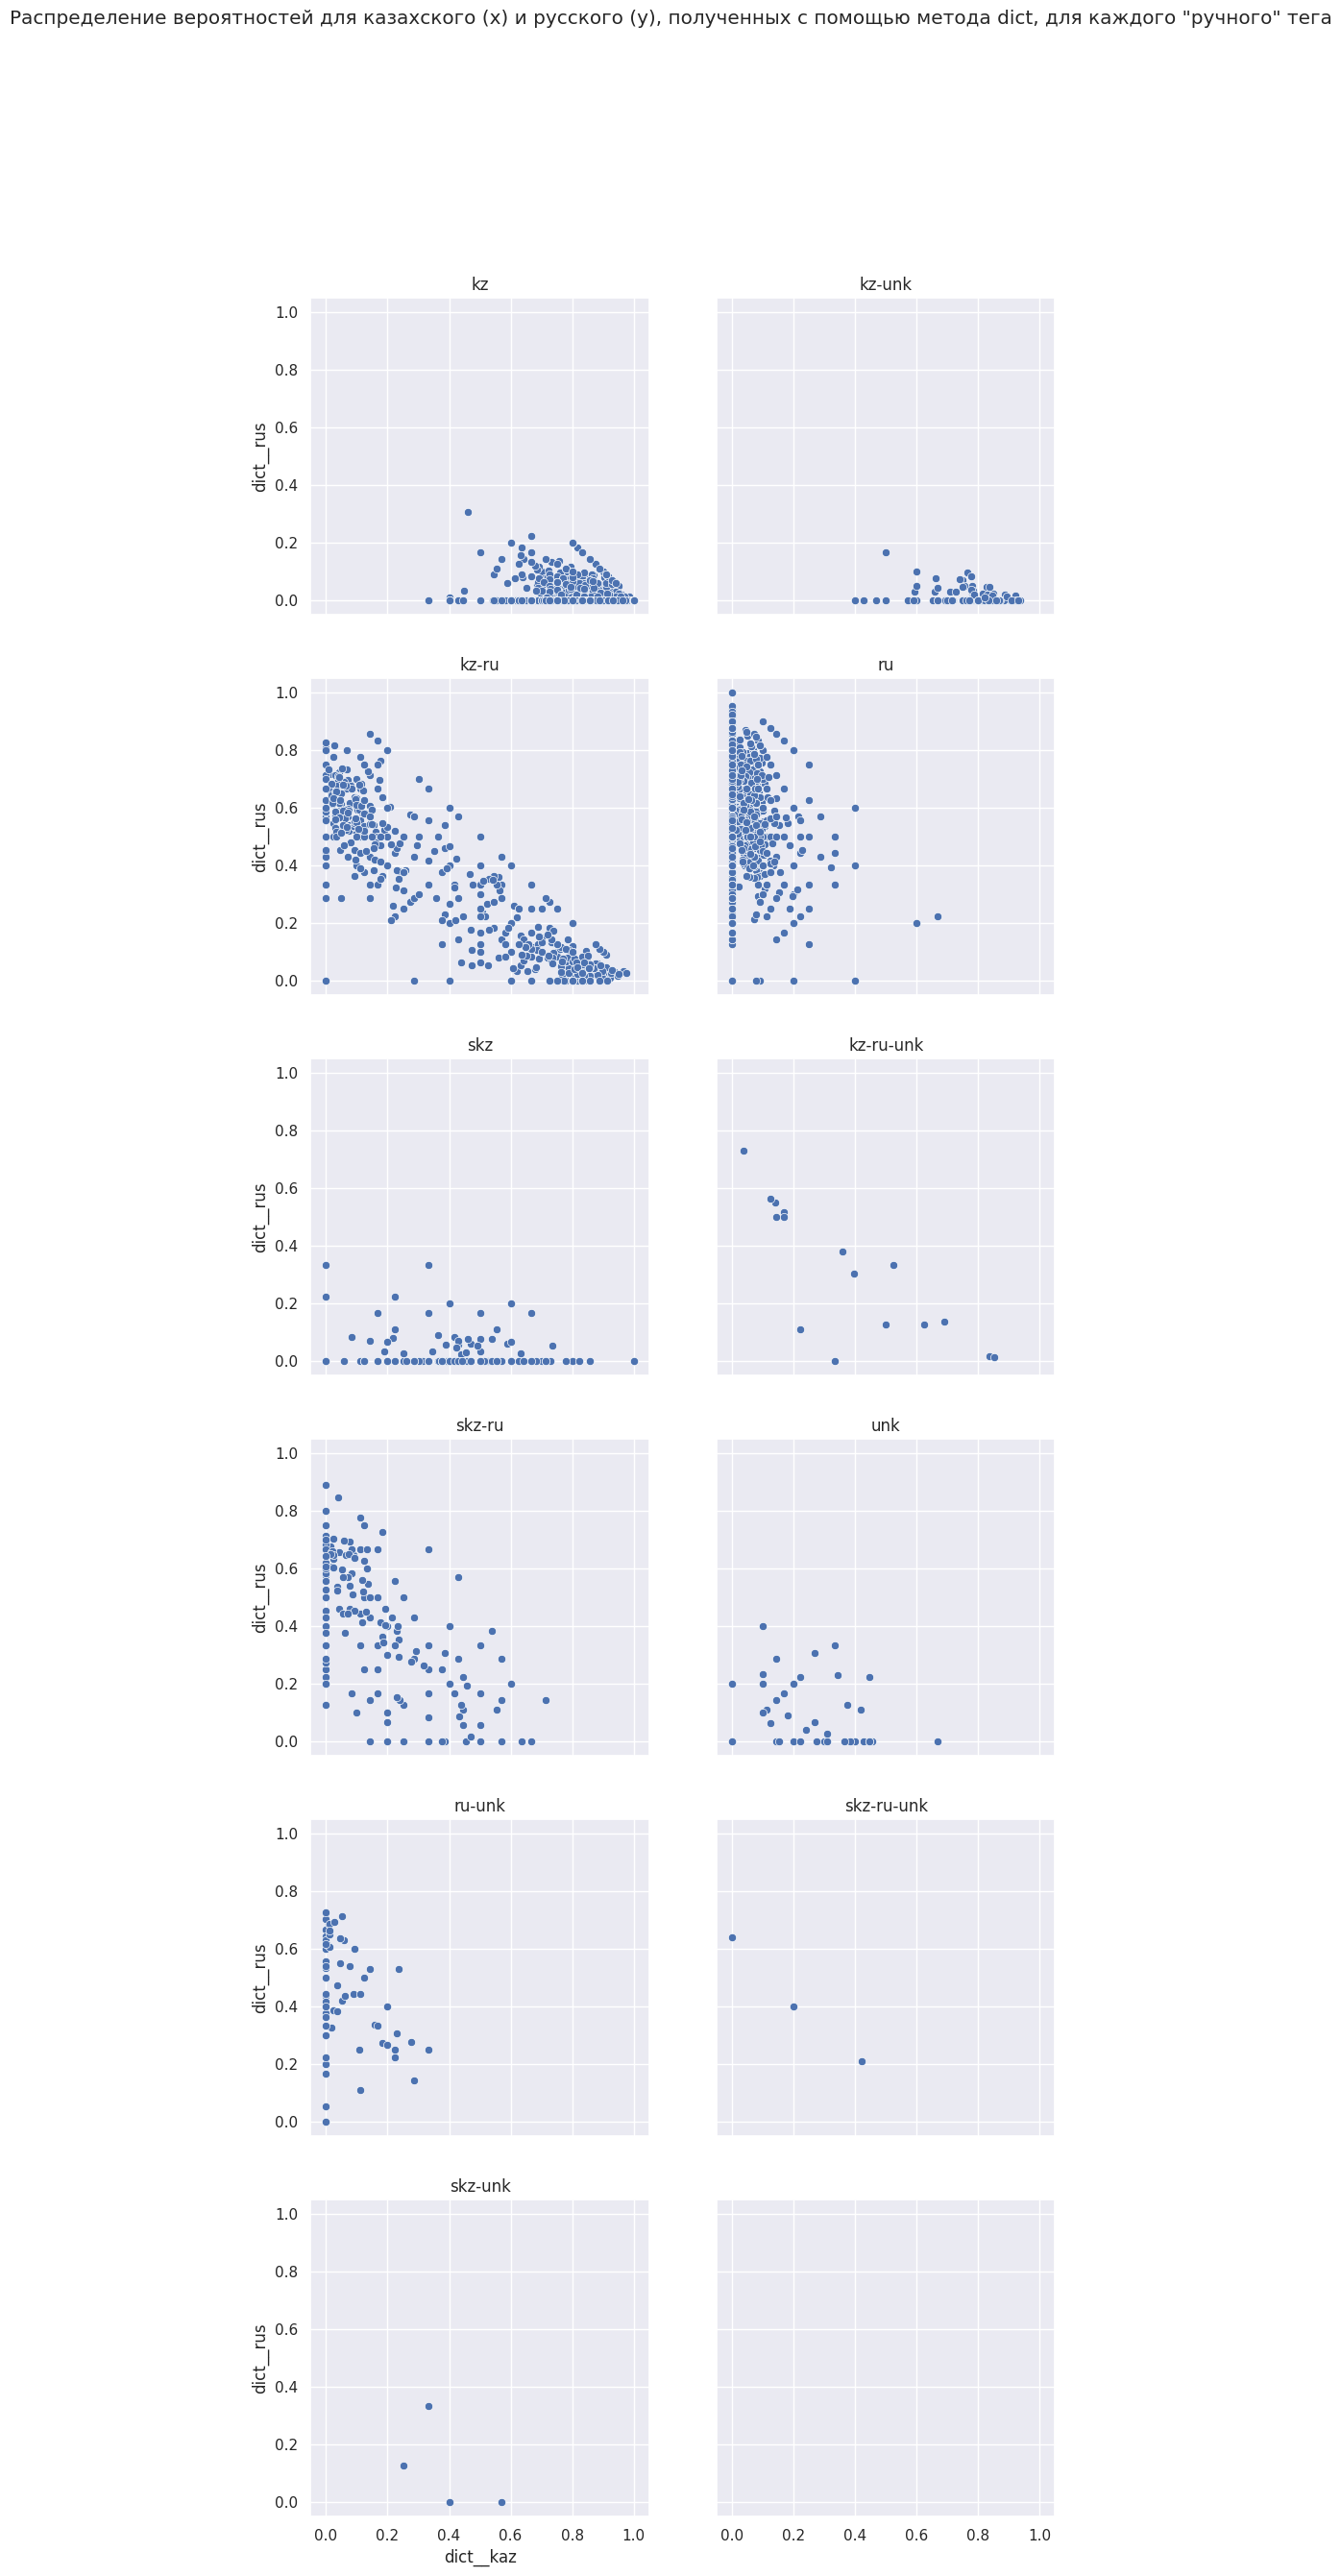

In [105]:
METHOD = 'dict'

visualize_tags(exprmnt.df, method=METHOD, manual_col='manual_tag')

#### Q1: Для скольких одноязычных примеров (kz и ru) был правильно определен язык?

In [106]:
# какие теги предсказываются для текстов на казахском
exprmnt.df[(exprmnt.df['manual_tag'].isin(['kz']))][f'{METHOD}__best_lang'].value_counts() / len(exprmnt.df[(exprmnt.df['manual_tag'].isin(['kz']))])

,count
dict__best_lang,
kazakh,0.99715
unk,0.00190
ambig,0.00095


In [107]:
# какие теги предсказываются для текстов на русском
exprmnt.df[(exprmnt.df['manual_tag'].isin(['ru']))][f'{METHOD}__best_lang'].value_counts() / len(exprmnt.df[(exprmnt.df['manual_tag'].isin(['ru']))])

,count
dict__best_lang,
russian,0.926392
ambig,0.067135
unk,0.005733
kazakh,0.000740


Recall для казахского значительно выше, чем для русского -- почти 1 против 0.93

In [166]:
sample = exprmnt.df[(exprmnt.df['manual_tag'].isin(['kz', 'ru'])) | (exprmnt.df[f'{METHOD}__best_lang'].isin(['kazakh', 'russian']))].copy()
sample['manual_tag'] = sample['manual_tag'].replace({'kz': 'kazakh', 'ru': 'russian'})

print(classification_report(y_true=sample['manual_tag'], y_pred=sample[f'{METHOD}__best_lang'], labels=['kazakh', 'russian']))

              precision    recall  f1-score   support

      kazakh       0.86      1.00      0.92      3158
     russian       0.92      0.93      0.92      5407

   micro avg       0.90      0.95      0.92      8565
   macro avg       0.89      0.96      0.92      8565
weighted avg       0.90      0.95      0.92      8565



#### Q2: Что предсказывается для kz-ru?

In [33]:
counts_ = exprmnt.df[exprmnt.df['manual_tag'].isin(['kz-ru'])].groupby(['manual_tag', f'{METHOD}__best_lang'])['text'].count()
counts_ = (counts_ / exprmnt.df['manual_tag'].value_counts()).fillna(0)

cm = sns.light_palette("orange", as_cmap=True)

s = pd.DataFrame(counts_).style.background_gradient(cmap=cm)
s

Для csw-текстов предсказывается в основном либо казахский, либо русский, что очевидно конкретно для этого метода.

#### Q3: Как хорошо метод предсказывает одноязычные тексты на нерелевантных языках?

In [34]:
# качество бинарной классификации для определения тега unk
y_true = (exprmnt.df['manual_tag']=='unk').astype(int)
y_pred = (exprmnt.df[f'{METHOD}__best_lang']=='unk').astype(int)

print(classification_report(y_true=y_true, y_pred=y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      9656
           1       0.18      0.79      0.30        43

    accuracy                           0.98      9699
   macro avg       0.59      0.89      0.64      9699
weighted avg       1.00      0.98      0.99      9699



In [35]:
# какие теги предсказываются для unk
exprmnt.df[(exprmnt.df['manual_tag']=='unk')][f'{METHOD}__best_lang'].value_counts() # / len(exprmnt.df[(exprmnt.df['manual_tag']=='unk')])

,count
dict__best_lang,
unk,34
kazakh,6
russian,2
ambig,1


In [36]:
# что предсказывается для unk, и для каких языков предсказывается unk
exprmnt.df[(exprmnt.df['manual_tag']=='unk') |(exprmnt.df[f'{METHOD}__best_lang']=='unk')].groupby(['manual_tag', f'{METHOD}__best_lang'])['text'].count()

,,text
manual_tag,dict__best_lang,
kz,unk,6
kz-ru,unk,2
kz-ru-unk,unk,1
kz-unk,unk,1
ru,unk,31
ru-unk,unk,18
skz,unk,70
skz-ru,unk,21
skz-unk,unk,2


Из всех текстов на нерелевантных языках словарный метод выявил 79% (recall=0.79).

При этом 82% текстов, определенных как "нерелевантные" на самом деле содержат казахский или русский.

#### Q4: Какие результаты для skz?

In [37]:
# какие языки определены для skz
y_pred = exprmnt.df[(exprmnt.df['manual_tag']=='skz')][f'{METHOD}__best_lang']

y_pred.value_counts() / len(y_pred)

,count
dict__best_lang,
kazakh,0.586207
unk,0.402299
ambig,0.011494


In [38]:
# распределение вероятностей kaz и unk для 'skz', 'kz', 'unk'
exprmnt.df[exprmnt.df['manual_tag'].isin(['skz', 'kz', 'unk'])].groupby('manual_tag')[[f'{METHOD}__kaz', f'{METHOD}__unk']].describe().T

manual_tag                kz         skz        unk
dict__kaz count  3158.000000  174.000000  43.000000
          mean      0.872786    0.438300   0.244864
          std       0.103660    0.177840   0.145551
          min       0.333333    0.000000   0.000000
          25%       0.818497    0.333333   0.142857
          50%       0.882353    0.438262   0.222222
          75%       0.944444    0.555556   0.353247
          max       1.000000    1.000000   0.666667
dict__unk count  3158.000000  174.000000  43.000000
          mean      0.037191    0.424566   0.554192
          std       0.065377    0.171196   0.175292
          min       0.000000    0.000000   0.111111
          25%       0.000000    0.333333   0.464103
          50%       0.000000    0.400000   0.571429
          75%       0.050794    0.500000   0.651515
          max       0.571429    1.000000   1.000000

Для текстов, помеченных тегом skz (то есть написанные на "упрощенном" казахском алфавите), метод предсказывает теги kz, поскольку не все казахские слова пишутся с использованием специализированных символов, или unk -- это также очевидно для данного метода, поскольку если казахское слово написано неправильно, то оно с большой вероятностью не найдется ни в словаре казахского, ни в словаре русского языка, и будет отмечено как unk.

#### Q5: Что получим после фильтрации?

In [42]:
y_pred = exprmnt.df[f'{METHOD}__best_lang'].isin(['kazakh', 'russian', 'ambig']).astype(int)

# доля тегов, которые будут выкинуты
counts_ = (exprmnt.df[y_pred==0]['manual_tag'].value_counts() / exprmnt.df['manual_tag'].value_counts()).fillna(0).rename('will_be_excluded, %')

cm = sns.light_palette("green", as_cmap=True)

s = pd.DataFrame(counts_).style.background_gradient(cmap=cm)
s

,"will_be_excluded, %"
manual_tag,
kz,0.001900
kz-ru,0.003817
kz-ru-unk,0.062500
kz-unk,0.008850
ru,0.005733
ru-unk,0.253521
skz,0.402299
skz-ru,0.112903
skz-ru-unk,0.000000


In [43]:
# абсолютные количества тегов, которые будут выкинуты
counts_ = exprmnt.df[y_pred==0]['manual_tag'].value_counts().rename('will_be_excluded')
counts_ = pd.concat([counts_,exprmnt.df['manual_tag'].value_counts().rename('total')], axis=1)
counts_.fillna(0)

,will_be_excluded,total
manual_tag,,
skz,70.0,174
unk,34.0,43
ru,31.0,5407
skz-ru,21.0,186
ru-unk,18.0,71
kz,6.0,3158
kz-ru,2.0,524
skz-unk,2.0,4
kz-ru-unk,1.0,16


## Compact Language Detector 2
Репозиторий: https://github.com/CLD2Owners/cld2

Поддерживает 83 языка. Модель представляет собой Naïve Bayesian classifier на основе n-грамм: для казахского и русского предсказания делаются на основе квадграмм(4-грамм). В первую очередь cld2 приводит текст к нижнему регистру, удаляет цифры, пунктуацию и HTML-теги.

### Анализ

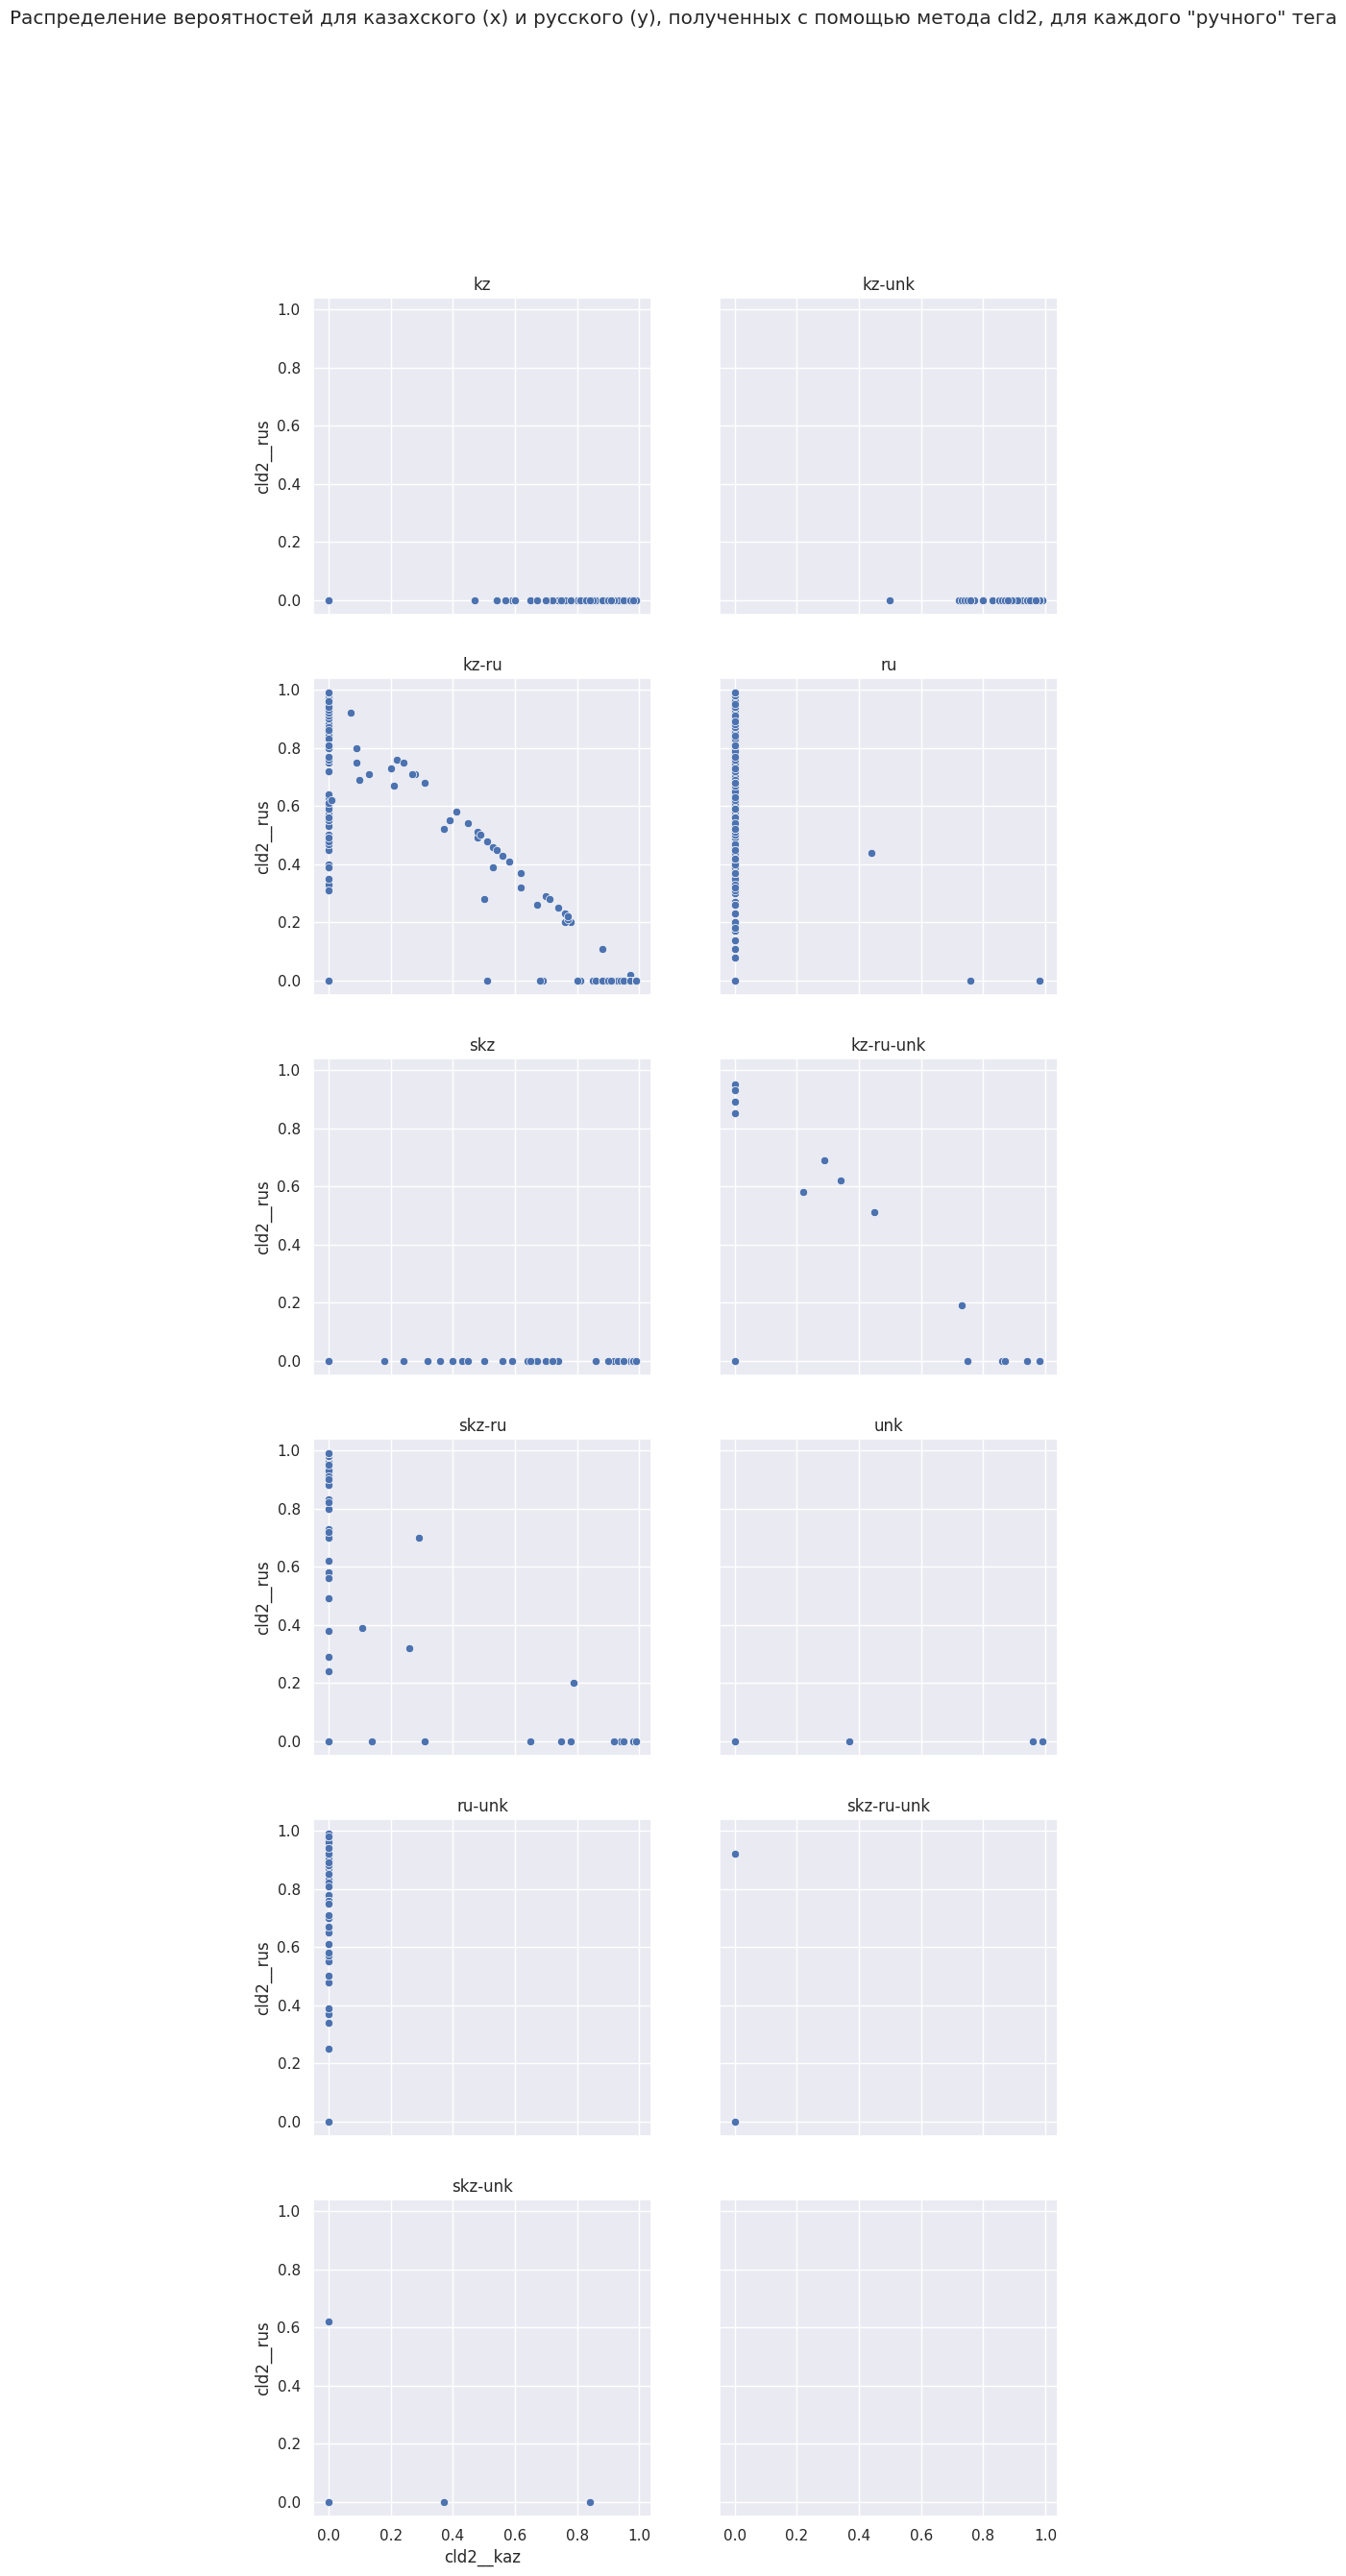

In [215]:
METHOD = 'cld2'

visualize_tags(exprmnt.df, method=METHOD, manual_col='manual_tag')

In [499]:
corrections = {'skz':'kz', 'skz-ru': 'kz-ru', 'skz-ru-unk': 'kz-ru-unk', 'skz-unk': 'kz-unk'}
exprmnt.df['manual_tag_adj'] = exprmnt.df['manual_tag'].replace(corrections)
exprmnt.df['manual_tag_adj'].value_counts()

,count
manual_tag_adj,
ru,5407
kz,3332
kz-ru,710
kz-unk,117
ru-unk,71
unk,43
kz-ru-unk,19


In [511]:
# direct csw prediction
y_true = exprmnt.df['manual_tag_adj'].str.contains('kz-ru')
y_pred = exprmnt.df['cld2__all_langs'].str.contains('kz-ru')

print(classification_report(y_true=y_true, y_pred=y_pred))

              precision    recall  f1-score   support

       False       0.93      1.00      0.96      8970
        True       0.98      0.07      0.13       729

    accuracy                           0.93      9699
   macro avg       0.96      0.53      0.55      9699
weighted avg       0.93      0.93      0.90      9699



In [515]:
# какие предсказания дает cld2 для csw-текстов
df[(y_true==1) & (y_pred==0)]['cld2__all_langs'].value_counts()

,count
cld2__all_langs,
ru,308
kz,251
unk,94
ru-unk,17
kz-unk,8


#### Q1: Для скольких одноязычных примеров (kz и ru) был правильно определен язык?

In [216]:
# какие теги предсказываются для текстов на казахском
exprmnt.df[(exprmnt.df['manual_tag'].isin(['kz']))][f'{METHOD}__best_lang'].value_counts() / len(exprmnt.df[(exprmnt.df['manual_tag'].isin(['kz']))])

,count
cld2__best_lang,
kazakh,0.995883
un,0.004117


In [217]:
# какие теги предсказываются для текстов на русском
exprmnt.df[(exprmnt.df['manual_tag'].isin(['ru']))][f'{METHOD}__best_lang'].value_counts() / len(exprmnt.df[(exprmnt.df['manual_tag'].isin(['ru']))])

,count
cld2__best_lang,
russian,0.849085
un,0.129647
serbian,0.017385
ukrainian,0.000925
bulgarian,0.000925
kyrgyz,0.000740
kazakh,0.000370
mongolian,0.000370
macedonian,0.000185


Для казахского recall значительно выше, чем для русского -- почти 1.0 против 0.85

In [218]:
sample = exprmnt.df[(exprmnt.df['manual_tag'].isin(['kz', 'ru'])) | (exprmnt.df[f'{METHOD}__best_lang'].isin(['kazakh', 'russian']))].copy()
sample['manual_tag'] = sample['manual_tag'].replace({'kz': 'kazakh', 'ru': 'russian'})

print(classification_report(y_true=sample['manual_tag'], y_pred=sample[f'{METHOD}__best_lang'], labels=['kazakh', 'russian']))

              precision    recall  f1-score   support

      kazakh       0.87      1.00      0.93      3158
     russian       0.92      0.85      0.88      5407

   micro avg       0.90      0.90      0.90      8565
   macro avg       0.89      0.92      0.91      8565
weighted avg       0.90      0.90      0.90      8565



#### Q2: Что предсказывается для kz-ru?

In [47]:
counts_ = exprmnt.df[exprmnt.df['manual_tag'].isin(['kz-ru'])].groupby(['manual_tag', f'{METHOD}__best_lang'])['text'].count()
counts_ = (counts_ / exprmnt.df['manual_tag'].value_counts()).fillna(0)

cm = sns.light_palette("orange", as_cmap=True)

s = pd.DataFrame(counts_).style.background_gradient(cmap=cm)
s

Для csw-текстов предсказывается в основном либо казахский, либо русский. В суммарно менее, чем 10% случаев предсказывается "неизвестный язык", сербский и таджикский.

#### Q3: Как хорошо метод предсказывает одноязычные тексты на нерелевантных языках?

In [63]:
# качество бинарной классификации для определения тега unk
sample = exprmnt.df[exprmnt.df['manual_tag'].isin(['kz', 'ru', 'unk', 'skz'])]
y_true = (sample['manual_tag']=='unk').astype(int)
y_pred = (~sample[f'{METHOD}__best_lang'].isin(['kazakh', 'russian'])).astype(int)

print(classification_report(y_true=y_true, y_pred=y_pred))

              precision    recall  f1-score   support

           0       1.00      0.89      0.94      8739
           1       0.04      0.95      0.08        43

    accuracy                           0.89      8782
   macro avg       0.52      0.92      0.51      8782
weighted avg       1.00      0.89      0.94      8782



In [66]:
# какие языки предсказываются для unk
sample[(sample['manual_tag']=='unk')].groupby(['manual_tag', f'{METHOD}__best_lang'])['text'].count()

manual_tag  cld2__best_lang
unk         kazakh              2
            kyrgyz              6
            turkmen             1
            ukrainian           7
            un                 15
            uzbek              12
Name: text, dtype: int64

In [65]:
# для каких true тегов предсказывается "другой язык"
sample[(~sample[f'{METHOD}__best_lang'].isin(['kazakh', 'russian']))].groupby(['manual_tag', f'{METHOD}__best_lang'])['text'].count()

manual_tag  cld2__best_lang
kz          un                  13
ru          bulgarian            5
            english              1
            kyrgyz               4
            macedonian           1
            mongolian            2
            romanian             1
            serbian             94
            ukrainian            5
            un                 701
skz         kyrgyz              56
            mongolian            1
            serbian              1
            tatar                1
            turkmen              5
            un                  29
            uyghur               1
            uzbek                4
unk         kyrgyz               6
            turkmen              1
            ukrainian            7
            un                  15
            uzbek               12
Name: text, dtype: int64

Из всех текстов на нерелевантных языках cld2 выявил 95%.

При этом 96% текстов, определенных как "нерелевантные" на самом деле содержат казахский или русский.

Что касается ошибочного определения языка, чаще всего казахский принимается за "неизвестный язык", русский -- за "неизвестный", сербский, болгарский, "упрощенное" написание казахского также принимается за киргизский и "неизвестный" язык.

#### Q4: Какие результаты для skz?

In [67]:
# какие языки определены для skz
y_pred = exprmnt.df[(exprmnt.df['manual_tag']=='skz')][f'{METHOD}__best_lang']

y_pred.value_counts() / len(y_pred)

,count
cld2__best_lang,
kazakh,0.436782
kyrgyz,0.321839
un,0.166667
turkmen,0.028736
uzbek,0.022989
serbian,0.005747
mongolian,0.005747
uyghur,0.005747
tatar,0.005747


Для текстов, помеченных тегом skz метод предсказывает казахский (44%), киргизский (32%),  "неизвестный язык" (17%) и другие: туркменский, узбекский, сербский, монгольский, уйгурский, татарский.

#### Q5: Что получим после фильтрации?

In [70]:
y_pred = exprmnt.df[f'{METHOD}__best_lang'].isin(['kazakh', 'russian']).astype(int)

# доля тегов, которые будут выкинуты
counts_ = (exprmnt.df[y_pred==0]['manual_tag'].value_counts() / exprmnt.df['manual_tag'].value_counts()).fillna(0).rename('will_be_excluded, %')

cm = sns.light_palette("green", as_cmap=True)

s = pd.DataFrame(counts_).style.background_gradient(cmap=cm)
s

,"will_be_excluded, %"
manual_tag,
kz,0.004117
kz-ru,0.076336
kz-ru-unk,0.062500
kz-unk,0.000000
ru,0.150546
ru-unk,0.309859
skz,0.563218
skz-ru,0.327957
skz-ru-unk,0.666667


In [71]:
# абсолютные количества тегов, которые будут выкинуты
counts_ = exprmnt.df[y_pred==0]['manual_tag'].value_counts().rename('will_be_excluded')
counts_ = pd.concat([counts_,exprmnt.df['manual_tag'].value_counts().rename('total')], axis=1)
counts_.fillna(0)

,will_be_excluded,total
manual_tag,,
ru,814.0,5407
skz,98.0,174
skz-ru,61.0,186
unk,41.0,43
kz-ru,40.0,524
ru-unk,22.0,71
kz,13.0,3158
skz-ru-unk,2.0,3
skz-unk,2.0,4


Этот способ позволит избавиться от 95% нерелевантных текстов, затронув более 7% примеров с csw.

## Compact Language Detector 3

Репозиторий: https://github.com/google/cld3

cld3 разработан для Chrome-браузера, на сегодняшний день существует как публичный архив.

### Анализ

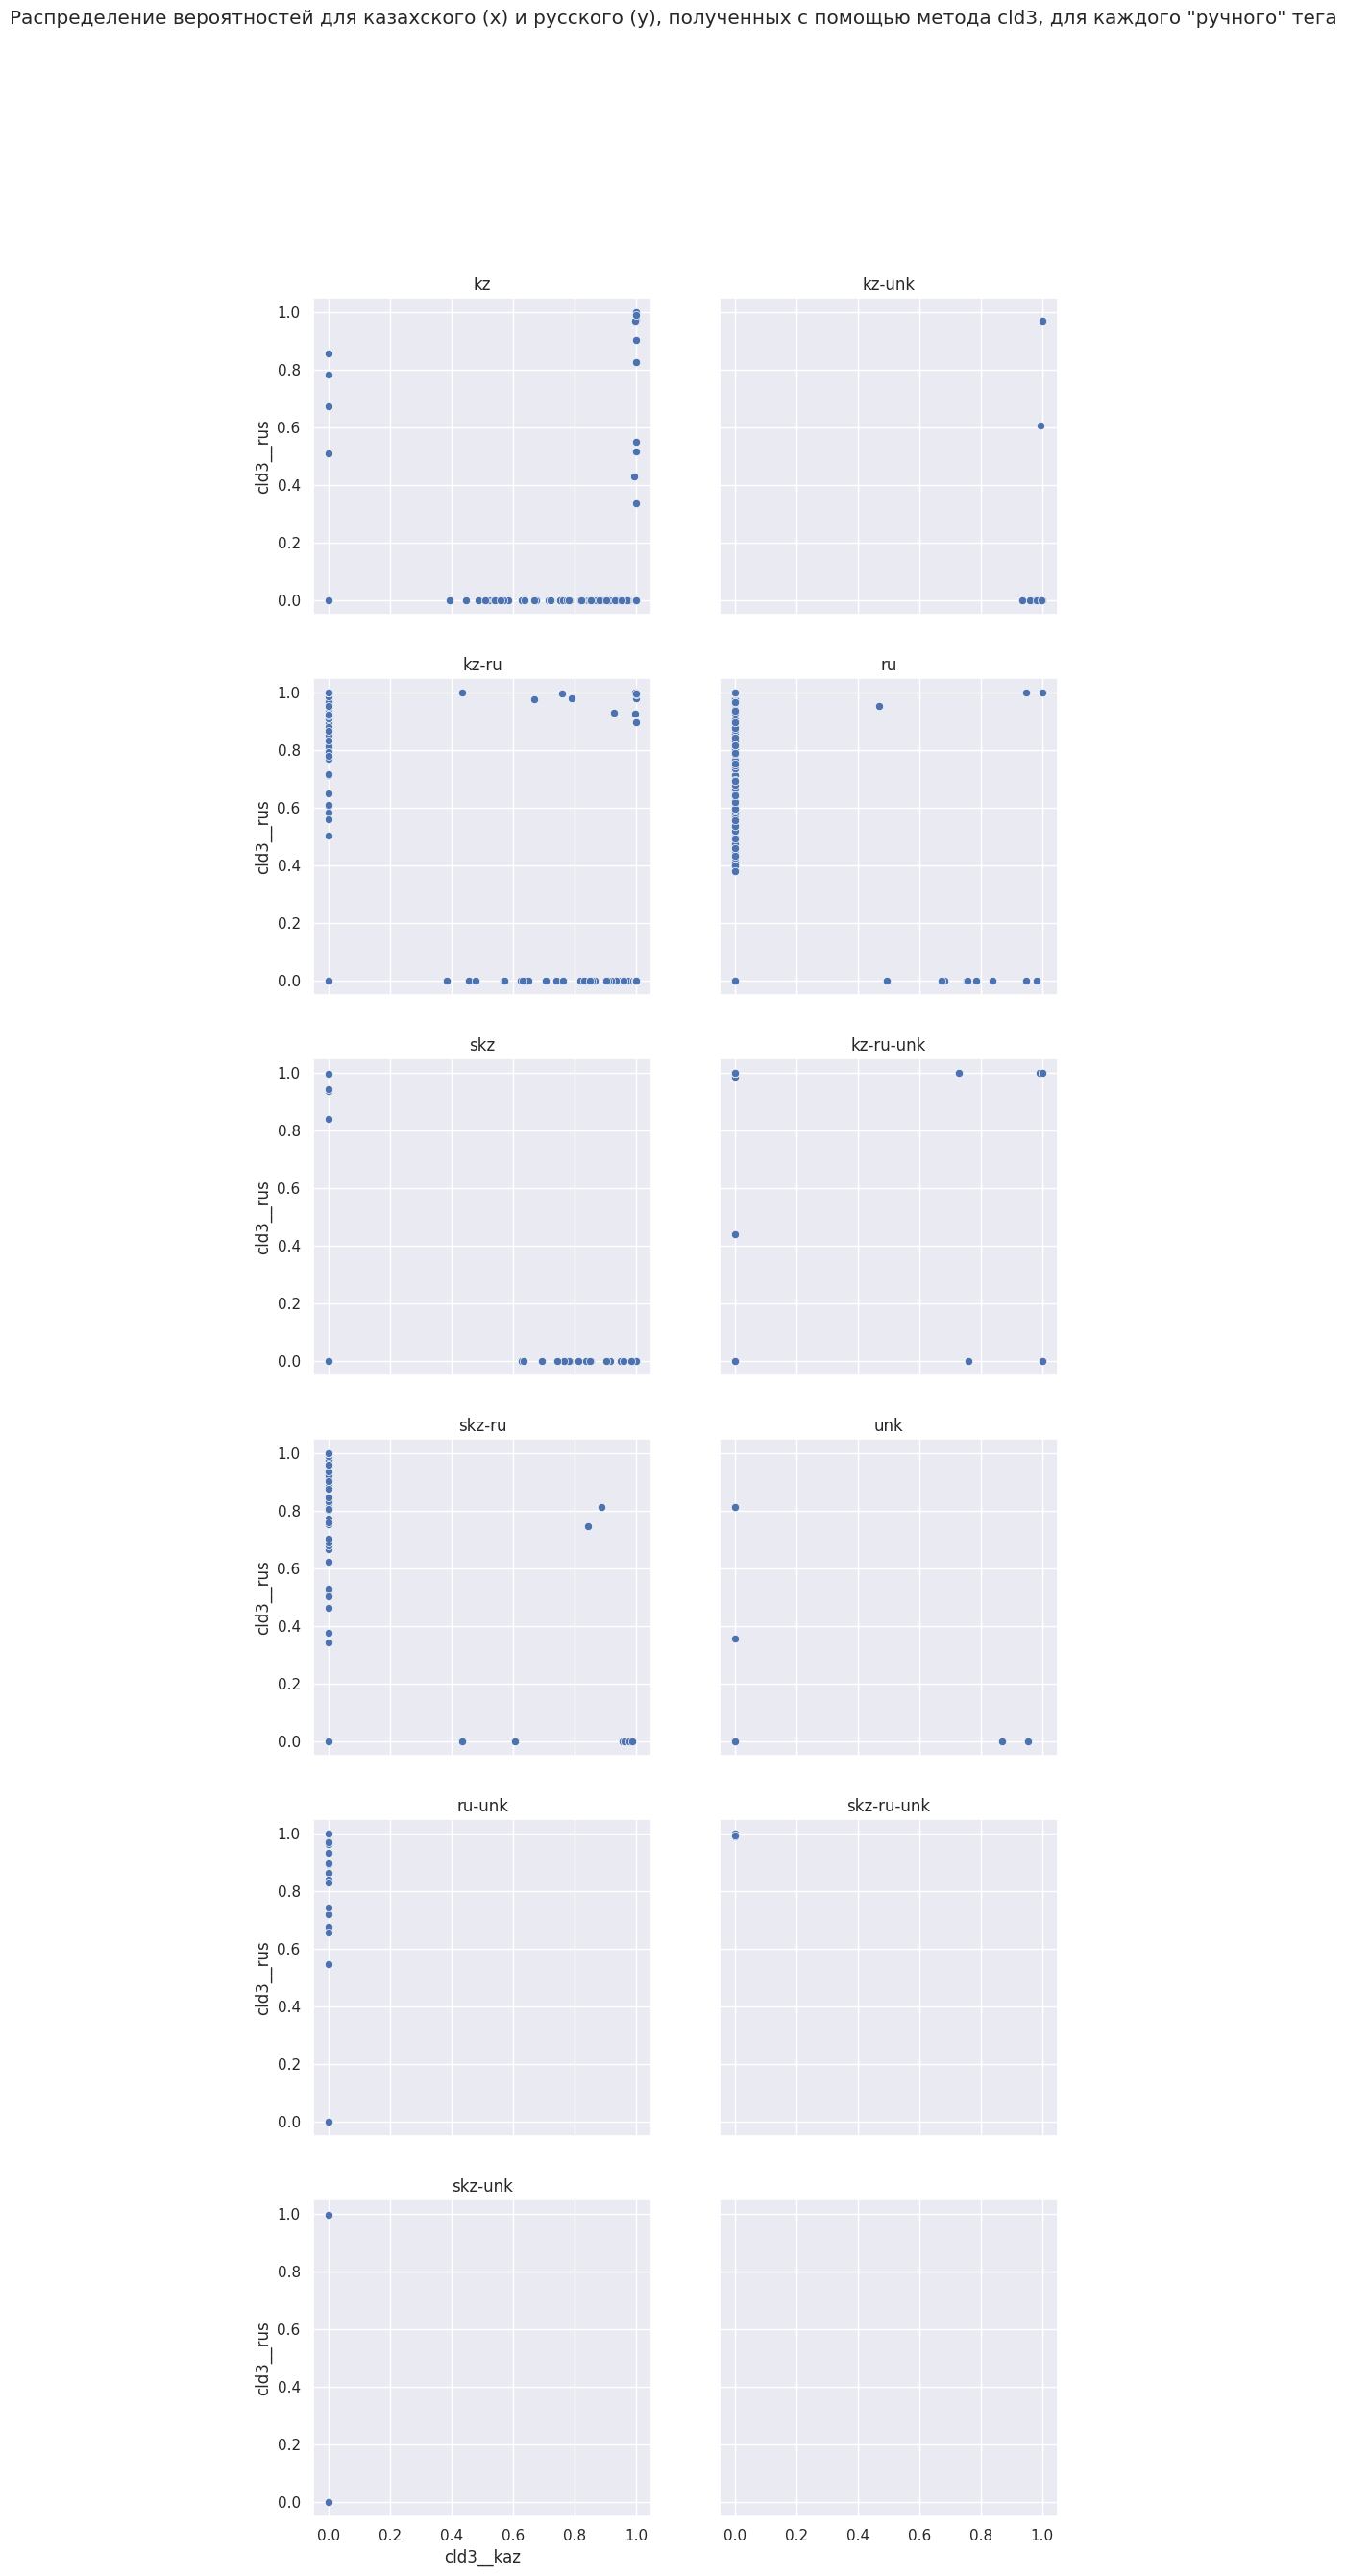

In [111]:
METHOD = 'cld3'

visualize_tags(exprmnt.df, method=METHOD, manual_col='manual_tag')

#### Q1: Для скольких одноязычных примеров (kz и ru) был правильно определен язык?

In [112]:
# какие теги предсказываются для текстов на казахском
exprmnt.df[(exprmnt.df['manual_tag'].isin(['kz']))][f'{METHOD}__best_lang'].value_counts() / len(exprmnt.df[(exprmnt.df['manual_tag'].isin(['kz']))])

,count
cld3__best_lang,
kazakh,0.990184
kyrgyz,0.004433
belarusian,0.001583
russian,0.001267
ukrainian,0.000633
swedish,0.000633
tajik,0.000317
samoan,0.000317
bulgarian,0.000317


In [113]:
# какие теги предсказываются для текстов на русском
exprmnt.df[(exprmnt.df['manual_tag'].isin(['ru']))][f'{METHOD}__best_lang'].value_counts() / len(exprmnt.df[(exprmnt.df['manual_tag'].isin(['ru']))])

,count
cld3__best_lang,
russian,0.945256
bulgarian,0.013871
ukrainian,0.010172
belarusian,0.008877
serbian,0.008323
kyrgyz,0.005548
macedonian,0.002034
mongolian,0.001849
kazakh,0.001665


Recall для казахского значительно выше, чем для русского -- 0.99 против 0.95

In [164]:
sample = exprmnt.df[(exprmnt.df['manual_tag'].isin(['kz', 'ru'])) | (exprmnt.df[f'{METHOD}__best_lang'].isin(['kazakh', 'russian']))].copy()
sample['manual_tag'] = sample['manual_tag'].replace({'kz': 'kazakh', 'ru': 'russian'})

print(classification_report(y_true=sample['manual_tag'], y_pred=sample[f'{METHOD}__best_lang'], labels=['kazakh', 'russian']))

              precision    recall  f1-score   support

      kazakh       0.89      0.99      0.94      3158
     russian       0.92      0.95      0.93      5407

   micro avg       0.91      0.96      0.93      8565
   macro avg       0.90      0.97      0.93      8565
weighted avg       0.91      0.96      0.93      8565



#### Q2: Что предсказывается для kz-ru?

In [75]:
counts_ = exprmnt.df[exprmnt.df['manual_tag'].isin(['kz-ru'])].groupby(['manual_tag', f'{METHOD}__best_lang'])['text'].count()
counts_ = (counts_ / exprmnt.df['manual_tag'].value_counts()).fillna(0)

cm = sns.light_palette("orange", as_cmap=True)

s = pd.DataFrame(counts_).style.background_gradient(cmap=cm)
s

Для csw-текстов предсказывается в основном либо казахский, либо русский. В суммарно менее, чем 10% случаев предсказывается множество других языков: киргизский, украинский, белорусский, болгарский и др.

#### Q3: Как хорошо метод предсказывает одноязычные тексты на нерелевантных языках?

In [76]:
# качество бинарной классификации для определения тега unk
sample = exprmnt.df[exprmnt.df['manual_tag'].isin(['kz', 'ru', 'unk', 'skz'])]
y_true = (sample['manual_tag']=='unk').astype(int)
y_pred = (~sample[f'{METHOD}__best_lang'].isin(['kazakh', 'russian'])).astype(int)

print(classification_report(y_true=y_true, y_pred=y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97      8739
           1       0.08      0.91      0.14        43

    accuracy                           0.95      8782
   macro avg       0.54      0.93      0.56      8782
weighted avg       1.00      0.95      0.97      8782



In [77]:
# какие языки предсказываются для unk
sample[(sample['manual_tag']=='unk')].groupby(['manual_tag', f'{METHOD}__best_lang'])['text'].count()

manual_tag  cld3__best_lang
unk         bulgarian           2
            kazakh              2
            kyrgyz             19
            macedonian          1
            mongolian           5
            russian             2
            serbian             1
            tajik               3
            ukrainian           8
Name: text, dtype: int64

In [78]:
# для каких true тегов предсказывается "другой язык"
sample[(~sample[f'{METHOD}__best_lang'].isin(['kazakh', 'russian']))].groupby(['manual_tag', f'{METHOD}__best_lang'])['text'].count()

manual_tag  cld3__best_lang
kz          belarusian           5
            bulgarian            1
            kyrgyz              14
            mongolian            1
            samoan               1
            swedish              2
            tajik                1
            ukrainian            2
ru          belarusian          48
            bulgarian           75
            english              2
            french               1
            hi-latn              2
            irish                1
            kyrgyz              30
            macedonian          11
            mongolian           10
            portuguese           1
            serbian             45
            somali               1
            southern sotho       1
            tajik                4
            ukrainian           55
skz         belarusian           3
            bulgarian            1
            kyrgyz             140
unk         bulgarian            2
            kyrgyz              19
            macedonian           1
            mongolian            5
            serbian              1
            tajik                3
            ukrainian            8
Name: text, dtype: int64

Из всех текстов на нерелевантных языках cld3 выявил 91%.

При этом 92% текстов, определенных как "нерелевантные" на самом деле содержат казахский или русский.

Что касается ошибочного определения языка, чаще всего казахский принимается за киргизский, русский -- за болгарский, украинский, белорусский, сербский и киргизский, "упрощенное" написание казахского также принимается за киргизский язык.

#### Q4: Какие результаты для skz?

In [114]:
# какие языки определены для skz
y_pred = exprmnt.df[(exprmnt.df['manual_tag']=='skz')][f'{METHOD}__best_lang']

y_pred.value_counts() / len(y_pred)

,count
cld3__best_lang,
kyrgyz,0.804598
kazakh,0.149425
russian,0.022989
belarusian,0.017241
bulgarian,0.005747


Для текстов, помеченных тегом skz в подавляющем большинстве случаев предсказывается киргизский -- 80%

#### Q5: Что получим после фильтрации?

In [115]:
y_pred = exprmnt.df[f'{METHOD}__best_lang'].isin(['kazakh', 'russian']).astype(int)

# доля тегов, которые будут выкинуты
counts_ = (exprmnt.df[y_pred==0]['manual_tag'].value_counts() / exprmnt.df['manual_tag'].value_counts()).fillna(0).rename('will_be_excluded, %')

cm = sns.light_palette("green", as_cmap=True)

s = pd.DataFrame(counts_).style.background_gradient(cmap=cm)
s

,"will_be_excluded, %"
manual_tag,
kz,0.008550
kz-ru,0.072519
kz-ru-unk,0.062500
kz-unk,0.000000
ru,0.053079
ru-unk,0.309859
skz,0.827586
skz-ru,0.338710
skz-ru-unk,0.333333


In [117]:
# абсолютные количества тегов, которые будут выкинуты
counts_ = exprmnt.df[y_pred==0]['manual_tag'].value_counts().rename('will_be_excluded')
counts_ = pd.concat([counts_,exprmnt.df['manual_tag'].value_counts().rename('total')], axis=1)
counts_.fillna(0)

,will_be_excluded,total
manual_tag,,
ru,287.0,5407
skz,144.0,174
skz-ru,63.0,186
unk,39.0,43
kz-ru,38.0,524
kz,27.0,3158
ru-unk,22.0,71
skz-unk,3.0,4
skz-ru-unk,1.0,3


Этот способ позволит избавиться от 91% нерелевантных текстов, затронув более 7% примеров с csw.

## Fast-langdetect

https://github.com/LlmKira/fast-langdetect

Обертка, ускоряющая работу FastText

### Анализ

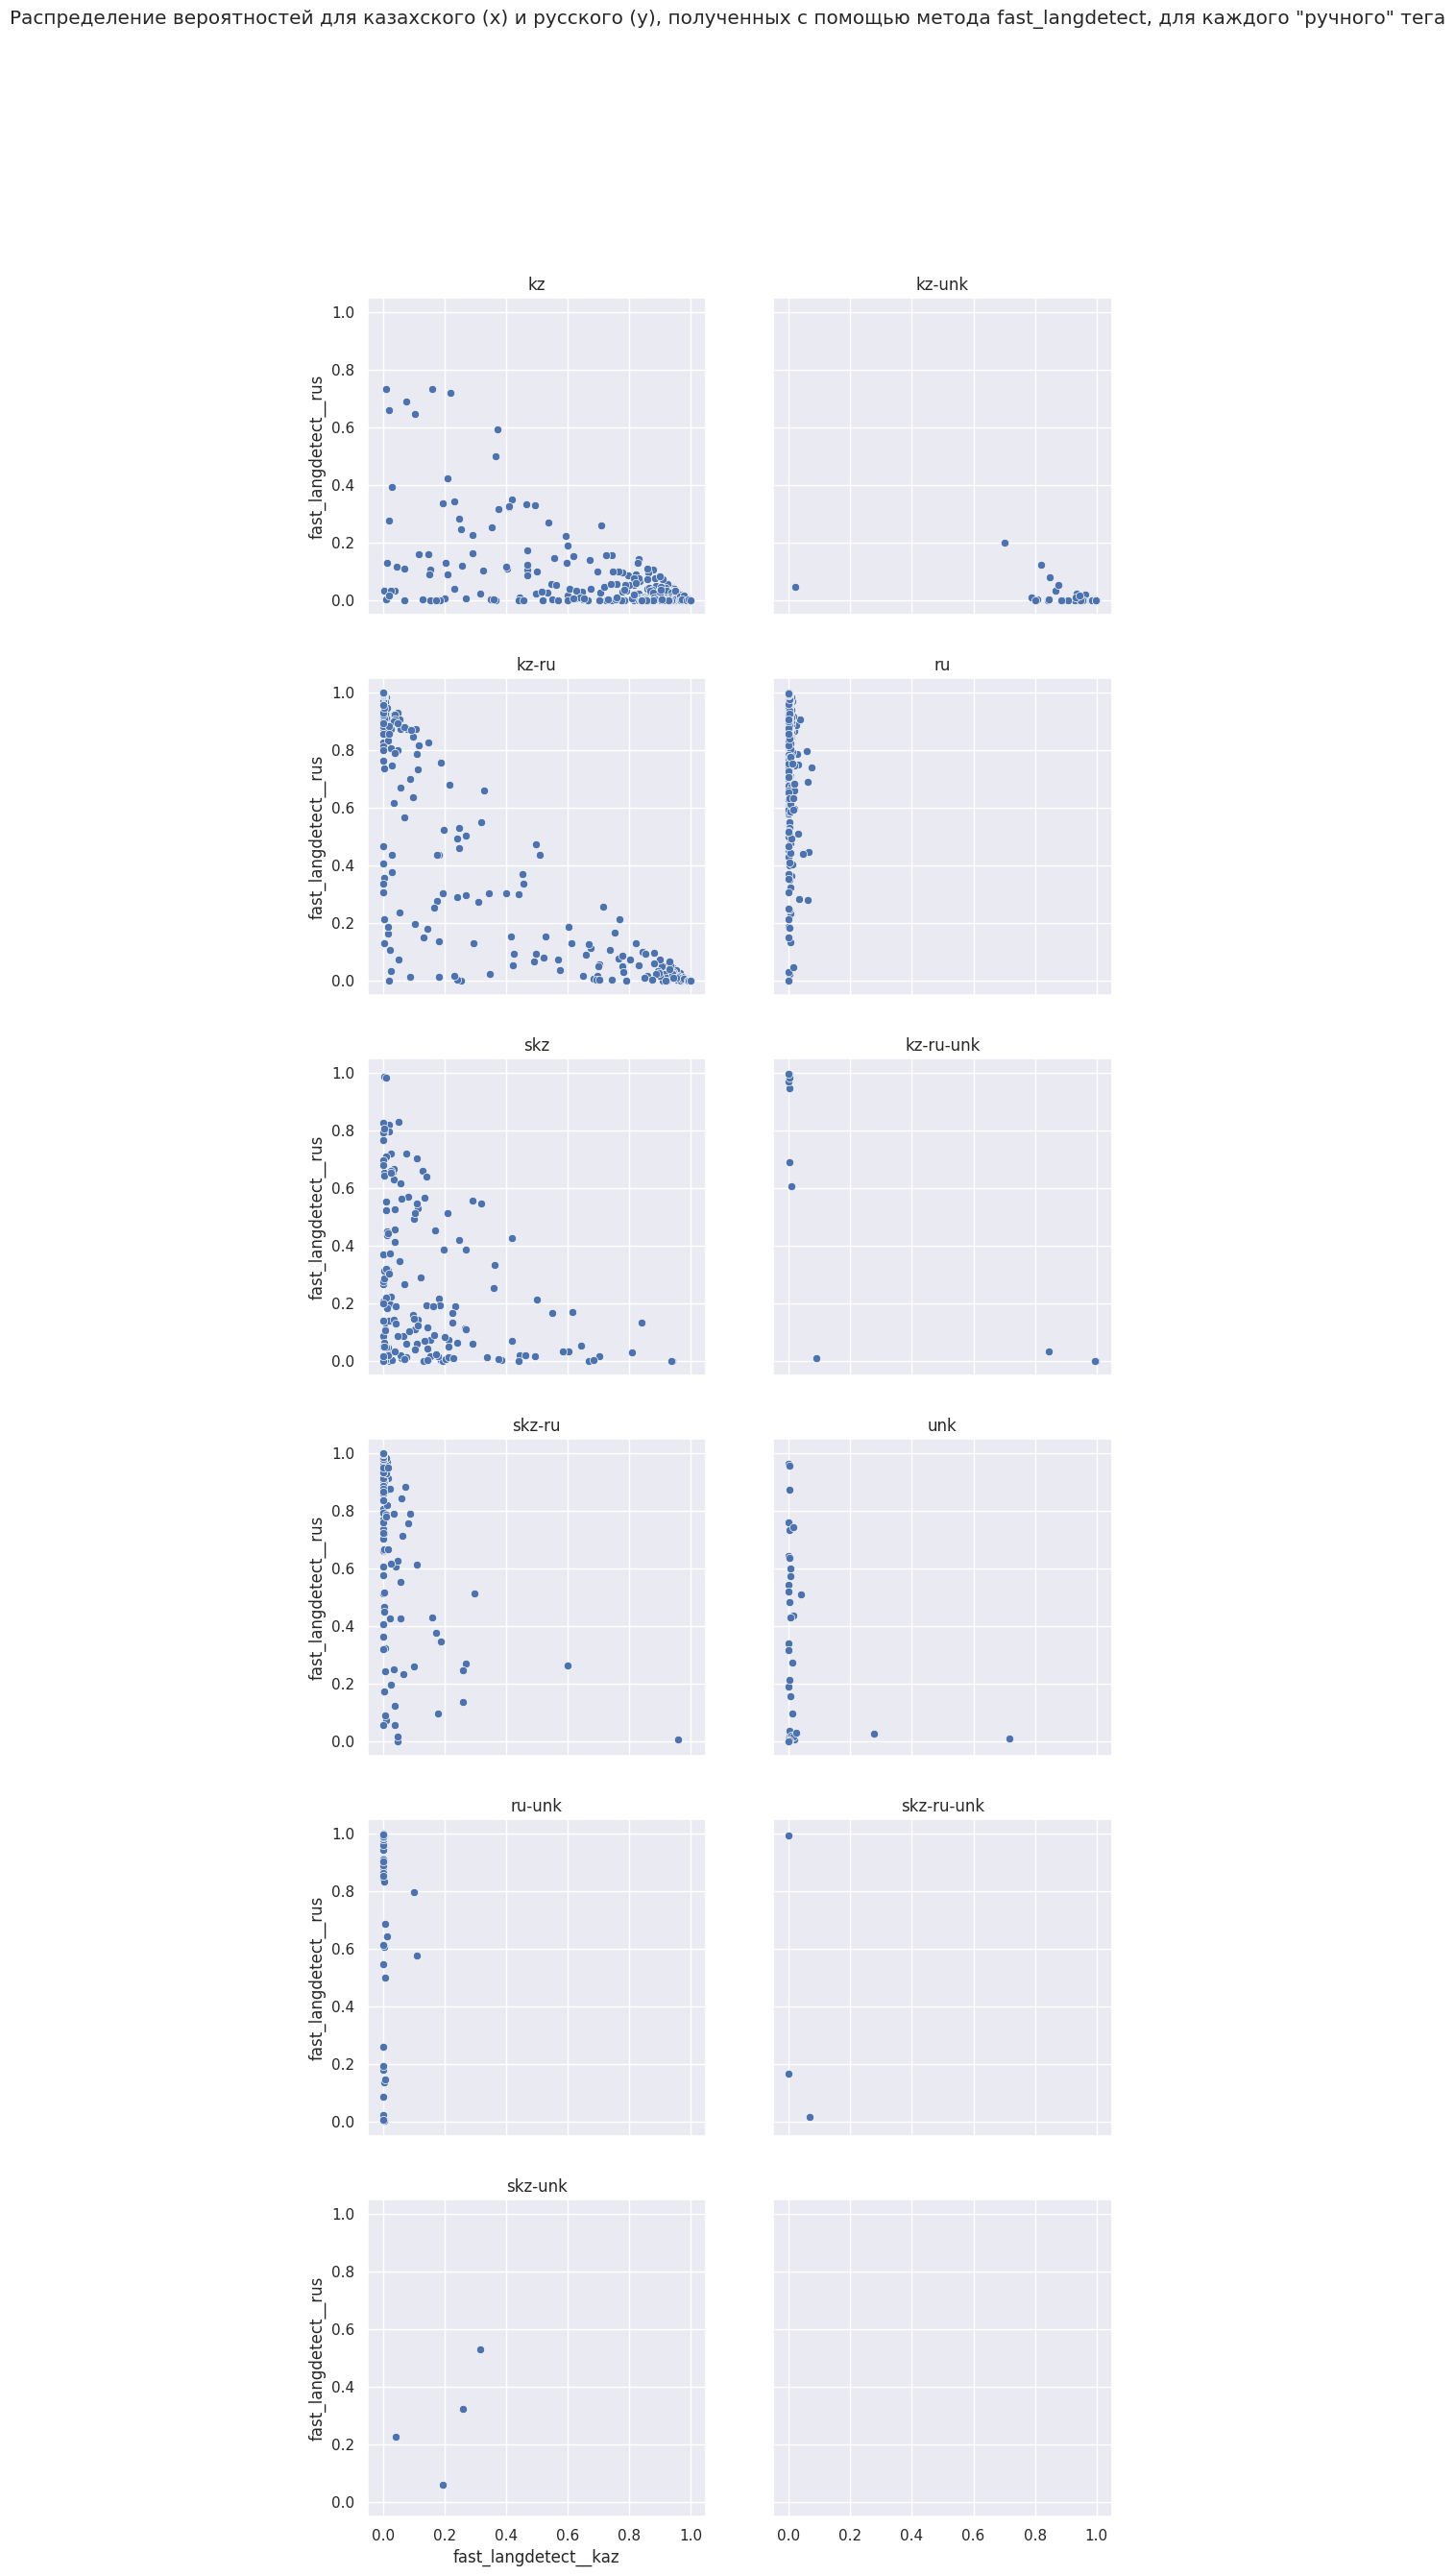

In [120]:
METHOD = 'fast_langdetect'

visualize_tags(exprmnt.df, method=METHOD, manual_col='manual_tag')

#### Q1: Для скольких одноязычных примеров (kz и ru) был правильно определен язык?

In [121]:
# какие теги предсказываются для текстов на казахском
exprmnt.df[(exprmnt.df['manual_tag'].isin(['kz']))][f'{METHOD}__best_lang'].value_counts() / len(exprmnt.df[(exprmnt.df['manual_tag'].isin(['kz']))])

,count
fast_langdetect__best_lang,
kazakh,0.987017
ukrainian,0.004117
russian,0.003800
kyrgyz,0.001583
tatar,0.001267
bulgarian,0.000633
mongolian,0.000633
bashkir,0.000633
macedonian,0.000317


In [122]:
# какие теги предсказываются для текстов на русском
exprmnt.df[(exprmnt.df['manual_tag'].isin(['ru']))][f'{METHOD}__best_lang'].value_counts() / len(exprmnt.df[(exprmnt.df['manual_tag'].isin(['ru']))])

,count
fast_langdetect__best_lang,
russian,0.996486
kyrgyz,0.000925
serbian,0.000740
bulgarian,0.000740
ukrainian,0.000370
chechen,0.000370
yakut,0.000185
mongolian,0.000185


Recall для казахского и для русского близок к "идеальному" -- 0.9870 и 0.9965

In [163]:
sample = exprmnt.df[(exprmnt.df['manual_tag'].isin(['kz', 'ru'])) | (exprmnt.df[f'{METHOD}__best_lang'].isin(['kazakh', 'russian']))].copy()
sample['manual_tag'] = sample['manual_tag'].replace({'kz': 'kazakh', 'ru': 'russian'})

print(classification_report(y_true=sample['manual_tag'], y_pred=sample[f'{METHOD}__best_lang'], labels=['kazakh', 'russian']))

              precision    recall  f1-score   support

      kazakh       0.89      0.99      0.94      3158
     russian       0.90      1.00      0.95      5407

   micro avg       0.90      0.99      0.94      8565
   macro avg       0.90      0.99      0.94      8565
weighted avg       0.90      0.99      0.94      8565



#### Q2: Что предсказывается для kz-ru?

In [123]:
counts_ = exprmnt.df[exprmnt.df['manual_tag'].isin(['kz-ru'])].groupby(['manual_tag', f'{METHOD}__best_lang'])['text'].count()
counts_ = (counts_ / exprmnt.df['manual_tag'].value_counts()).fillna(0)

cm = sns.light_palette("orange", as_cmap=True)

s = pd.DataFrame(counts_).style.background_gradient(cmap=cm)
s

Для csw-текстов предсказывается либо казахский, либо русский (44% и 51%), и только в 5% -- другие языки

#### Q3: Как хорошо метод предсказывает одноязычные тексты на нерелевантных языках?

In [124]:
# качество бинарной классификации для определения тега unk
sample = exprmnt.df[exprmnt.df['manual_tag'].isin(['kz', 'ru', 'unk', 'skz'])]
y_true = (sample['manual_tag']=='unk').astype(int)
y_pred = (~sample[f'{METHOD}__best_lang'].isin(['kazakh', 'russian'])).astype(int)

print(classification_report(y_true=y_true, y_pred=y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      8739
           1       0.13      0.51      0.21        43

    accuracy                           0.98      8782
   macro avg       0.56      0.75      0.60      8782
weighted avg       0.99      0.98      0.99      8782



In [125]:
# какие языки предсказываются для unk
sample[(sample['manual_tag']=='unk')].groupby(['manual_tag', f'{METHOD}__best_lang'])['text'].count()

manual_tag  fast_langdetect__best_lang
unk         bulgarian                      3
            chuvash                        1
            kazakh                         2
            kyrgyz                         5
            russian                       19
            ukrainian                      8
            yakut                          5
Name: text, dtype: int64

In [126]:
# для каких true тегов предсказывается "другой язык"
sample[(~sample[f'{METHOD}__best_lang'].isin(['kazakh', 'russian']))].groupby(['manual_tag', f'{METHOD}__best_lang'])['text'].count()

manual_tag  fast_langdetect__best_lang
kz          bashkir                        2
            bulgarian                      2
            kyrgyz                         5
            macedonian                     1
            mongolian                      2
            tatar                          4
            ukrainian                     13
ru          bulgarian                      4
            chechen                        2
            kyrgyz                         5
            mongolian                      1
            serbian                        4
            ukrainian                      2
            yakut                          1
skz         bashkir                        1
            belarusian                     1
            karachay-balkar                1
            kyrgyz                        82
            macedonian                     1
            mongolian                      4
            tatar                          8
unk         bulgarian                      3
            chuvash                        1
            kyrgyz                         5
            ukrainian                      8
            yakut                          5
Name: text, dtype: int64

Из всех текстов на нерелевантных языках метод выявил всего 51%, и только 13% из них в действительности нерелевантные.

Что касается ошибочного определения языка, чаще всего казахский принимается за украинский, "упрощенное" написание казахского принимается за киргизский язык.

#### Q4: Какие результаты для skz?

In [127]:
# какие языки определены для skz
y_pred = exprmnt.df[(exprmnt.df['manual_tag']=='skz')][f'{METHOD}__best_lang']

y_pred.value_counts() / len(y_pred)

,count
fast_langdetect__best_lang,
kyrgyz,0.471264
russian,0.304598
kazakh,0.132184
tatar,0.045977
mongolian,0.022989
karachay-balkar,0.005747
belarusian,0.005747
bashkir,0.005747
macedonian,0.005747


Для текстов, помеченных тегом skz в подавляющем большинстве случаев предсказывается киргизский -- 47%

#### Q5: Что получим после фильтрации?

In [128]:
y_pred = exprmnt.df[f'{METHOD}__best_lang'].isin(['kazakh', 'russian']).astype(int)

# доля тегов, которые будут выкинуты
counts_ = (exprmnt.df[y_pred==0]['manual_tag'].value_counts() / exprmnt.df['manual_tag'].value_counts()).fillna(0).rename('will_be_excluded, %')

cm = sns.light_palette("green", as_cmap=True)

s = pd.DataFrame(counts_).style.background_gradient(cmap=cm)
s

,"will_be_excluded, %"
manual_tag,
kz,0.009183
kz-ru,0.045802
kz-ru-unk,0.062500
kz-unk,0.008850
ru,0.003514
ru-unk,0.140845
skz,0.563218
skz-ru,0.102151
skz-ru-unk,0.666667


In [129]:
# абсолютные количества тегов, которые будут выкинуты
counts_ = exprmnt.df[y_pred==0]['manual_tag'].value_counts().rename('will_be_excluded')
counts_ = pd.concat([counts_,exprmnt.df['manual_tag'].value_counts().rename('total')], axis=1)
counts_.fillna(0)

,will_be_excluded,total
manual_tag,,
skz,98,174
kz,29,3158
kz-ru,24,524
unk,22,43
skz-ru,19,186
ru,19,5407
ru-unk,10,71
skz-ru-unk,2,3
kz-ru-unk,1,16


Этот способ позволит избавиться от 51% нерелевантных текстов, затронув более 4.6% примеров с csw.

## LangID

https://github.com/saffsd/langid.py (новая версия: https://github.com/adbar/py3langid)

### Анализ

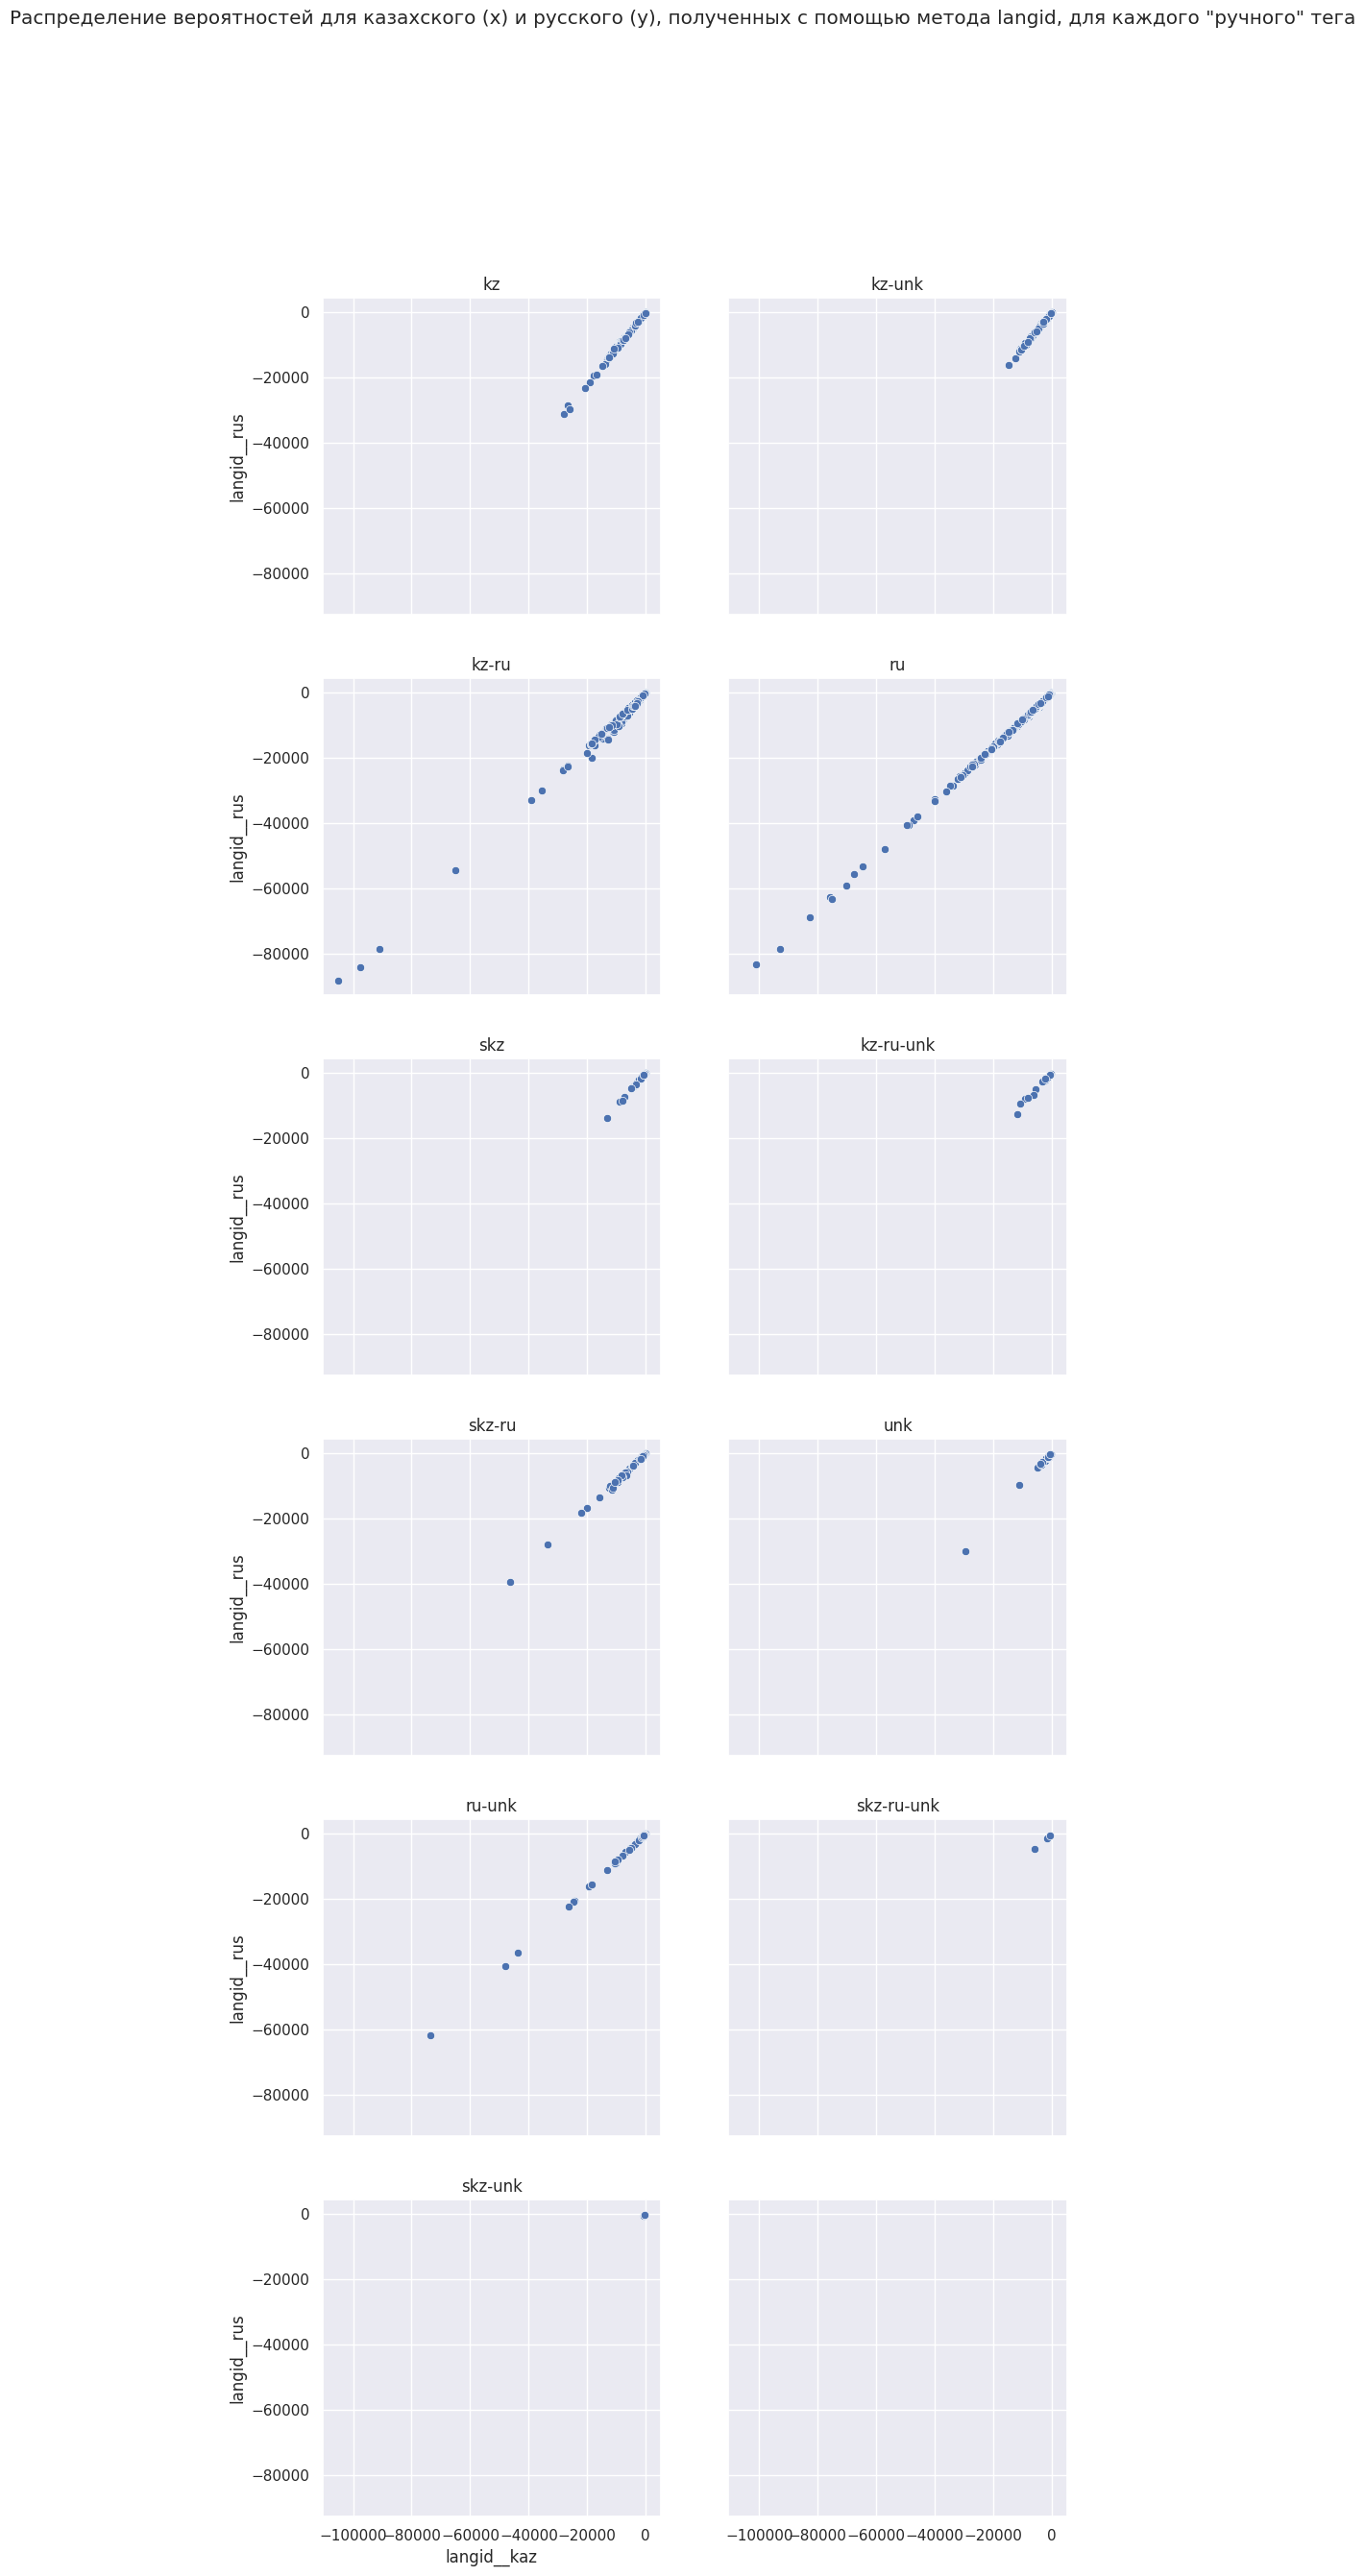

In [130]:
METHOD = 'langid'

visualize_tags(exprmnt.df, method=METHOD, manual_col='manual_tag')

#### Q1: Для скольких одноязычных примеров (kz и ru) был правильно определен язык?

In [131]:
# какие теги предсказываются для текстов на казахском
exprmnt.df[(exprmnt.df['manual_tag'].isin(['kz']))][f'{METHOD}__best_lang'].value_counts() / len(exprmnt.df[(exprmnt.df['manual_tag'].isin(['kz']))])

,count
langid__best_lang,
kazakh,0.981317
russian,0.014566
macedonian,0.000950
ukrainian,0.000950
mongolian,0.000950
belarusian,0.000633
serbian,0.000633


In [132]:
# какие теги предсказываются для текстов на русском
exprmnt.df[(exprmnt.df['manual_tag'].isin(['ru']))][f'{METHOD}__best_lang'].value_counts() / len(exprmnt.df[(exprmnt.df['manual_tag'].isin(['ru']))])

,count
langid__best_lang,
russian,0.917329
bulgarian,0.033660
ukrainian,0.017200
serbian,0.012391
macedonian,0.011282
kazakh,0.004254
belarusian,0.003329
mongolian,0.000370
kyrgyz,0.000185


Recall для казахского значительно выше, чем для русского -- 0.98 против 0.92

In [162]:
sample = exprmnt.df[(exprmnt.df['manual_tag'].isin(['kz', 'ru'])) | (exprmnt.df[f'{METHOD}__best_lang'].isin(['kazakh', 'russian']))].copy()
sample['manual_tag'] = sample['manual_tag'].replace({'kz': 'kazakh', 'ru': 'russian'})

print(classification_report(y_true=sample['manual_tag'], y_pred=sample[f'{METHOD}__best_lang'], labels=['kazakh', 'russian']))

              precision    recall  f1-score   support

      kazakh       0.88      0.98      0.93      3158
     russian       0.88      0.92      0.90      5407

   micro avg       0.88      0.94      0.91      8565
   macro avg       0.88      0.95      0.91      8565
weighted avg       0.88      0.94      0.91      8565



#### Q2: Что предсказывается для kz-ru?

In [133]:
counts_ = exprmnt.df[exprmnt.df['manual_tag'].isin(['kz-ru'])].groupby(['manual_tag', f'{METHOD}__best_lang'])['text'].count()
counts_ = (counts_ / exprmnt.df['manual_tag'].value_counts()).fillna(0)

cm = sns.light_palette("orange", as_cmap=True)

s = pd.DataFrame(counts_).style.background_gradient(cmap=cm)
s

Для csw-текстов предсказывается в основном либо казахский, либо русский? причем в отличие от других методов, langid в таких случаях значительно охотнее предсказывает русский язык (60%), чем казахский (35%).

#### Q3: Как хорошо метод предсказывает одноязычные тексты на нерелевантных языках?

In [134]:
# качество бинарной классификации для определения тега unk
sample = exprmnt.df[exprmnt.df['manual_tag'].isin(['kz', 'ru', 'unk', 'skz'])]
y_true = (sample['manual_tag']=='unk').astype(int)
y_pred = (~sample[f'{METHOD}__best_lang'].isin(['kazakh', 'russian'])).astype(int)

print(classification_report(y_true=y_true, y_pred=y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97      8739
           1       0.05      0.56      0.09        43

    accuracy                           0.95      8782
   macro avg       0.52      0.75      0.53      8782
weighted avg       0.99      0.95      0.97      8782



In [135]:
# какие языки предсказываются для unk
sample[(sample['manual_tag']=='unk')].groupby(['manual_tag', f'{METHOD}__best_lang'])['text'].count()

manual_tag  langid__best_lang
unk         belarusian            2
            bulgarian             2
            kazakh                8
            kyrgyz                1
            mongolian             5
            russian              11
            serbian               2
            ukrainian            12
Name: text, dtype: int64

In [136]:
# для каких true тегов предсказывается "другой язык"
sample[(~sample[f'{METHOD}__best_lang'].isin(['kazakh', 'russian']))].groupby(['manual_tag', f'{METHOD}__best_lang'])['text'].count()

manual_tag  langid__best_lang
kz          belarusian             2
            macedonian             3
            mongolian              3
            serbian                2
            ukrainian              3
ru          belarusian            18
            bulgarian            182
            kyrgyz                 1
            macedonian            61
            mongolian              2
            serbian               67
            ukrainian             93
skz         belarusian             3
            bulgarian              1
            kyrgyz                12
            macedonian             2
            mongolian              2
            serbian                3
            ukrainian              2
unk         belarusian             2
            bulgarian              2
            kyrgyz                 1
            mongolian              5
            serbian                2
            ukrainian             12
Name: text, dtype: int64

Из всех текстов на нерелевантных языках метод выявил всего 56%. При этом 95% текстов, определенных как "нерелевантные" на самом деле содержат казахский или русский.

Что касается ошибочного определения языка, чаще всего казахский принимается за киргизский, русский -- за болгарский, украинский, македонский, сербский, "упрощенное" написание казахского также принимается за киргизский язык.

#### Q4: Какие результаты для skz?

In [137]:
# какие языки определены для skz
y_pred = exprmnt.df[(exprmnt.df['manual_tag']=='skz')][f'{METHOD}__best_lang']

y_pred.value_counts() / len(y_pred)

,count
langid__best_lang,
kazakh,0.517241
russian,0.339080
kyrgyz,0.068966
serbian,0.017241
belarusian,0.017241
macedonian,0.011494
mongolian,0.011494
ukrainian,0.011494
bulgarian,0.005747


Для текстов, помеченных тегом skz в половине случаев (52%) предсказывается казахский, в третьи случаев (34%) -- русский.

#### Q5: Что получим после фильтрации?

In [138]:
y_pred = exprmnt.df[f'{METHOD}__best_lang'].isin(['kazakh', 'russian']).astype(int)

# доля тегов, которые будут выкинуты
counts_ = (exprmnt.df[y_pred==0]['manual_tag'].value_counts() / exprmnt.df['manual_tag'].value_counts()).fillna(0).rename('will_be_excluded, %')

cm = sns.light_palette("green", as_cmap=True)

s = pd.DataFrame(counts_).style.background_gradient(cmap=cm)
s

,"will_be_excluded, %"
manual_tag,
kz,0.004117
kz-ru,0.047710
kz-ru-unk,0.000000
kz-unk,0.008850
ru,0.078417
ru-unk,0.169014
skz,0.143678
skz-ru,0.064516
skz-ru-unk,0.333333


In [139]:
# абсолютные количества тегов, которые будут выкинуты
counts_ = exprmnt.df[y_pred==0]['manual_tag'].value_counts().rename('will_be_excluded')
counts_ = pd.concat([counts_,exprmnt.df['manual_tag'].value_counts().rename('total')], axis=1)
counts_.fillna(0)

,will_be_excluded,total
manual_tag,,
ru,424.0,5407
skz,25.0,174
kz-ru,25.0,524
unk,24.0,43
kz,13.0,3158
skz-ru,12.0,186
ru-unk,12.0,71
skz-unk,1.0,4
kz-unk,1.0,113


Этот способ позволит избавиться от 56% нерелевантных текстов, затронув около 5% примеров с csw.

## Lingua
https://pypi.org/project/lingua-language-detector/

### Анализ

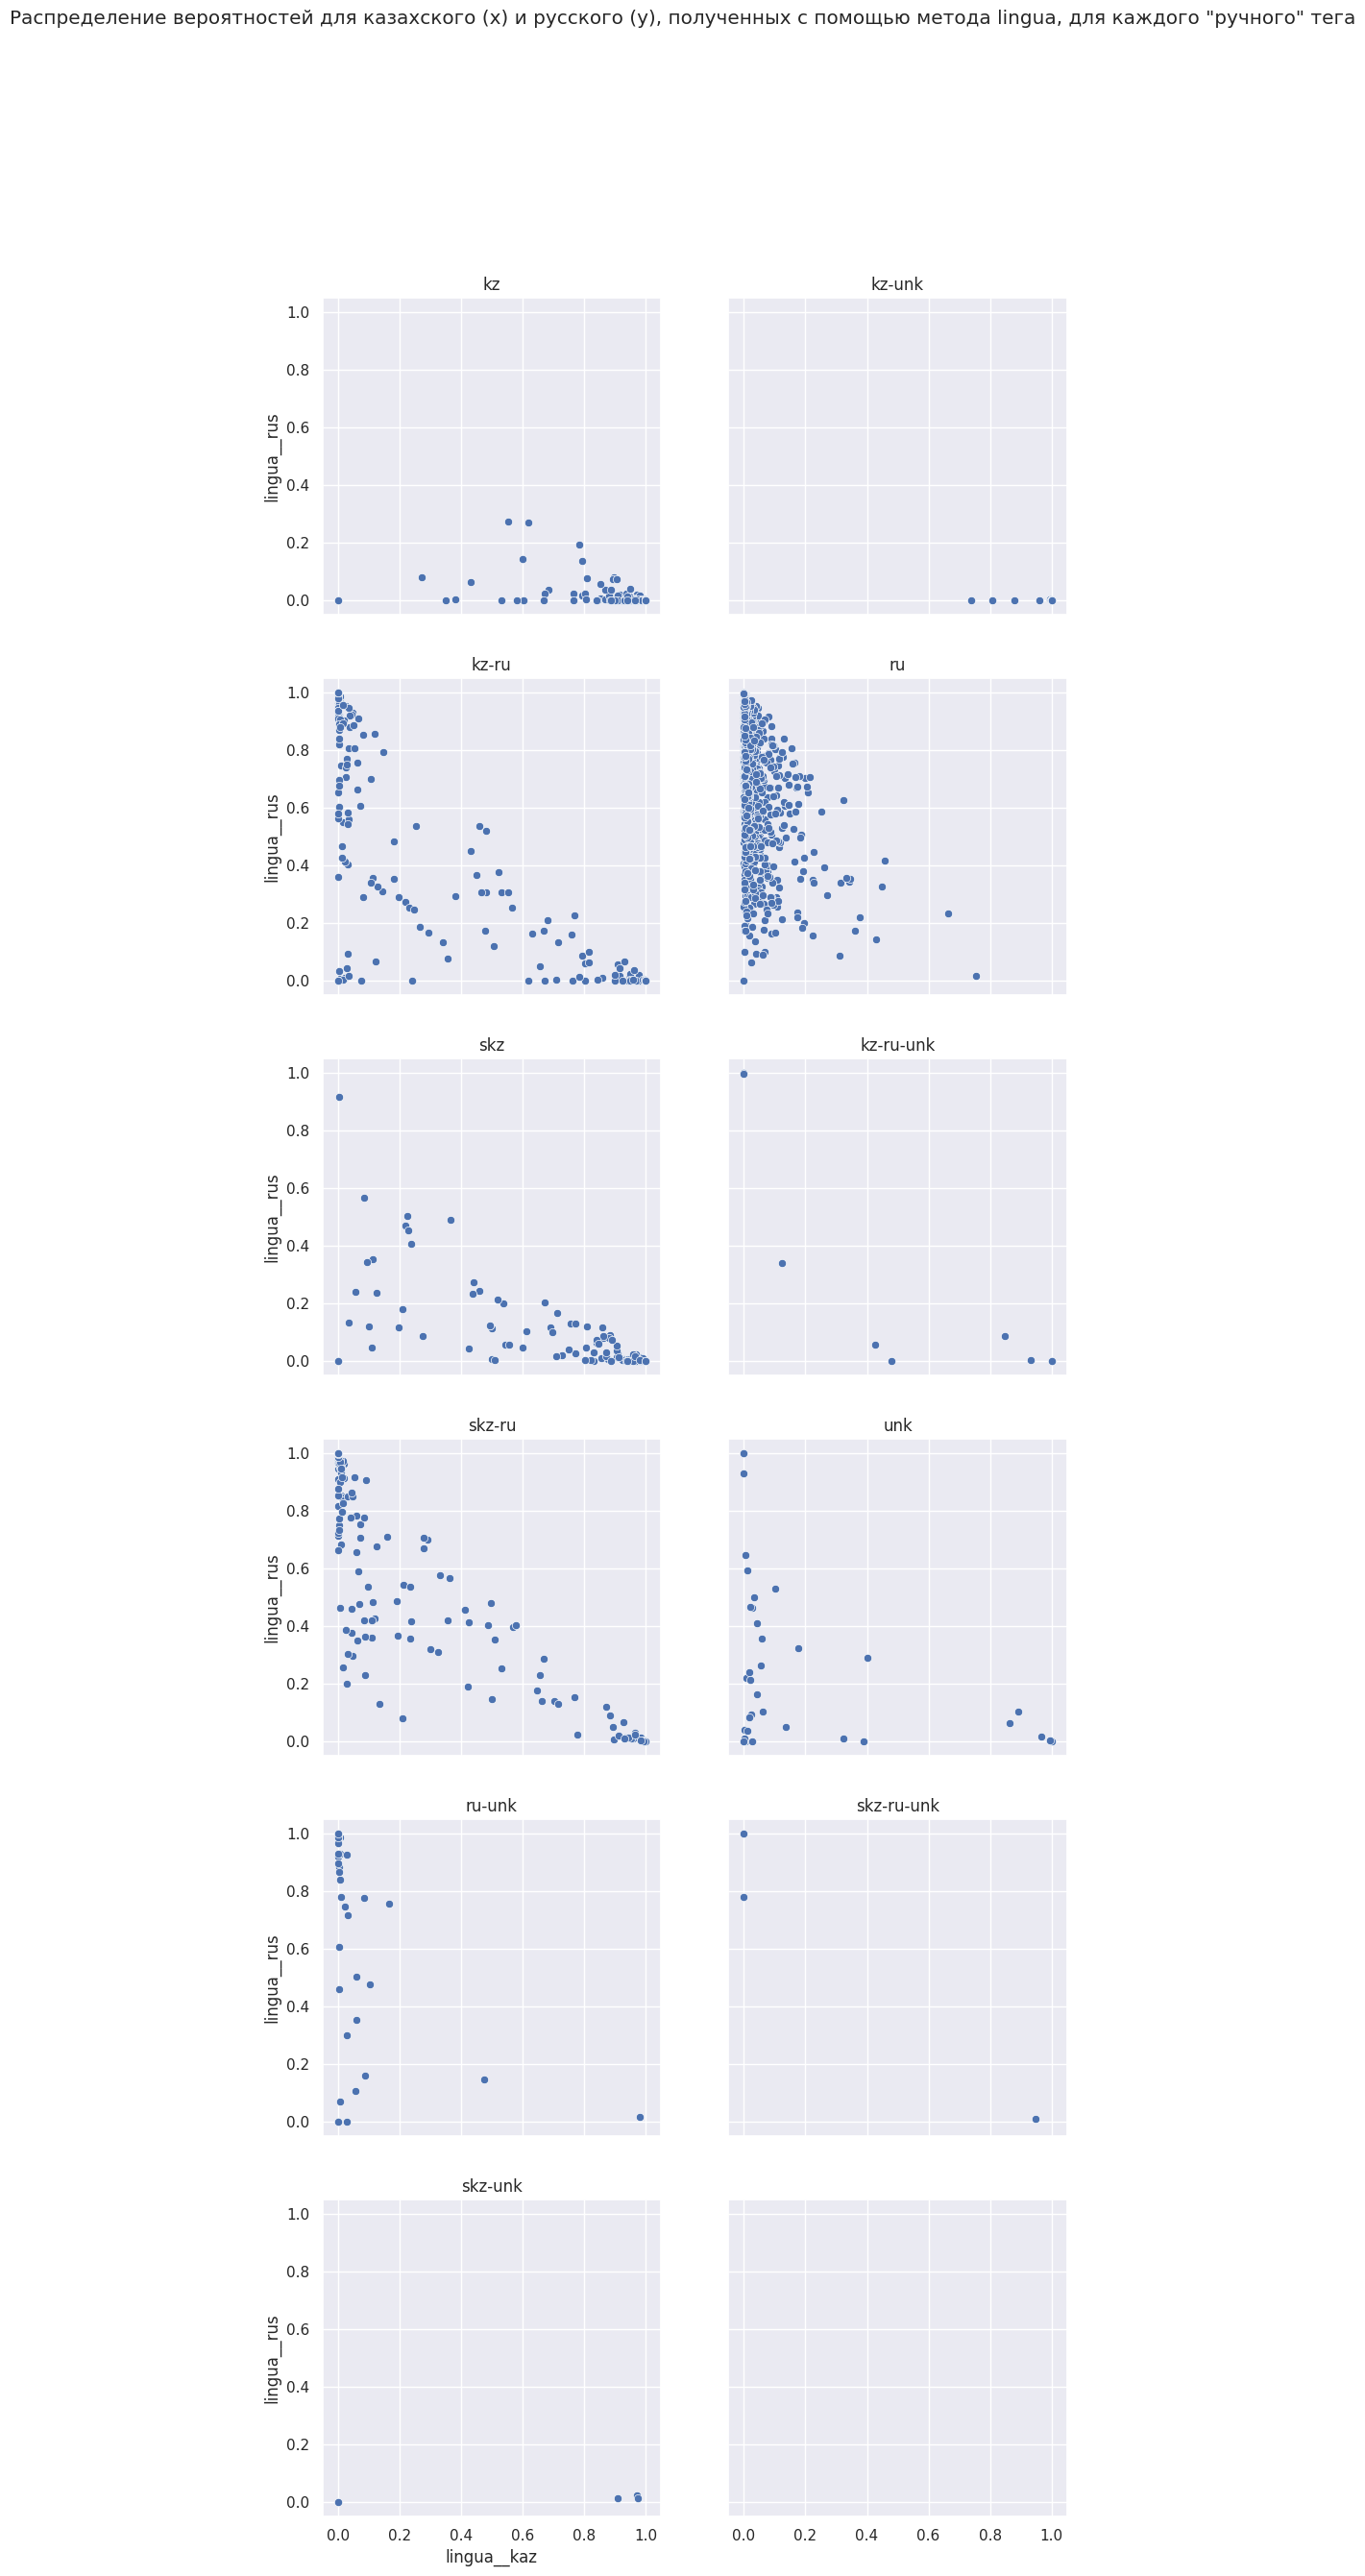

In [140]:
METHOD = 'lingua'

visualize_tags(exprmnt.df, method=METHOD, manual_col='manual_tag')

In [516]:
corrections = {'skz':'kz', 'skz-ru': 'kz-ru', 'skz-ru-unk': 'kz-ru-unk', 'skz-unk': 'kz-unk'}
exprmnt.df['manual_tag_adj'] = exprmnt.df['manual_tag'].replace(corrections)
exprmnt.df['manual_tag_adj'].value_counts()

,count
manual_tag_adj,
ru,5407
kz,3332
kz-ru,710
kz-unk,117
ru-unk,71
unk,43
kz-ru-unk,19


In [517]:
# direct csw prediction
y_true = exprmnt.df['manual_tag_adj'].str.contains('kz-ru')
y_pred = exprmnt.df['lingua__all_langs'].str.contains('kz-ru')

print(classification_report(y_true=y_true, y_pred=y_pred))

              precision    recall  f1-score   support

       False       0.95      0.97      0.96      8970
        True       0.48      0.39      0.43       729

    accuracy                           0.92      9699
   macro avg       0.71      0.68      0.69      9699
weighted avg       0.92      0.92      0.92      9699



In [519]:
# какие предсказания дает lingua для csw-текстов
df[(y_true==1)]['lingua__all_langs'].value_counts()

,count
lingua__all_langs,
kz-ru,154
kz,150
kz-ru-unk,127
ru-unk,121
ru,99
kz-unk,42
unk,36


#### Q1: Для скольких одноязычных примеров (kz и ru) был правильно определен язык?

In [141]:
# какие теги предсказываются для текстов на казахском
exprmnt.df[(exprmnt.df['manual_tag'].isin(['kz']))][f'{METHOD}__best_lang'].value_counts() / len(exprmnt.df[(exprmnt.df['manual_tag'].isin(['kz']))])

,count
lingua__best_lang,
kazakh,0.999050
somali,0.000317
macedonian,0.000317
belarusian,0.000317


In [142]:
# какие теги предсказываются для текстов на русском
exprmnt.df[(exprmnt.df['manual_tag'].isin(['ru']))][f'{METHOD}__best_lang'].value_counts() / len(exprmnt.df[(exprmnt.df['manual_tag'].isin(['ru']))])

,count
lingua__best_lang,
russian,0.985944
bulgarian,0.003514
mongolian,0.002774
ukrainian,0.002589
macedonian,0.001849
kazakh,0.001665
serbian,0.000925
belarusian,0.000740


In [160]:
sample = exprmnt.df[(exprmnt.df['manual_tag'].isin(['kz', 'ru'])) | (exprmnt.df[f'{METHOD}__best_lang'].isin(['kazakh', 'russian']))].copy()
sample['manual_tag'] = sample['manual_tag'].replace({'kz': 'kazakh', 'ru': 'russian'})

print(classification_report(y_true=sample['manual_tag'], y_pred=sample[f'{METHOD}__best_lang'], labels=['kazakh', 'russian']))

              precision    recall  f1-score   support

      kazakh       0.84      1.00      0.91      3158
     russian       0.92      0.99      0.95      5407

   micro avg       0.89      0.99      0.94      8565
   macro avg       0.88      0.99      0.93      8565
weighted avg       0.89      0.99      0.94      8565



Recall для казахского значительно почти идеальный -- 0.9990 и 0.9859

#### Q2: Что предсказывается для kz-ru?

In [143]:
counts_ = exprmnt.df[exprmnt.df['manual_tag'].isin(['kz-ru'])].groupby(['manual_tag', f'{METHOD}__best_lang'])['text'].count()
counts_ = (counts_ / exprmnt.df['manual_tag'].value_counts()).fillna(0)

cm = sns.light_palette("orange", as_cmap=True)

s = pd.DataFrame(counts_).style.background_gradient(cmap=cm)
s

Для csw-текстов предсказывается в основном либо казахский, либо русский -- 52% и 45%.

#### Q3: Как хорошо метод предсказывает одноязычные тексты на нерелевантных языках?

In [144]:
# качество бинарной классификации для определения тега unk
sample = exprmnt.df[exprmnt.df['manual_tag'].isin(['kz', 'ru', 'unk', 'skz'])]
y_true = (sample['manual_tag']=='unk').astype(int)
y_pred = (~sample[f'{METHOD}__best_lang'].isin(['kazakh', 'russian'])).astype(int)

print(classification_report(y_true=y_true, y_pred=y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      8739
           1       0.24      0.58      0.34        43

    accuracy                           0.99      8782
   macro avg       0.62      0.79      0.66      8782
weighted avg       0.99      0.99      0.99      8782



In [145]:
# какие языки предсказываются для unk
sample[(sample['manual_tag']=='unk')].groupby(['manual_tag', f'{METHOD}__best_lang'])['text'].count()

manual_tag  lingua__best_lang
unk         belarusian            2
            bulgarian             1
            english               1
            kazakh                6
            mongolian            10
            russian              12
            serbian               1
            ukrainian            10
Name: text, dtype: int64

In [146]:
# для каких true тегов предсказывается "другой язык"
sample[(~sample[f'{METHOD}__best_lang'].isin(['kazakh', 'russian']))].groupby(['manual_tag', f'{METHOD}__best_lang'])['text'].count()

manual_tag  lingua__best_lang
kz          belarusian            1
            macedonian            1
            somali                1
ru          belarusian            4
            bulgarian            19
            macedonian           10
            mongolian            15
            serbian               5
            ukrainian            14
skz         bulgarian             1
            mongolian             9
            serbian               1
unk         belarusian            2
            bulgarian             1
            english               1
            mongolian            10
            serbian               1
            ukrainian            10
Name: text, dtype: int64

Из всех текстов на нерелевантных языках метод выявил всего 58%. 76% текстов, определенных как "нерелевантные" на самом деле содержат казахский или русский.

Что касается ошибочного определения языка, чаще всего русский определяется как болгарский, монгольский и украинский, "упрощенное" написание казахского также принимается за монгольский язык.

#### Q4: Какие результаты для skz?

In [147]:
# какие языки определены для skz
y_pred = exprmnt.df[(exprmnt.df['manual_tag']=='skz')][f'{METHOD}__best_lang']

y_pred.value_counts() / len(y_pred)

,count
lingua__best_lang,
kazakh,0.890805
mongolian,0.051724
russian,0.045977
bulgarian,0.005747
serbian,0.005747


Для текстов, помеченных тегом skz в подавляющем большинстве случаев (89%) предсказывается казахский.

#### Q5: Что получим после фильтрации?

In [148]:
y_pred = exprmnt.df[f'{METHOD}__best_lang'].isin(['kazakh', 'russian']).astype(int)

# доля тегов, которые будут выкинуты
counts_ = (exprmnt.df[y_pred==0]['manual_tag'].value_counts() / exprmnt.df['manual_tag'].value_counts()).fillna(0).rename('will_be_excluded, %')

cm = sns.light_palette("green", as_cmap=True)

s = pd.DataFrame(counts_).style.background_gradient(cmap=cm)
s

,"will_be_excluded, %"
manual_tag,
kz,0.000950
kz-ru,0.038168
kz-ru-unk,0.125000
kz-unk,0.000000
ru,0.012391
ru-unk,0.140845
skz,0.063218
skz-ru,0.043011
skz-ru-unk,0.000000


In [149]:
# абсолютные количества тегов, которые будут выкинуты
counts_ = exprmnt.df[y_pred==0]['manual_tag'].value_counts().rename('will_be_excluded')
counts_ = pd.concat([counts_,exprmnt.df['manual_tag'].value_counts().rename('total')], axis=1)
counts_.fillna(0)

,will_be_excluded,total
manual_tag,,
ru,67.0,5407
unk,25.0,43
kz-ru,20.0,524
skz,11.0,174
ru-unk,10.0,71
skz-ru,8.0,186
kz,3.0,3158
kz-ru-unk,2.0,16
skz-unk,1.0,4


Этот способ позволит избавиться от 58% нерелевантных текстов, затронув около 4% примеров с csw.

## MediaPipe (Language deteciton)

https://ai.google.dev/edge/mediapipe/solutions/text/language_detector


архитектура: https://storage.googleapis.com/mediapipe-assets/LanguageDetector%20Model%20Card.pdf

### Анализ

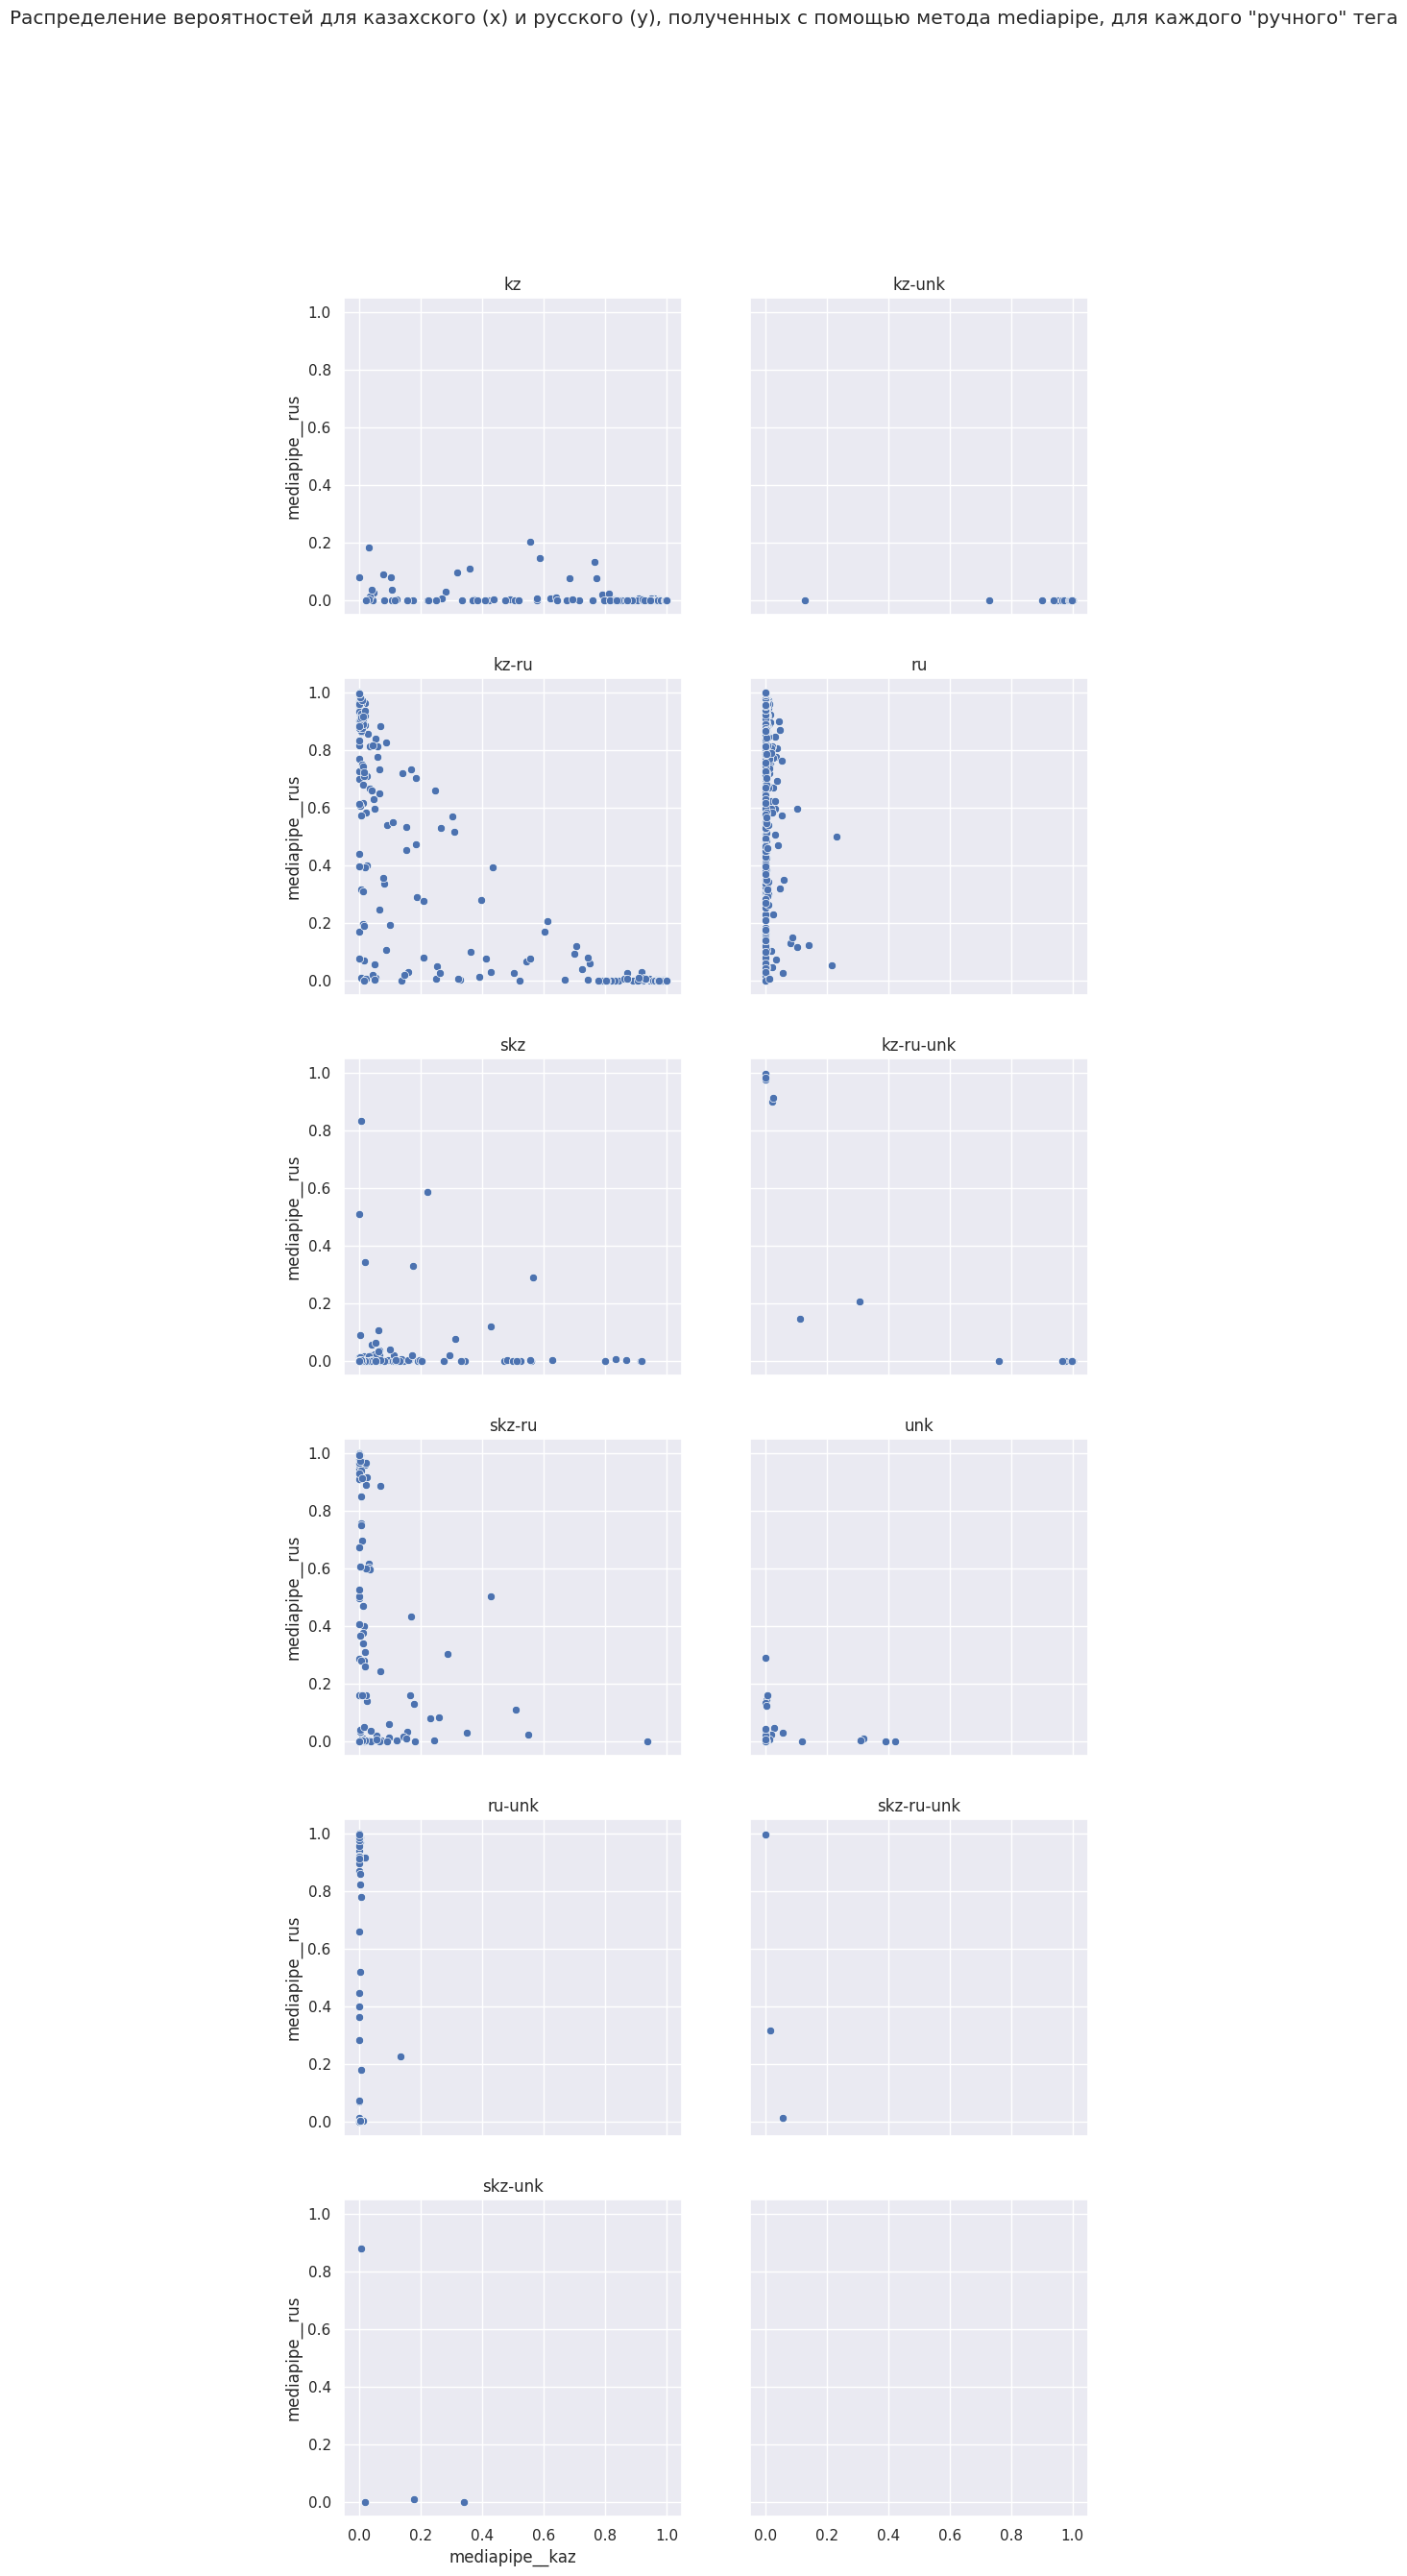

In [177]:
METHOD = 'mediapipe'

visualize_tags(exprmnt.df, method=METHOD, manual_col='manual_tag')

#### Q1: Для скольких одноязычных примеров (kz и ru) был правильно определен язык?

In [178]:
# какие теги предсказываются для текстов на казахском
exprmnt.df[(exprmnt.df['manual_tag'].isin(['kz']))][f'{METHOD}__best_lang'].value_counts() / len(exprmnt.df[(exprmnt.df['manual_tag'].isin(['kz']))])

,count
mediapipe__best_lang,
kazakh,0.990500
kyrgyz,0.006016
unknown,0.002217
bulgarian,0.000633
ukrainian,0.000317
tajik,0.000317


In [179]:
# какие теги предсказываются для текстов на русском
exprmnt.df[(exprmnt.df['manual_tag'].isin(['ru']))][f'{METHOD}__best_lang'].value_counts() / len(exprmnt.df[(exprmnt.df['manual_tag'].isin(['ru']))])

,count
mediapipe__best_lang,
russian,0.981136
bulgarian,0.009802
kyrgyz,0.003329
ukrainian,0.001849
serbian,0.001480
unknown,0.001110
mongolian,0.000740
macedonian,0.000555


Recall для казахского значительно почти идеальный -- 0.9905 и 0.9811

In [181]:
sample = exprmnt.df[(exprmnt.df['manual_tag'].isin(['kz', 'ru'])) | (exprmnt.df[f'{METHOD}__best_lang'].isin(['kazakh', 'russian']))].copy()
sample['manual_tag'] = sample['manual_tag'].replace({'kz': 'kazakh', 'ru': 'russian'})

print(classification_report(y_true=sample['manual_tag'], y_pred=sample[f'{METHOD}__best_lang'], labels=['kazakh', 'russian']))

              precision    recall  f1-score   support

      kazakh       0.89      0.99      0.94      3158
     russian       0.92      0.98      0.95      5407

   micro avg       0.91      0.98      0.95      8565
   macro avg       0.91      0.99      0.94      8565
weighted avg       0.91      0.98      0.95      8565



In [ ]:
# точность
accuracy_score(y_true=sample['manual_tag'], y_pred=sample[f'{METHOD}__best_lang'])

#### Q2: Что предсказывается для kz-ru?

In [182]:
counts_ = exprmnt.df[exprmnt.df['manual_tag'].isin(['kz-ru'])].groupby(['manual_tag', f'{METHOD}__best_lang'])['text'].count()
counts_ = (counts_ / exprmnt.df['manual_tag'].value_counts()).fillna(0)

cm = sns.light_palette("orange", as_cmap=True)

s = pd.DataFrame(counts_).style.background_gradient(cmap=cm)
s

Для csw-текстов предсказывается в основном либо казахский, либо русский -- 47% и 48%.

#### Q3: Как хорошо метод предсказывает одноязычные тексты на нерелевантных языках?

In [183]:
# качество бинарной классификации для определения тега unk
sample = exprmnt.df[exprmnt.df['manual_tag'].isin(['kz', 'ru', 'unk', 'skz'])]
y_true = (sample['manual_tag']=='unk').astype(int)
y_pred = (~sample[f'{METHOD}__best_lang'].isin(['kazakh', 'russian'])).astype(int)

print(classification_report(y_true=y_true, y_pred=y_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98      8739
           1       0.12      0.95      0.22        43

    accuracy                           0.97      8782
   macro avg       0.56      0.96      0.60      8782
weighted avg       1.00      0.97      0.98      8782



In [184]:
# какие языки предсказываются для unk
sample[(sample['manual_tag']=='unk')].groupby(['manual_tag', f'{METHOD}__best_lang'])['text'].count()

manual_tag  mediapipe__best_lang
unk         bulgarian                1
            kazakh                   2
            kyrgyz                  23
            mongolian                2
            tajik                    3
            ukrainian                9
            unknown                  3
Name: text, dtype: int64

In [185]:
# для каких true тегов предсказывается "другой язык"
sample[(~sample[f'{METHOD}__best_lang'].isin(['kazakh', 'russian']))].groupby(['manual_tag', f'{METHOD}__best_lang'])['text'].count()

manual_tag  mediapipe__best_lang
kz          bulgarian                 2
            kyrgyz                   19
            tajik                     1
            ukrainian                 1
            unknown                   7
ru          bulgarian                53
            kyrgyz                   18
            macedonian                3
            mongolian                 4
            serbian                   8
            ukrainian                10
            unknown                   6
skz         bulgarian                 1
            kyrgyz                  149
            tajik                     1
            unknown                   4
unk         bulgarian                 1
            kyrgyz                   23
            mongolian                 2
            tajik                     3
            ukrainian                 9
            unknown                   3
Name: text, dtype: int64

Из всех текстов на нерелевантных языках метод выявил всего 92%. 12% из всех текстов, определенных как "нерелевантные" на самом деле содержат казахский или русский.

Что касается ошибочного определения языка, чаще всего русский определяется как болгарский, киргизский и украинский, "упрощенное" написание казахского принимается за киргизский язык.

#### Q4: Какие результаты для skz?

In [186]:
# какие языки определены для skz
y_pred = exprmnt.df[(exprmnt.df['manual_tag']=='skz')][f'{METHOD}__best_lang']

y_pred.value_counts() / len(y_pred)

,count
mediapipe__best_lang,
kyrgyz,0.856322
kazakh,0.080460
russian,0.028736
unknown,0.022989
bulgarian,0.005747
tajik,0.005747


Для текстов, помеченных тегом skz в подавляющем большинстве случаев (86%) предсказывается киргизский.

#### Q5: Что получим после фильтрации?

In [187]:
y_pred = exprmnt.df[f'{METHOD}__best_lang'].isin(['kazakh', 'russian']).astype(int)

# доля тегов, которые будут выкинуты
counts_ = (exprmnt.df[y_pred==0]['manual_tag'].value_counts() / exprmnt.df['manual_tag'].value_counts()).fillna(0).rename('will_be_excluded, %')

cm = sns.light_palette("green", as_cmap=True)

s = pd.DataFrame(counts_).style.background_gradient(cmap=cm)
s

,"will_be_excluded, %"
manual_tag,
kz,0.009500
kz-ru,0.045802
kz-ru-unk,0.125000
kz-unk,0.008850
ru,0.018864
ru-unk,0.211268
skz,0.890805
skz-ru,0.333333
skz-ru-unk,0.333333


In [188]:
# абсолютные количества тегов, которые будут выкинуты
counts_ = exprmnt.df[y_pred==0]['manual_tag'].value_counts().rename('will_be_excluded')
counts_ = pd.concat([counts_,exprmnt.df['manual_tag'].value_counts().rename('total')], axis=1)
counts_.fillna(0)

,will_be_excluded,total
manual_tag,,
skz,155,174
ru,102,5407
skz-ru,62,186
unk,41,43
kz,30,3158
kz-ru,24,524
ru-unk,15,71
skz-unk,3,4
kz-ru-unk,2,16


Этот способ позволит избавиться от 95% нерелевантных текстов, затронув около 5% примеров с csw.

## GlotLID

### Анализ

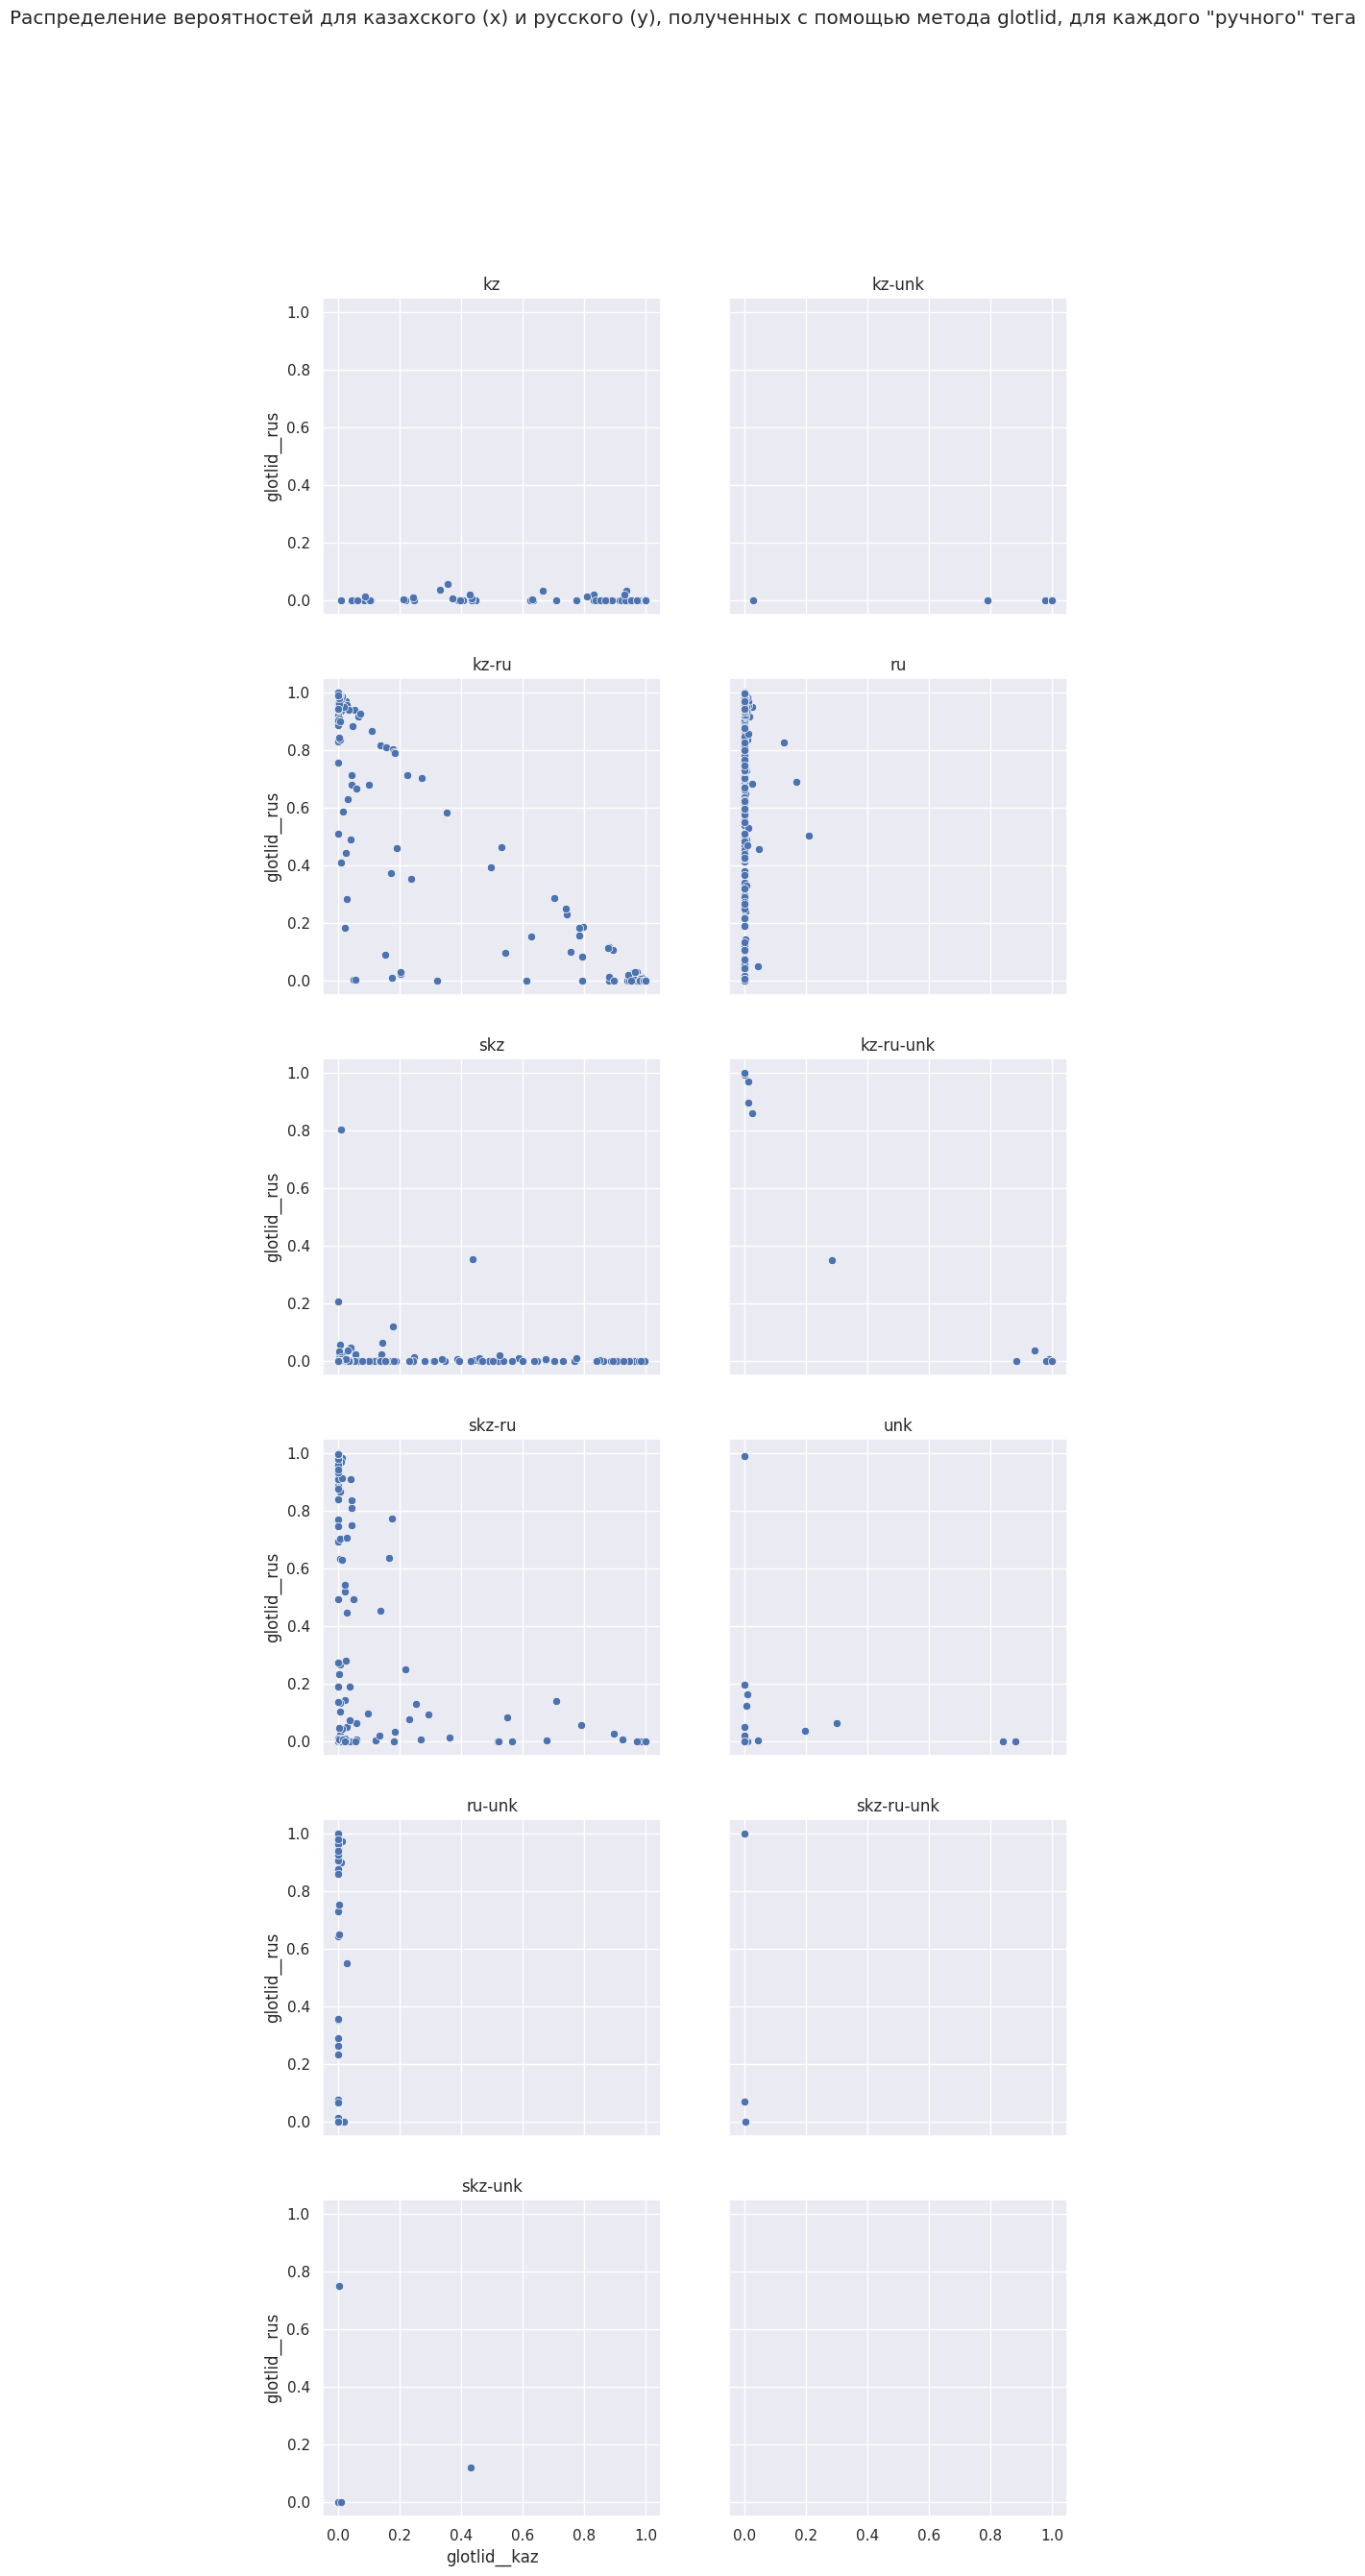

In [189]:
METHOD = 'glotlid'

visualize_tags(exprmnt.df, method=METHOD, manual_col='manual_tag')

#### Q1: Для скольких одноязычных примеров (kz и ru) был правильно определен язык?

In [190]:
# какие теги предсказываются для текстов на казахском
exprmnt.df[(exprmnt.df['manual_tag'].isin(['kz']))][f'{METHOD}__best_lang'].value_counts() / len(exprmnt.df[(exprmnt.df['manual_tag'].isin(['kz']))])

,count
glotlid__best_lang,
kazakh,0.994934
bashkir,0.001267
kyrgyz,0.000633
halh mongolian,0.000633
kara-kalpak,0.000317
tatar,0.000317
tajik,0.000317
khakas,0.000317
kalmyk,0.000317


In [191]:
# какие теги предсказываются для текстов на русском
exprmnt.df[(exprmnt.df['manual_tag'].isin(['ru']))][f'{METHOD}__best_lang'].value_counts() / len(exprmnt.df[(exprmnt.df['manual_tag'].isin(['ru']))])

,count
glotlid__best_lang,
russian,0.990753
old russian,0.003699
bulgarian,0.001480
khakas,0.000925
yakut,0.000740
ukrainian,0.000555
serbian,0.000370
und,0.000370
karachay-balkar,0.000185


Recall для казахского значительно почти идеальный -- 0.9949 и 0.9907

In [192]:
sample = exprmnt.df[(exprmnt.df['manual_tag'].isin(['kz', 'ru'])) | (exprmnt.df[f'{METHOD}__best_lang'].isin(['kazakh', 'russian']))].copy()
sample['manual_tag'] = sample['manual_tag'].replace({'kz': 'kazakh', 'ru': 'russian'})

print(classification_report(y_true=sample['manual_tag'], y_pred=sample[f'{METHOD}__best_lang'], labels=['kazakh', 'russian']))

              precision    recall  f1-score   support

      kazakh       0.88      0.99      0.93      3158
     russian       0.92      0.99      0.96      5407

   micro avg       0.91      0.99      0.95      8565
   macro avg       0.90      0.99      0.94      8565
weighted avg       0.91      0.99      0.95      8565



In [195]:
# точность
accuracy_score(y_true=sample['manual_tag'], y_pred=sample[f'{METHOD}__best_lang'])

0.8995554614733277

#### Q2: Что предсказывается для kz-ru?

In [193]:
counts_ = exprmnt.df[exprmnt.df['manual_tag'].isin(['kz-ru'])].groupby(['manual_tag', f'{METHOD}__best_lang'])['text'].count()
counts_ = (counts_ / exprmnt.df['manual_tag'].value_counts()).fillna(0)

cm = sns.light_palette("orange", as_cmap=True)

s = pd.DataFrame(counts_).style.background_gradient(cmap=cm)
s

Для csw-текстов предсказывается в основном либо казахский, либо русский -- 50% и 47%.

#### Q3: Как хорошо метод предсказывает одноязычные тексты на нерелевантных языках?

In [196]:
# качество бинарной классификации для определения тега unk
sample = exprmnt.df[exprmnt.df['manual_tag'].isin(['kz', 'ru', 'unk', 'skz'])]
y_true = (sample['manual_tag']=='unk').astype(int)
y_pred = (~sample[f'{METHOD}__best_lang'].isin(['kazakh', 'russian'])).astype(int)

print(classification_report(y_true=y_true, y_pred=y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      8739
           1       0.17      0.93      0.28        43

    accuracy                           0.98      8782
   macro avg       0.58      0.95      0.64      8782
weighted avg       1.00      0.98      0.98      8782



In [197]:
# какие языки предсказываются для unk
sample[(sample['manual_tag']=='unk')].groupby(['manual_tag', f'{METHOD}__best_lang'])['text'].count()

manual_tag  glotlid__best_lang
unk         abkhazian              1
            bulgarian              1
            chuvash                1
            kazakh                 2
            komi-zyrian            1
            kumyk                  1
            kyrgyz                 9
            northern uzbek        10
            old russian            1
            russian                1
            tajik                  1
            tatar                  1
            ukrainian              7
            yakut                  6
Name: text, dtype: int64

In [198]:
# для каких true тегов предсказывается "другой язык"
sample[(~sample[f'{METHOD}__best_lang'].isin(['kazakh', 'russian']))].groupby(['manual_tag', f'{METHOD}__best_lang'])['text'].count()

manual_tag  glotlid__best_lang
kz          bashkir                4
            belarusian             1
            halh mongolian         2
            kalmyk                 1
            kara-kalpak            1
            khakas                 1
            kyrgyz                 2
            mbf_latn               1
            tajik                  1
            tatar                  1
            vlax romani            1
ru          anp_deva               1
            bulgarian              8
            eastern mari           1
            karachay-balkar        1
            khakas                 5
            kyrgyz                 1
            nogai                  1
            old russian           20
            serbian                2
            southern altai         1
            ukrainian              3
            und                    2
            yakut                  4
skz         bashkir                1
            eastern mari           2
            gagauz                 2
            kara-kalpak            4
            kyrgyz                89
            moksha                 1
            nogai                 15
            northern uzbek         2
            southern altai         7
            tatar                  6
            turkmen                1
            tuvinian               3
            western mari           1
unk         abkhazian              1
            bulgarian              1
            chuvash                1
            komi-zyrian            1
            kumyk                  1
            kyrgyz                 9
            northern uzbek        10
            old russian            1
            tajik                  1
            tatar                  1
            ukrainian              7
            yakut                  6
Name: text, dtype: int64

Из всех текстов на нерелевантных языках метод выявил всего 93%. 17% из всех текстов, определенных как "нерелевантные" на самом деле содержат казахский или русский.

Что касается ошибочного определения языка, чаще всего русский определяется как древнерусский, "упрощенное" написание казахского принимается за киргизский или ногайский язык.

#### Q4: Какие результаты для skz?

In [199]:
# какие языки определены для skz
y_pred = exprmnt.df[(exprmnt.df['manual_tag']=='skz')][f'{METHOD}__best_lang']

y_pred.value_counts() / len(y_pred)

,count
glotlid__best_lang,
kyrgyz,0.511494
kazakh,0.224138
nogai,0.086207
southern altai,0.040230
tatar,0.034483
kara-kalpak,0.022989
tuvinian,0.017241
gagauz,0.011494
eastern mari,0.011494


Для текстов, помеченных тегом skz в половине случаев (51%) предсказывается киргизский, в 22% -- казахский.

#### Q5: Что получим после фильтрации?

In [200]:
y_pred = exprmnt.df[f'{METHOD}__best_lang'].isin(['kazakh', 'russian']).astype(int)

# доля тегов, которые будут выкинуты
counts_ = (exprmnt.df[y_pred==0]['manual_tag'].value_counts() / exprmnt.df['manual_tag'].value_counts()).fillna(0).rename('will_be_excluded, %')

cm = sns.light_palette("green", as_cmap=True)

s = pd.DataFrame(counts_).style.background_gradient(cmap=cm)
s

,"will_be_excluded, %"
manual_tag,
kz,0.005066
kz-ru,0.020992
kz-ru-unk,0.000000
kz-unk,0.008850
ru,0.009247
ru-unk,0.211268
skz,0.770115
skz-ru,0.247312
skz-ru-unk,0.666667


In [201]:
# абсолютные количества тегов, которые будут выкинуты
counts_ = exprmnt.df[y_pred==0]['manual_tag'].value_counts().rename('will_be_excluded')
counts_ = pd.concat([counts_,exprmnt.df['manual_tag'].value_counts().rename('total')], axis=1)
counts_.fillna(0)

,will_be_excluded,total
manual_tag,,
skz,134.0,174
ru,50.0,5407
skz-ru,46.0,186
unk,40.0,43
kz,16.0,3158
ru-unk,15.0,71
kz-ru,11.0,524
skz-ru-unk,2.0,3
skz-unk,2.0,4


Этот способ позволит избавиться от 93% нерелевантных текстов, затронув около 2% примеров с csw.

## Fasttext

### Анализ

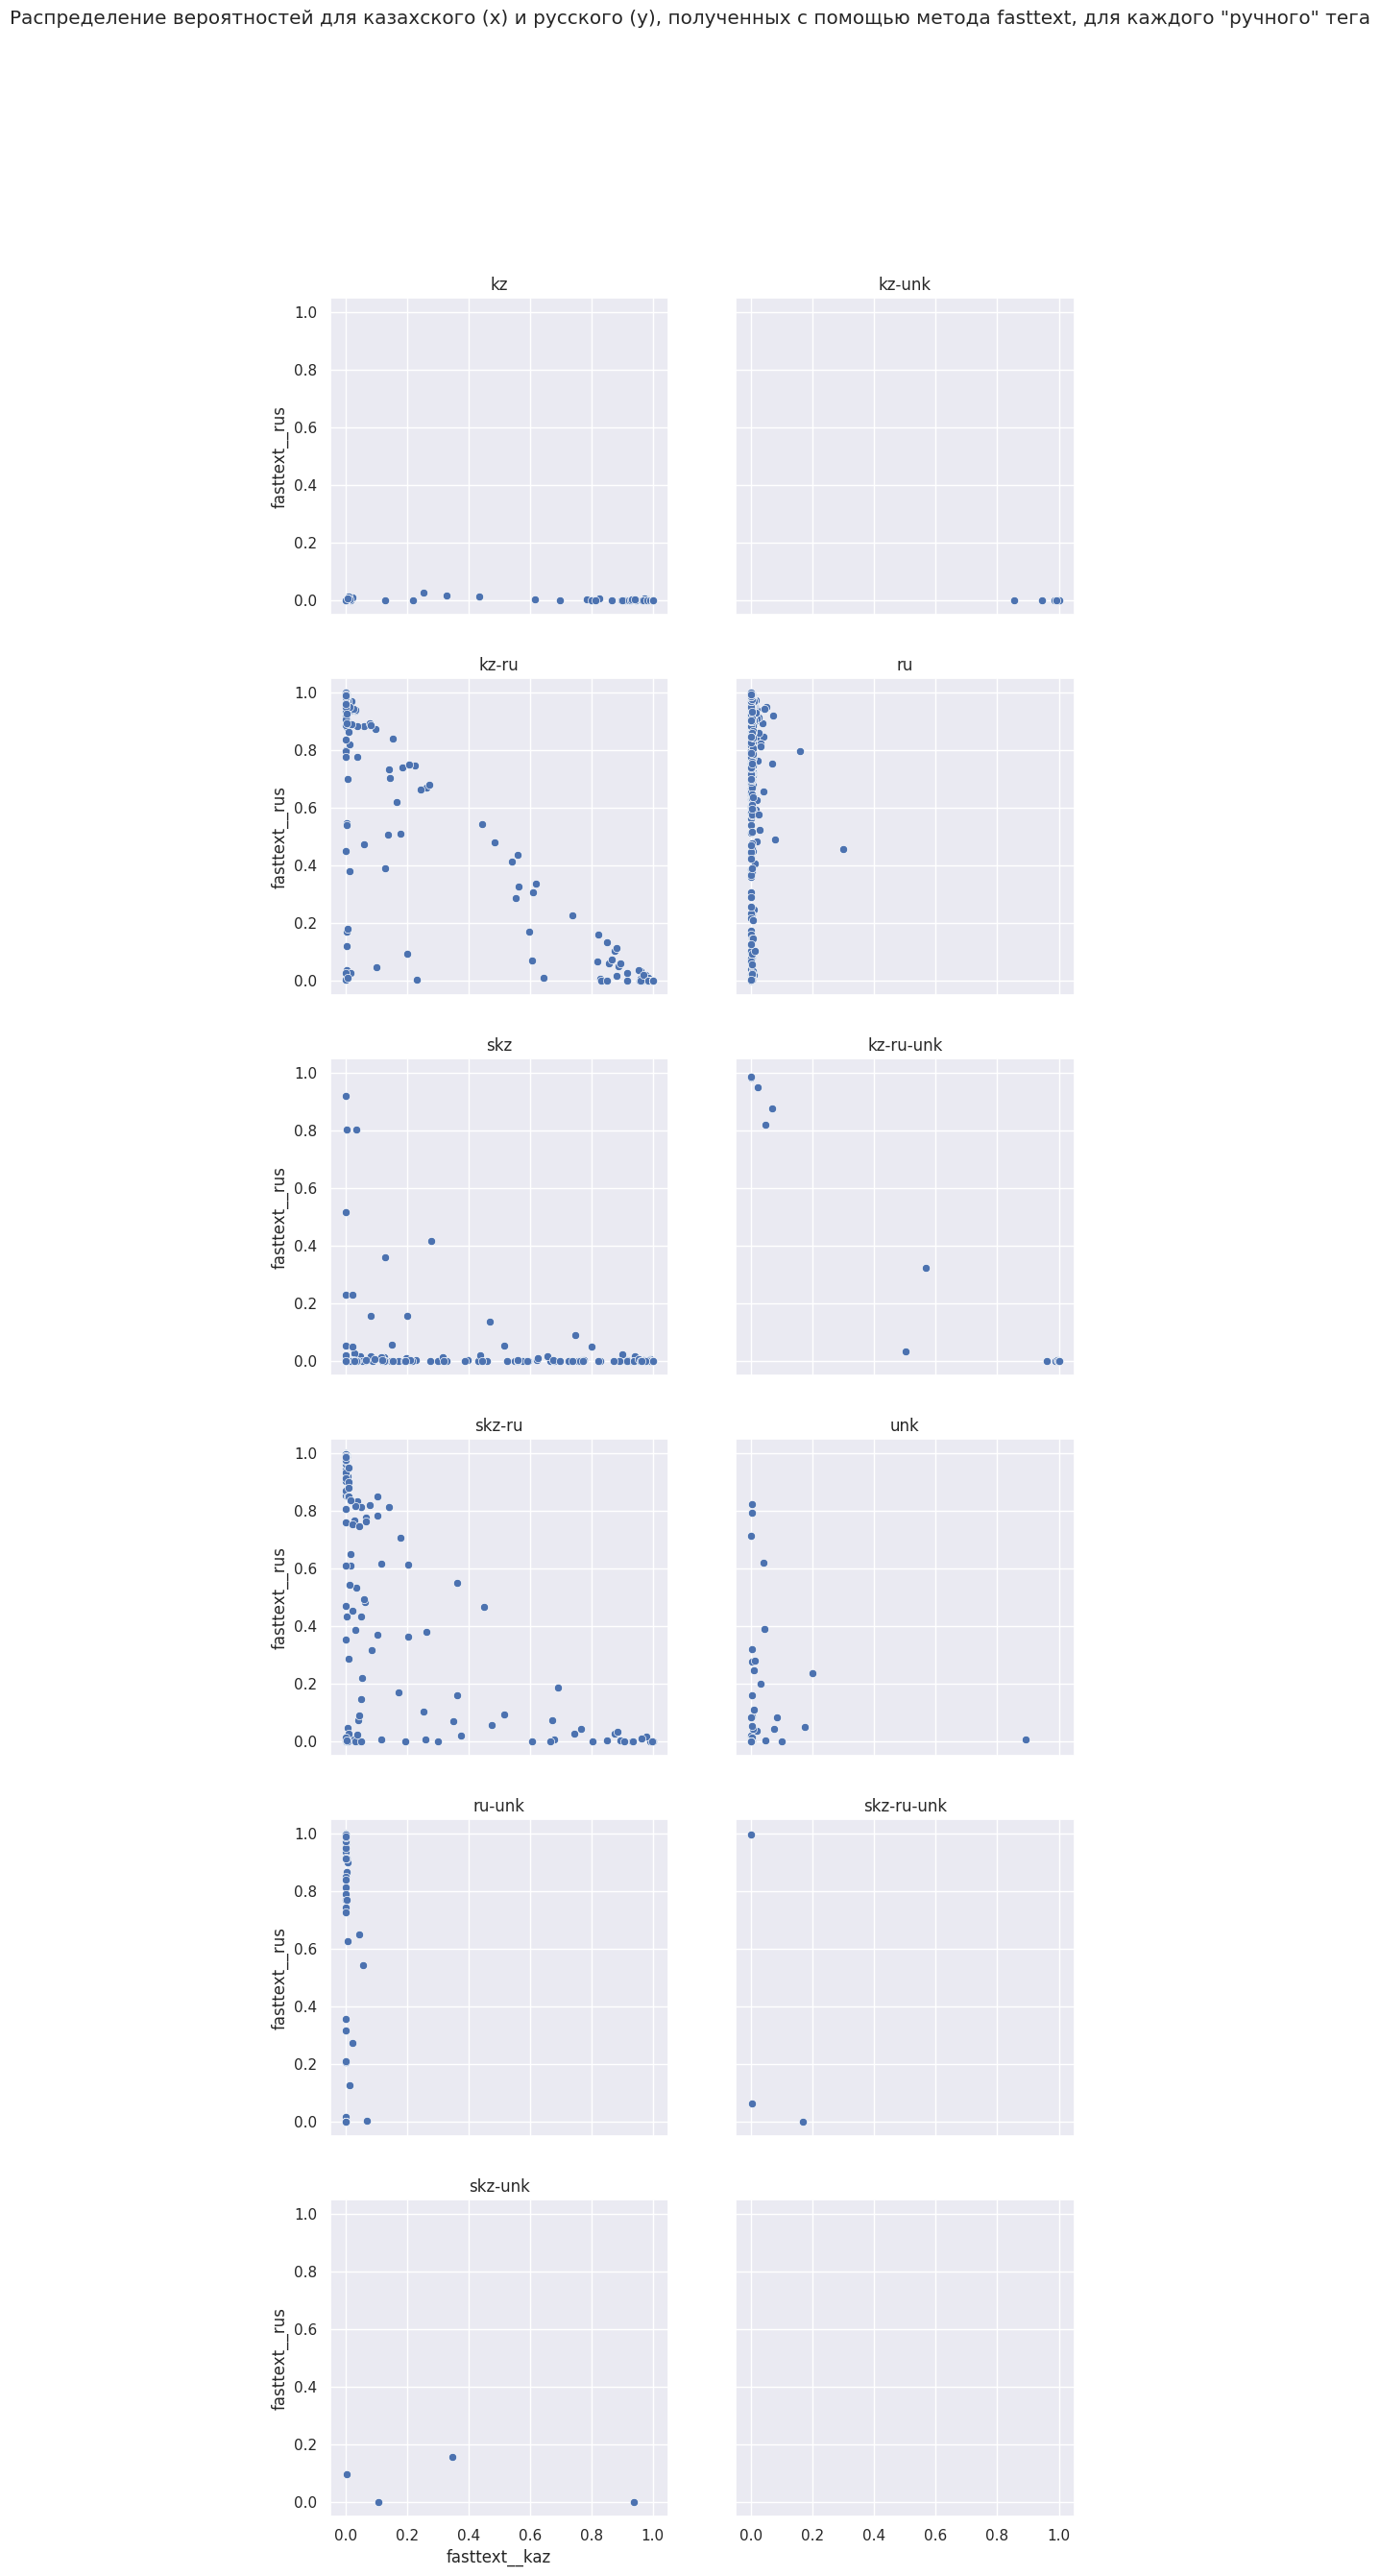

In [203]:
METHOD = 'fasttext'

visualize_tags(exprmnt.df, method=METHOD, manual_col='manual_tag')

#### Q1: Для скольких одноязычных примеров (kz и ru) был правильно определен язык?

In [204]:
# какие теги предсказываются для текстов на казахском
exprmnt.df[(exprmnt.df['manual_tag'].isin(['kz']))][f'{METHOD}__best_lang'].value_counts() / len(exprmnt.df[(exprmnt.df['manual_tag'].isin(['kz']))])

,count
fasttext__best_lang,
kazakh,0.995250
yue_hant,0.001267
ukrainian,0.000950
tatar,0.000317
kyrgyz,0.000317
bashkir,0.000317
chechen,0.000317
kor_hang,0.000317
tajik,0.000317


In [205]:
# какие теги предсказываются для текстов на русском
exprmnt.df[(exprmnt.df['manual_tag'].isin(['ru']))][f'{METHOD}__best_lang'].value_counts() / len(exprmnt.df[(exprmnt.df['manual_tag'].isin(['ru']))])

,count
fasttext__best_lang,
russian,0.987239
ukrainian,0.002219
chechen,0.001110
bulgarian,0.001110
yue_hant,0.000925
chuvash,0.000740
belarusian,0.000740
adyghe,0.000740
bashkir,0.000555


Recall для казахского значительно почти идеальный -- 0.9953 и 0.9872

In [206]:
sample = exprmnt.df[(exprmnt.df['manual_tag'].isin(['kz', 'ru'])) | (exprmnt.df[f'{METHOD}__best_lang'].isin(['kazakh', 'russian']))].copy()
sample['manual_tag'] = sample['manual_tag'].replace({'kz': 'kazakh', 'ru': 'russian'})

print(classification_report(y_true=sample['manual_tag'], y_pred=sample[f'{METHOD}__best_lang'], labels=['kazakh', 'russian']))

              precision    recall  f1-score   support

      kazakh       0.87      1.00      0.93      3158
     russian       0.92      0.99      0.95      5407

   micro avg       0.90      0.99      0.94      8565
   macro avg       0.89      0.99      0.94      8565
weighted avg       0.90      0.99      0.94      8565



In [207]:
# точность
accuracy_score(y_true=sample['manual_tag'], y_pred=sample[f'{METHOD}__best_lang'])

0.8932069510268562

#### Q2: Что предсказывается для kz-ru?

In [208]:
counts_ = exprmnt.df[exprmnt.df['manual_tag'].isin(['kz-ru'])].groupby(['manual_tag', f'{METHOD}__best_lang'])['text'].count()
counts_ = (counts_ / exprmnt.df['manual_tag'].value_counts()).fillna(0)

cm = sns.light_palette("orange", as_cmap=True)

s = pd.DataFrame(counts_).style.background_gradient(cmap=cm)
s

Для csw-текстов предсказывается в основном либо казахский, либо русский -- 52% и 45%.

#### Q3: Как хорошо метод предсказывает одноязычные тексты на нерелевантных языках?

In [209]:
# качество бинарной классификации для определения тега unk
sample = exprmnt.df[exprmnt.df['manual_tag'].isin(['kz', 'ru', 'unk', 'skz'])]
y_true = (sample['manual_tag']=='unk').astype(int)
y_pred = (~sample[f'{METHOD}__best_lang'].isin(['kazakh', 'russian'])).astype(int)

print(classification_report(y_true=y_true, y_pred=y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      8739
           1       0.17      0.86      0.28        43

    accuracy                           0.98      8782
   macro avg       0.58      0.92      0.63      8782
weighted avg       1.00      0.98      0.99      8782



In [210]:
# какие языки предсказываются для unk
sample[(sample['manual_tag']=='unk')].groupby(['manual_tag', f'{METHOD}__best_lang'])['text'].count()

manual_tag  fasttext__best_lang
unk         bulgarian               1
            chuvash                 1
            kazakh                  1
            kyrgyz                 15
            russia buriat           2
            russian                 5
            serbian                 1
            southern altai          1
            tajik                   3
            tatar                   3
            ukrainian              10
Name: text, dtype: int64

In [211]:
# для каких true тегов предсказывается "другой язык"
sample[(~sample[f'{METHOD}__best_lang'].isin(['kazakh', 'russian']))].groupby(['manual_tag', f'{METHOD}__best_lang'])['text'].count()

manual_tag  fasttext__best_lang
kz          bashkir                 1
            chechen                 1
            kor_hang                1
            kyrgyz                  1
            tajik                   1
            tatar                   1
            twi_latn                1
            ukrainian               3
            yue_hant                4
            zho_hans                1
ru          adyghe                  4
            bashkir                 3
            belarusian              4
            bulgarian               6
            chechen                 6
            chuvash                 4
            deu_latn                2
            eng_latn                1
            halh mongolian          2
            karachay-balkar         3
            kor_hang                2
            kyrgyz                  1
            lvs_latn                1
            macedonian              2
            ossetic                 1
            san_deva                1
            serbian                 3
            tatar                   3
            ukrainian              12
            vie_latn                2
            yue_hant                5
            zho_hans                1
skz         chechen                 1
            karachay-balkar         1
            kyrgyz                 87
            ossetic                 1
            southern altai          1
            tatar                   6
            udmurt                  1
            ukrainian               1
            yue_hant                1
unk         bulgarian               1
            chuvash                 1
            kyrgyz                 15
            russia buriat           2
            serbian                 1
            southern altai          1
            tajik                   3
            tatar                   3
            ukrainian              10
Name: text, dtype: int64

Из всех текстов на нерелевантных языках метод выявил всего 86%. 17% из всех текстов, определенных как "нерелевантные" на самом деле содержат казахский или русский.

Для документов на казахском и русском модель редко предсказывала другой язык. Для "упрощенного" казахского предсказывался киргизский

#### Q4: Какие результаты для skz?

In [212]:
# какие языки определены для skz
y_pred = exprmnt.df[(exprmnt.df['manual_tag']=='skz')][f'{METHOD}__best_lang']

y_pred.value_counts() / len(y_pred)

,count
fasttext__best_lang,
kyrgyz,0.500000
kazakh,0.390805
russian,0.034483
tatar,0.034483
ossetic,0.005747
karachay-balkar,0.005747
chechen,0.005747
southern altai,0.005747
ukrainian,0.005747


Для текстов, помеченных тегом skz в половине случаев (50%) предсказывается киргизский, в 39% -- казахский.

#### Q5: Что получим после фильтрации?

In [213]:
y_pred = exprmnt.df[f'{METHOD}__best_lang'].isin(['kazakh', 'russian']).astype(int)

# доля тегов, которые будут выкинуты
counts_ = (exprmnt.df[y_pred==0]['manual_tag'].value_counts() / exprmnt.df['manual_tag'].value_counts()).fillna(0).rename('will_be_excluded, %')

cm = sns.light_palette("green", as_cmap=True)

s = pd.DataFrame(counts_).style.background_gradient(cmap=cm)
s

,"will_be_excluded, %"
manual_tag,
kz,0.004750
kz-ru,0.028626
kz-ru-unk,0.000000
kz-unk,0.000000
ru,0.012761
ru-unk,0.183099
skz,0.574713
skz-ru,0.182796
skz-ru-unk,0.666667


In [214]:
# абсолютные количества тегов, которые будут выкинуты
counts_ = exprmnt.df[y_pred==0]['manual_tag'].value_counts().rename('will_be_excluded')
counts_ = pd.concat([counts_,exprmnt.df['manual_tag'].value_counts().rename('total')], axis=1)
counts_.fillna(0)

,will_be_excluded,total
manual_tag,,
skz,100.0,174
ru,69.0,5407
unk,37.0,43
skz-ru,34.0,186
kz,15.0,3158
kz-ru,15.0,524
ru-unk,13.0,71
skz-unk,3.0,4
skz-ru-unk,2.0,3


Этот способ позволит избавиться от 86% нерелевантных текстов, затронув около 3% примеров с csw.

## Эксперимент 2. Выявление CSW-текстов на основе порога

In [311]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

from sklearn.metrics import classification_report, accuracy_score, precision_recall_curve
from sklearn.metrics import f1_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

from sklearn.metrics import roc_auc_score

import pandas as pd
import numpy as np

In [312]:
# очищаем от нерелевантных тегов
df = df.drop(df[~df['glotlid__best_lang'].isin(['kazakh', 'russian'])].index)
df['manual_tag'].value_counts()

,count
manual_tag,
ru,5357
kz,3142
kz-ru,513
skz-ru,140
kz-unk,112
ru-unk,56
skz,40
kz-ru-unk,16
unk,3


In [313]:
# устанавливаем лейблы для истинных значений
y_true = df['manual_tag'].str.contains('kz-ru')

In [466]:
methods = list(map(lambda x: x.split('__')[0], df.filter(regex='best_lang').columns))
methods.remove('langid') # не участвует в анализе
methods.remove('cld3') # не участвует в анализе
methods

['cld2',
 'lingua',
 'mediapipe',
 'fast_langdetect',
 'glotlid',
 'fasttext',
 'dict']

In [467]:
from sklearn.metrics import precision_score, recall_score, f1_score, fbeta_score

In [468]:
THRESHOLDS = np.arange(0.4, 1.05, 0.05)

def get_best_upper_threshold(method, thresholds):
    """
    Примеры с переключением кодов определяются на основе максимального значения вероятности казахского или русского языка.
    В одноязычных текстах, как правило, язык имеет вес, близкий к 1, а все остальные -- близки к 0.
    Тогда мы можем предположить, что в двуязычных текстах вероятность одного языка растет за счет за счет понижения вероятности для другого языка.
    """
    best_metrics = {
        'method': method,
        'best_threshold': -1,
        'best_f1': -1,
        'best_precision': -1,
        'best_recall': -1,
    }

    for t in thresholds:
        t = round(t, 2)
        y_preds = (df[[f'{method}__kaz', f'{method}__rus']].max(axis=1) < t) & (df[[f'{method}__kaz', f'{method}__rus']].min(axis=1) > 0)
        f1_ = f1_score(y_true, y_preds, average=None)[1]
        recall_ = recall_score(y_true, y_preds)
        precision_ = precision_score(y_true, y_preds, zero_division=0)
        # print(f'THRESHOLD={t}', f'F1={round(f1_, 4)}', f'precision={round(precision_, 4)}', f'recall={round(recall_, 4)}', sep='\t')
        if f1_ > best_metrics['best_f1']:
            best_metrics['best_f1'] = f1_
            best_metrics['best_threshold'] = t
            best_metrics['best_recall'] = recall_
            best_metrics['best_precision'] = precision_

    print(best_metrics)
    print('='*80)
    return best_metrics

stats = []
for m in methods:
    stats.append(get_best_upper_threshold(m, THRESHOLDS))

{'method': 'cld2', 'best_threshold': np.float64(1.0), 'best_f1': np.float64(0.13351877607788595), 'best_precision': 0.9795918367346939, 'best_recall': 0.07164179104477612}
{'method': 'lingua', 'best_threshold': np.float64(0.8), 'best_f1': np.float64(0.15644555694618273), 'best_precision': 0.13469827586206898, 'best_recall': 0.1865671641791045}
{'method': 'mediapipe', 'best_threshold': np.float64(0.95), 'best_f1': np.float64(0.26725775807473084), 'best_precision': 0.23212321232123212, 'best_recall': 0.31492537313432833}
{'method': 'fast_langdetect', 'best_threshold': np.float64(0.95), 'best_f1': np.float64(0.2790981109079829), 'best_precision': 0.23583934088568487, 'best_recall': 0.3417910447761194}
{'method': 'glotlid', 'best_threshold': np.float64(0.95), 'best_f1': np.float64(0.20930232558139536), 'best_precision': 0.2611607142857143, 'best_recall': 0.1746268656716418}
{'method': 'fasttext', 'best_threshold': np.float64(0.95), 'best_f1': np.float64(0.21656976744186046), 'best_precisio

In [469]:
# Лучшие максимальные пороги
pd.DataFrame(stats)

,method,best_threshold,best_f1,best_precision,best_recall
0,cld2,1.00,0.133519,0.979592,0.071642
1,lingua,0.80,0.156446,0.134698,0.186567
2,mediapipe,0.95,0.267258,0.232123,0.314925
3,fast_langdetect,0.95,0.279098,0.235839,0.341791
4,glotlid,0.95,0.209302,0.261161,0.174627
5,fasttext,0.95,0.216570,0.211048,0.222388
6,dict,0.80,0.439024,0.314767,0.725373


In [470]:
THRESHOLDS = np.arange(0, 0.55, 0.05)

def get_best_lower_threshold(method, thresholds):
    """
    В рамках данного подхода решается задача multilabel-классификации: выбираются языки, вероятность которых превышает определенный порог
    """
    best_metrics = {
        'method': method,
        'best_threshold': -1,
        'best_f1': -1,
        'best_precision': -1,
        'best_recall': -1,
    }

    for t in thresholds:
        t = round(t, 2)
        y_preds = (df[f'{method}__kaz'] >= t) & (df[f'{method}__rus'] >= t)
        f1_ = f1_score(y_true, y_preds, average=None)[1]
        recall_ = recall_score(y_true, y_preds)
        precision_ = precision_score(y_true, y_preds, zero_division=0)
        # print(f'THRESHOLD={t}', f'F1={round(f1_, 4)}', f'precision={round(precision_, 4)}', f'recall={round(recall_, 4)}', sep='\t')
        if f1_ > best_metrics['best_f1']:
            best_metrics['best_f1'] = f1_
            best_metrics['best_threshold'] = t
            best_metrics['best_recall'] = recall_
            best_metrics['best_precision'] = precision_

    print(best_metrics)
    print('='*80)
    return best_metrics

stats = []
for m in methods:
    stats.append(get_best_lower_threshold(m, THRESHOLDS))

{'method': 'cld2', 'best_threshold': np.float64(0.0), 'best_f1': np.float64(0.1333068046159968), 'best_precision': 0.07141334470262205, 'best_recall': 1.0}
{'method': 'lingua', 'best_threshold': np.float64(0.05), 'best_f1': np.float64(0.1783840503672613), 'best_precision': 0.3003533568904594, 'best_recall': 0.12686567164179105}
{'method': 'mediapipe', 'best_threshold': np.float64(0.0), 'best_f1': np.float64(0.1341475623185504), 'best_precision': 0.07189612619379762, 'best_recall': 1.0}
{'method': 'fast_langdetect', 'best_threshold': np.float64(0.05), 'best_f1': np.float64(0.2013888888888889), 'best_precision': 0.4484536082474227, 'best_recall': 0.12985074626865672}
{'method': 'glotlid', 'best_threshold': np.float64(0.0), 'best_f1': np.float64(0.1333068046159968), 'best_precision': 0.07141334470262205, 'best_recall': 1.0}
{'method': 'fasttext', 'best_threshold': np.float64(0.05), 'best_f1': np.float64(0.14986376021798364), 'best_precision': 0.859375, 'best_recall': 0.08208955223880597}


In [471]:
# Лучшие минимальные пороги
pd.DataFrame(stats)

,method,best_threshold,best_f1,best_precision,best_recall
0,cld2,0.00,0.133307,0.071413,1.000000
1,lingua,0.05,0.178384,0.300353,0.126866
2,mediapipe,0.00,0.134148,0.071896,1.000000
3,fast_langdetect,0.05,0.201389,0.448454,0.129851
4,glotlid,0.00,0.133307,0.071413,1.000000
5,fasttext,0.05,0.149864,0.859375,0.082090
6,dict,0.10,0.505216,0.504464,0.505970


Ни одна из стратегий не дала надежного результата

In [472]:
sns.set_style("darkgrid", {"axes.facecolor": ".9", 'legend.frameon':True})

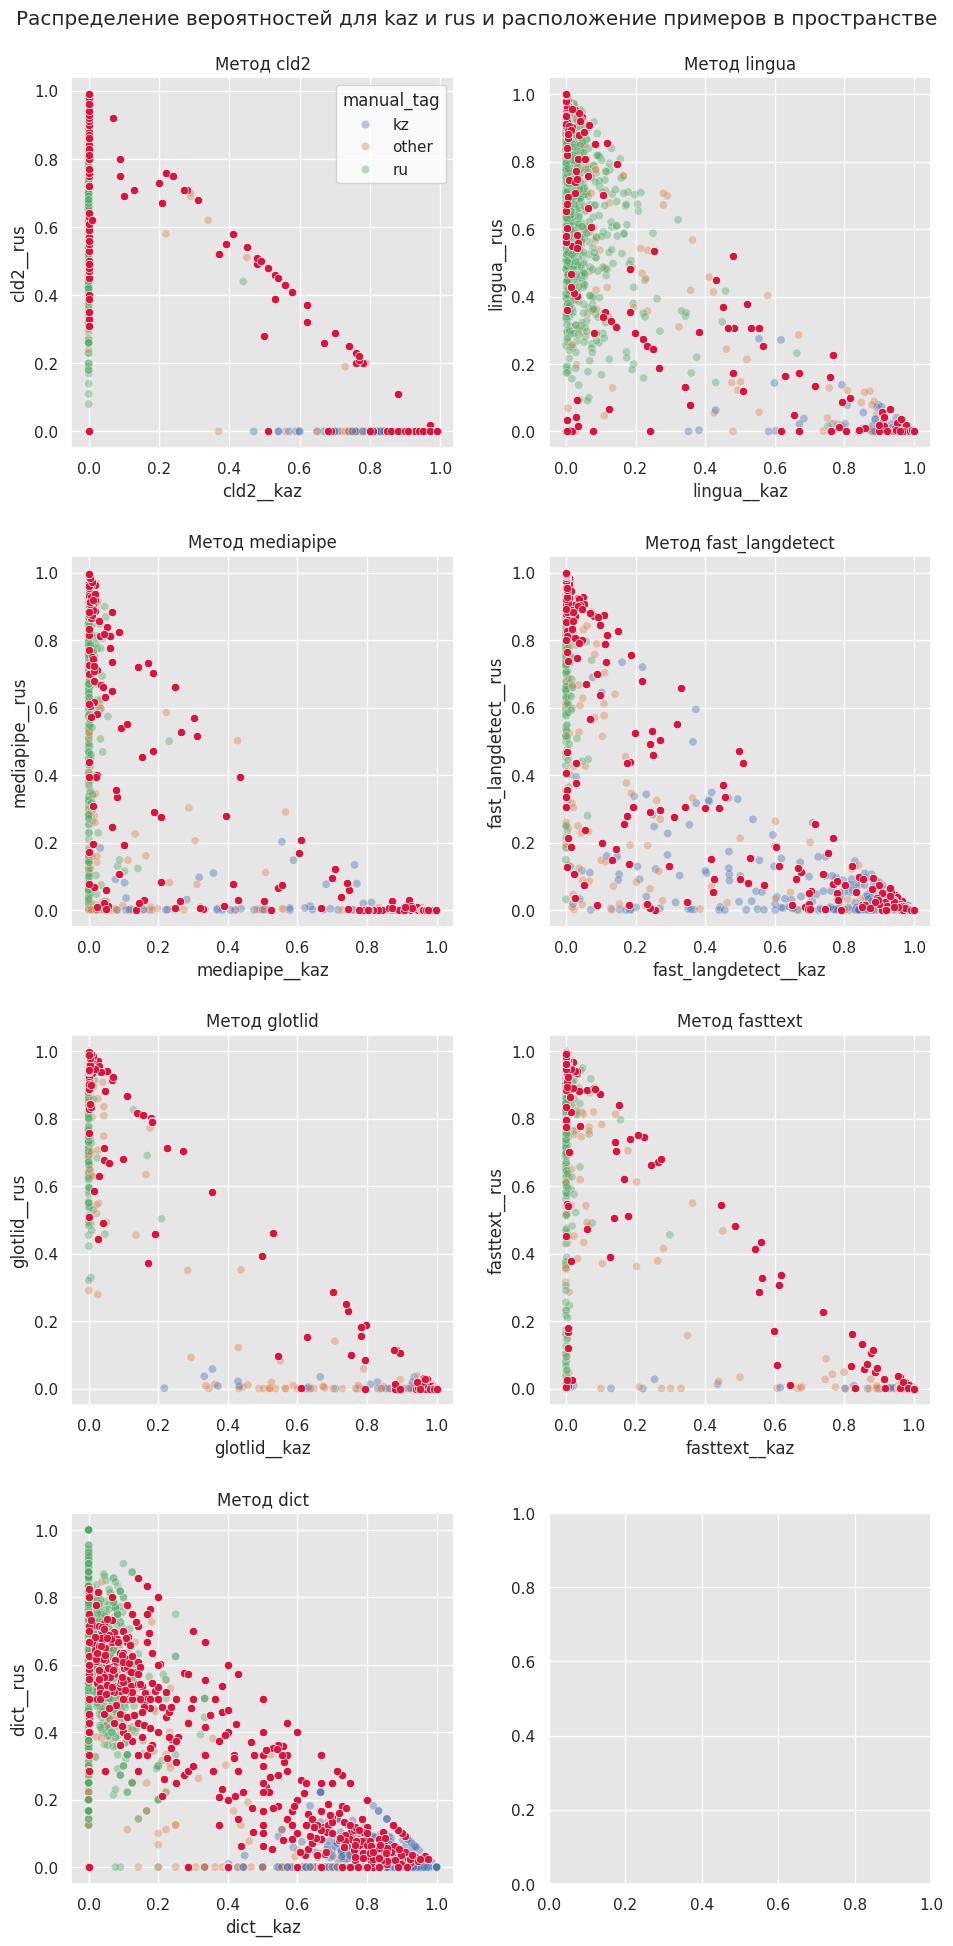

<Figure size 640x480 with 0 Axes>

In [474]:
df['manual_tag_grouped'] = np.where(df['manual_tag'].isin(['kz', 'ru', 'kz-ru']), df['manual_tag'], 'other')

fig, ax = plt.subplots(len(methods)//2+1, 2, figsize=(5*2, 5*4))
ax = ax.flatten()
for i, m in enumerate(methods):
    sns.scatterplot(ax=ax[i], data=df[df['manual_tag']!='kz-ru'], x=f'{m}__kaz', y=f'{m}__rus', hue='manual_tag_grouped', alpha=0.4, legend=False if i>0 else True)
    sns.scatterplot(ax=ax[i], data=df[df['manual_tag']=='kz-ru'], x=f'{m}__kaz', y=f'{m}__rus', c='crimson', alpha=1, legend=False)

    if i==0:
        sns.move_legend(ax[0], title='manual_tag', loc='best', facecolor='white')

    ax[i].set_title(f'Метод {m}')

plt.suptitle('Распределение вероятностей для kaz и rus и расположение примеров в пространстве')
plt.tight_layout(pad=2.0)
plt.show()
plt.savefig('probas')

#### Словарный метод: threshold-based (f1=0.34)

`THRESHOLD=0.0`

In [ ]:
# устанавливаем значения для бинарной классификации
y_pred = dict_comp['dict__multilabel_pred'].str.contains('kz-ru')

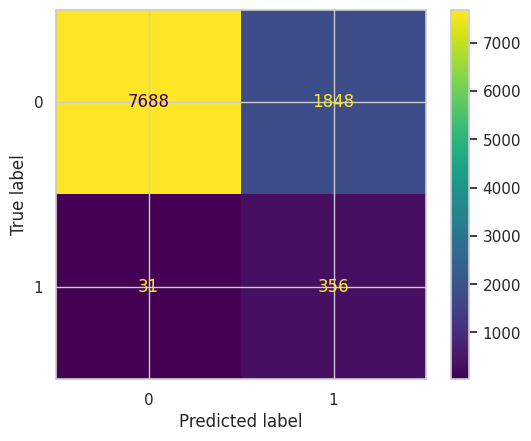

In [ ]:
cm = confusion_matrix(dict_comp['manual_tag_int'], y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, )
disp.plot()
plt.show()

In [ ]:
# classification report для csw текстов
print(classification_report(dict_comp['manual_tag_int'], y_pred))

              precision    recall  f1-score   support

       False       1.00      0.81      0.89      9536
        True       0.16      0.92      0.27       387

    accuracy                           0.81      9923
   macro avg       0.58      0.86      0.58      9923
weighted avg       0.96      0.81      0.87      9923



Очень низкий F1: всего 0.34 за счет низкого precision и высокого recall, то есть высокий TP rate и при этом также высокий FP rate. Это означает, что с помощью этого метода можно определить большинство CSW текстов, но они будут составлять небольшую часть, а все остальные (около 80%) будут тексты без CSW.

Multilabel классификация только для казахского и русского показала средние результаты: метод как бы "недобирает"

#### Словарный метод: DecisionTreeClassifier (f1=0.37)

Accuracy: 95.67%


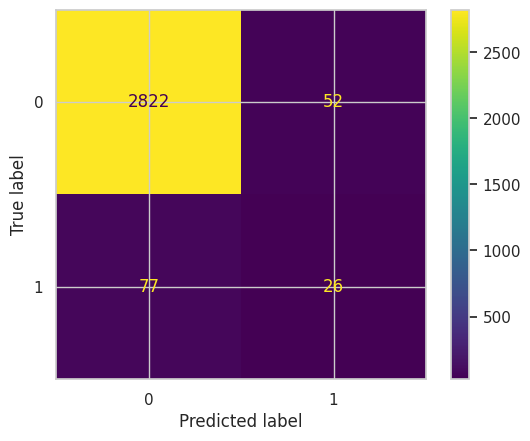

              precision    recall  f1-score   support

       False       0.97      0.98      0.98      2874
        True       0.33      0.25      0.29       103

    accuracy                           0.96      2977
   macro avg       0.65      0.62      0.63      2977
weighted avg       0.95      0.96      0.95      2977



In [ ]:
train_DT(dict_comp[proba_cols], dict_comp['manual_tag_int'])

#### Словарный метод: XGBoostClassifier (f1=0.49)

Accuracy: 89.59%


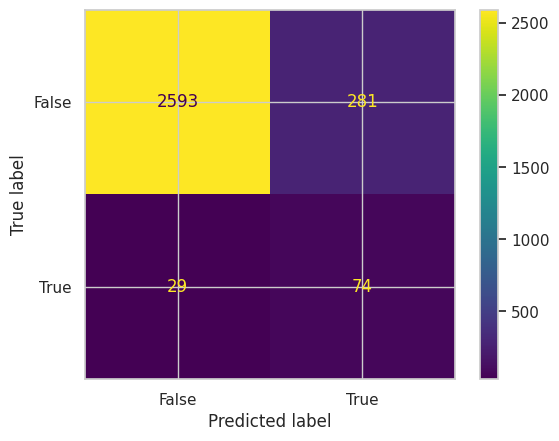

Classification report (w/o threhold tuning):
               precision    recall  f1-score   support

       False       0.99      0.90      0.94      2874
        True       0.21      0.72      0.32       103

    accuracy                           0.90      2977
   macro avg       0.60      0.81      0.63      2977
weighted avg       0.96      0.90      0.92      2977

Optimal threshold: 0.8609827
F1-score: 0.428
Classification report (with threshold tuning):
               precision    recall  f1-score   support

       False       0.98      0.97      0.98      2874
        True       0.39      0.48      0.43       103

    accuracy                           0.96      2977
   macro avg       0.68      0.72      0.70      2977
weighted avg       0.96      0.96      0.96      2977



In [ ]:
train_GB(dict_comp[proba_cols], dict_comp['manual_tag_int'])

#### Словарный метод: SVM (f1=0.46)

Accuracy: 96.93%


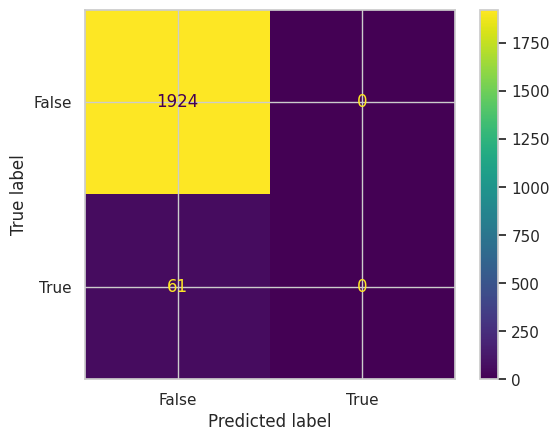

Confusion Matrix (w/o threshold tuning):
               precision    recall  f1-score   support

       False       0.97      1.00      0.98      1924
        True       0.00      0.00      0.00        61

    accuracy                           0.97      1985
   macro avg       0.48      0.50      0.49      1985
weighted avg       0.94      0.97      0.95      1985

Optimal threshold: 0.04421506821465897
F1-score: 0.463
Confusion Matrix (with threshold tuning):
               precision    recall  f1-score   support

       False       0.99      0.97      0.98      1924
        True       0.40      0.56      0.46        61

    accuracy                           0.96      1985
   macro avg       0.69      0.77      0.72      1985
weighted avg       0.97      0.96      0.96      1985



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
train_SVM(dict_comp[proba_cols], dict_comp['manual_tag_int'])

### Fasttext

In [ ]:
df.filter(regex='fasttext')

,fasttext__best_lang,fasttext__kaz,fasttext__eng,fasttext__rus
0,__label__kaz_Cyrl,1.00001,0.00001,0.00001
1,__label__kaz_Cyrl,1.00001,0.00001,0.00001
2,__label__kaz_Cyrl,1.00001,0.00001,0.00001
3,__label__kaz_Cyrl,1.00001,0.00001,0.00001
4,__label__kaz_Cyrl,1.00001,0.00001,0.00001
...,...,...,...,...
9918,__label__kaz_Cyrl,1.00001,0.00001,0.00001
9919,__label__kaz_Cyrl,1.00001,0.00001,0.00001
9920,__label__kaz_Cyrl,1.00001,0.00001,0.00001
9921,__label__kir_Cyrl,0.02259,0.00001,0.00002


In [ ]:
proba_cols = ['fasttext__rus', 'fasttext__kaz', 'fasttext__eng']
cols = main_cols + proba_cols
cols

['id',
 'comment_tokens',
 'comment_words',
 'manual_tag',
 'manual_tag_int',
 'fasttext__rus',
 'fasttext__kaz',
 'fasttext__eng']

In [ ]:
fasttext_comp = df[cols]
fasttext_comp.head()

,id,comment_tokens,comment_words,manual_tag,manual_tag_int,fasttext__rus,fasttext__kaz,fasttext__eng
0,62,"['сандж', 'тәуелсіз', 'зерттеу', 'орталығының'...",сандж тәуелсіз зерттеу орталығының хабарлауынш...,kz,False,0.00001,1.00001,0.00001
1,63,"['заңгер', 'алексей', 'сонның', 'консультацияс...",заңгер алексей сонның консультациясына мына сі...,kz,False,0.00001,1.00001,0.00001
2,71,"['шымкентте', 'елуге', 'жуық', 'әйел', 'әкімді...",шымкентте елуге жуық әйел әкімдік алдына жинал...,kz,False,0.00001,1.00001,0.00001
3,73,"['өте', 'маңызды', 'жобаға', 'сұхбат', 'кейіпк...",өте маңызды жобаға сұхбат кейіпкері ретінде кі...,kz,False,0.00001,1.00001,0.00001
4,82,"['айсұлтанның', 'құпиясы', 'британиялық', 'fin...",айсұлтанның құпиясы британиялық financial time...,kz,False,0.00001,1.00001,0.00001


In [ ]:
# fasttext_comp['fasttext_other'] = 1 - fasttext_comp[['fasttext__rus', 'fasttext__kaz', 'fasttext__eng']].sum(axis=1)
# proba_cols += ['fasttext_other']

#### FastText: threshold-based (f1=0.41)

In [ ]:
THRESHOLD = 0.0008

predictions = np.where((fasttext_comp['fasttext__kaz']>=THRESHOLD) & (fasttext_comp['fasttext__rus']>=THRESHOLD), 1, 0)

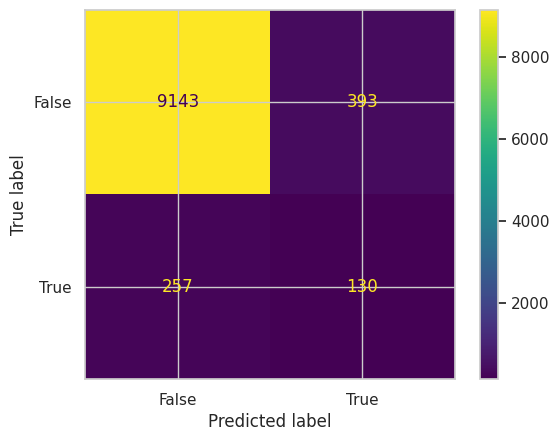

In [ ]:
cm = confusion_matrix(fasttext_comp['manual_tag_int'], predictions)

# Assuming 'cm' from the previous example
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fasttext_comp['manual_tag_int'].unique())
disp.plot()
plt.show()

In [ ]:
# print(classification_report(y_encoded, y_pred, target_names=le.classes_))
print("Confusion Matrix:\n", classification_report(fasttext_comp['manual_tag_int'], predictions))

Confusion Matrix:
               precision    recall  f1-score   support

       False       0.97      0.96      0.97      9536
        True       0.25      0.34      0.29       387

    accuracy                           0.93      9923
   macro avg       0.61      0.65      0.63      9923
weighted avg       0.94      0.93      0.94      9923



#### FastText: DecisionTreeClassifier (f1=0.31)

Accuracy: 95.30%


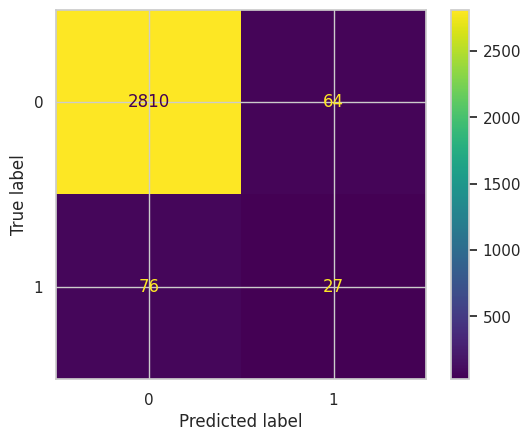

              precision    recall  f1-score   support

       False       0.97      0.98      0.98      2874
        True       0.30      0.26      0.28       103

    accuracy                           0.95      2977
   macro avg       0.64      0.62      0.63      2977
weighted avg       0.95      0.95      0.95      2977



In [ ]:
train_DT(fasttext_comp[proba_cols], fasttext_comp['manual_tag_int'])

#### FastText: XBoostClassifier (f1=0.42)

Accuracy: 88.48%


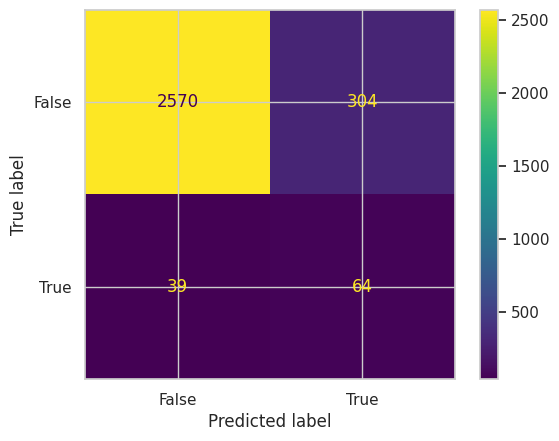

Classification report (w/o threhold tuning):
               precision    recall  f1-score   support

       False       0.99      0.89      0.94      2874
        True       0.17      0.62      0.27       103

    accuracy                           0.88      2977
   macro avg       0.58      0.76      0.60      2977
weighted avg       0.96      0.88      0.91      2977

Optimal threshold: 0.88515645
F1-score: 0.387
Classification report (with threshold tuning):
               precision    recall  f1-score   support

       False       0.98      0.99      0.98      2874
        True       0.45      0.34      0.39       103

    accuracy                           0.96      2977
   macro avg       0.71      0.66      0.68      2977
weighted avg       0.96      0.96      0.96      2977



/tmp/ipykernel_65109/2475705217.py:31: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * precisions * recalls / (precisions + recalls)


In [ ]:
train_GB(fasttext_comp[proba_cols], fasttext_comp['manual_tag_int'])

#### FasttextL SVM (f1=46)

Accuracy: 96.83%


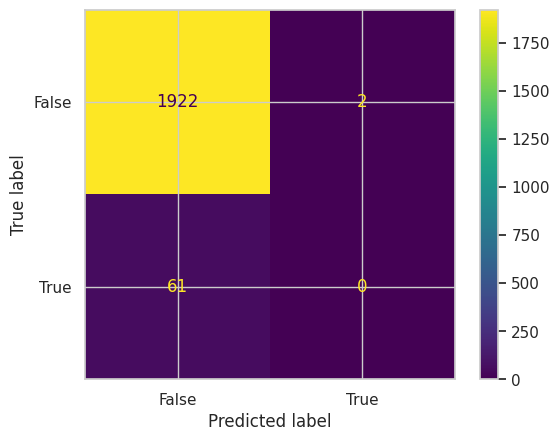

Confusion Matrix (w/o threshold tuning):
               precision    recall  f1-score   support

       False       0.97      1.00      0.98      1924
        True       0.00      0.00      0.00        61

    accuracy                           0.97      1985
   macro avg       0.48      0.50      0.49      1985
weighted avg       0.94      0.97      0.95      1985

Optimal threshold: 0.9939542935592566
F1-score: 0.000
Confusion Matrix (with threshold tuning):
               precision    recall  f1-score   support

       False       0.97      1.00      0.98      1924
        True       0.00      0.00      0.00        61

    accuracy                           0.97      1985
   macro avg       0.48      0.50      0.49      1985
weighted avg       0.94      0.97      0.95      1985



/tmp/ipykernel_65109/1023690739.py:34: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * precisions * recalls / (precisions + recalls)


In [ ]:
train_SVM(fasttext_comp[proba_cols], fasttext_comp['manual_tag_int'])

### GlotLID

In [ ]:
df.filter(regex='glotlid')

,glotlid__best_lang,glotlid__kaz,glotlid__rus,glotlid__eng
0,__label__kaz_Cyrl,0.999968,0.000000,0.0
1,__label__kaz_Cyrl,0.999988,0.000000,0.0
2,__label__kaz_Cyrl,1.000010,0.000000,0.0
3,__label__kaz_Cyrl,1.000009,0.000000,0.0
4,__label__kaz_Cyrl,0.999971,0.000000,0.0
...,...,...,...,...
9918,__label__kaz_Cyrl,1.000004,0.000000,0.0
9919,__label__kaz_Cyrl,1.000009,0.000000,0.0
9920,__label__kaz_Cyrl,1.000010,0.000000,0.0
9921,__label__kir_Cyrl,0.000473,0.000011,0.0


In [ ]:
proba_cols = ['glotlid__rus', 'glotlid__kaz', 'glotlid__eng']
cols = main_cols + proba_cols
cols

['id',
 'comment_tokens',
 'comment_words',
 'manual_tag',
 'manual_tag_int',
 'glotlid__rus',
 'glotlid__kaz',
 'glotlid__eng']

In [ ]:
glotlid_comp = df[cols]
glotlid_comp.head()

,id,comment_tokens,comment_words,manual_tag,manual_tag_int,glotlid__rus,glotlid__kaz,glotlid__eng
0,62,"['сандж', 'тәуелсіз', 'зерттеу', 'орталығының'...",сандж тәуелсіз зерттеу орталығының хабарлауынш...,kz,False,0.0,0.999968,0.0
1,63,"['заңгер', 'алексей', 'сонның', 'консультацияс...",заңгер алексей сонның консультациясына мына сі...,kz,False,0.0,0.999988,0.0
2,71,"['шымкентте', 'елуге', 'жуық', 'әйел', 'әкімді...",шымкентте елуге жуық әйел әкімдік алдына жинал...,kz,False,0.0,1.000010,0.0
3,73,"['өте', 'маңызды', 'жобаға', 'сұхбат', 'кейіпк...",өте маңызды жобаға сұхбат кейіпкері ретінде кі...,kz,False,0.0,1.000009,0.0
4,82,"['айсұлтанның', 'құпиясы', 'британиялық', 'fin...",айсұлтанның құпиясы британиялық financial time...,kz,False,0.0,0.999971,0.0


In [ ]:
# с этим параметром f1 снижается
# glotlid_comp['glotlid_other'] = 1 - glotlid_comp[proba_cols].sum(axis=1)
# proba_cols += ['glotlid_other']

#### GlotLID: threshold-based (f1=0.45)


In [ ]:
THRESHOLD = 0.00008

predictions = np.where((glotlid_comp['glotlid__kaz']>=THRESHOLD) & (glotlid_comp['glotlid__rus']>=THRESHOLD), 1, 0)

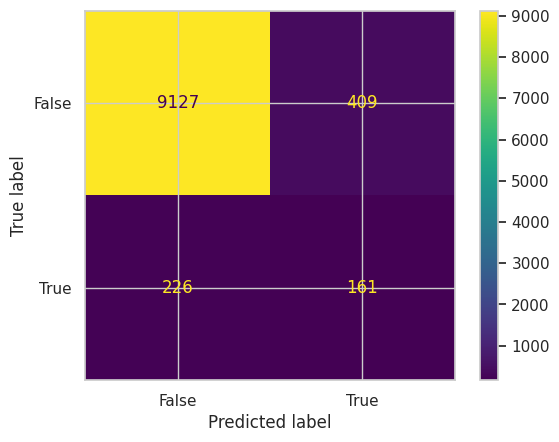

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(glotlid_comp['manual_tag_int'], predictions)

# Assuming 'cm' from the previous example
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=glotlid_comp['manual_tag_int'].unique())
disp.plot()
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
# print(classification_report(y_encoded, y_pred, target_names=le.classes_))
print("Confusion Matrix:\n", classification_report(glotlid_comp['manual_tag_int'], predictions))

Confusion Matrix:
               precision    recall  f1-score   support

       False       0.98      0.96      0.97      9536
        True       0.28      0.42      0.34       387

    accuracy                           0.94      9923
   macro avg       0.63      0.69      0.65      9923
weighted avg       0.95      0.94      0.94      9923



#### GlotLID: DecisionTreeClassifier (f1=0.34)

Accuracy: 94.83%


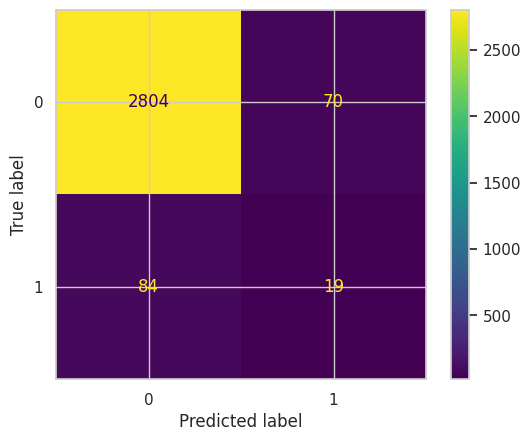

              precision    recall  f1-score   support

       False       0.97      0.98      0.97      2874
        True       0.21      0.18      0.20       103

    accuracy                           0.95      2977
   macro avg       0.59      0.58      0.59      2977
weighted avg       0.94      0.95      0.95      2977



In [ ]:
train_DT(glotlid_comp[proba_cols], glotlid_comp['manual_tag_int'])

#### GlotLID: XBoostClassifier (f1=0.45)


Accuracy: 85.52%


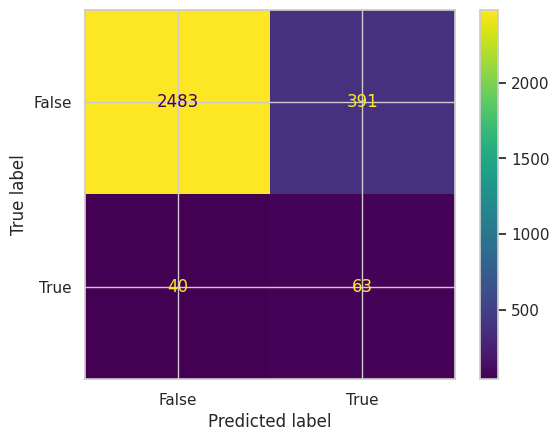

Classification report (w/o threhold tuning):
               precision    recall  f1-score   support

       False       0.98      0.86      0.92      2874
        True       0.14      0.61      0.23       103

    accuracy                           0.86      2977
   macro avg       0.56      0.74      0.57      2977
weighted avg       0.95      0.86      0.90      2977

Optimal threshold: 0.75368565
F1-score: 0.381
Classification report (with threshold tuning):
               precision    recall  f1-score   support

       False       0.98      0.96      0.97      2874
        True       0.30      0.51      0.38       103

    accuracy                           0.94      2977
   macro avg       0.64      0.74      0.68      2977
weighted avg       0.96      0.94      0.95      2977



In [ ]:
train_GB(glotlid_comp[proba_cols], glotlid_comp['manual_tag_int'])

#### GlotLID: SVM (f1=0.47)

Accuracy: 97.08%


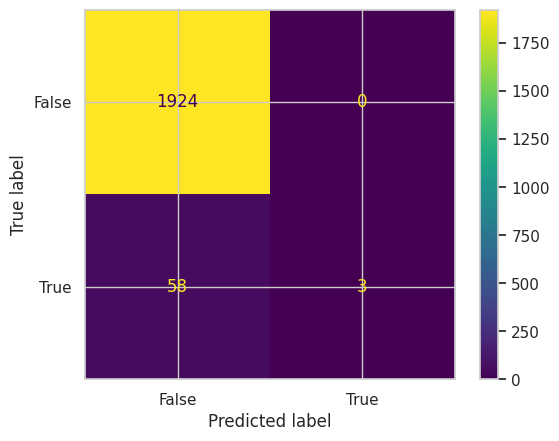

Confusion Matrix (w/o threshold tuning):
               precision    recall  f1-score   support

       False       0.97      1.00      0.99      1924
        True       1.00      0.05      0.09        61

    accuracy                           0.97      1985
   macro avg       0.99      0.52      0.54      1985
weighted avg       0.97      0.97      0.96      1985

Optimal threshold: 0.03866712725321609
F1-score: 0.395
Confusion Matrix (with threshold tuning):
               precision    recall  f1-score   support

       False       0.98      0.96      0.97      1924
        True       0.32      0.52      0.40        61

    accuracy                           0.95      1985
   macro avg       0.65      0.74      0.68      1985
weighted avg       0.96      0.95      0.96      1985



In [ ]:
train_SVM(glotlid_comp[proba_cols], glotlid_comp['manual_tag_int'])

### Fast Langdetect

In [ ]:
df.filter(regex='fast_langdetect')

,fast_langdetect__best_lang,fast_langdetect__kaz,fast_langdetect__rus,fast_langdetect__eng
0,kk,0.999085,0.000027,0.00001
1,kk,0.977664,0.007639,0.00001
2,kk,0.999845,0.000099,0.00001
3,kk,1.000000,0.000000,0.00001
4,kk,0.998483,0.000015,0.00002
...,...,...,...,...
9918,kk,0.999765,0.000194,0.00000
9919,kk,0.999918,0.000015,0.00000
9920,kk,0.994691,0.002007,0.00000
9921,ky,0.002103,0.014162,0.00000


In [ ]:
proba_cols = ['fast_langdetect__rus', 'fast_langdetect__kaz', 'fast_langdetect__eng']
cols = main_cols + proba_cols
cols

['id',
 'comment_tokens',
 'comment_words',
 'manual_tag',
 'manual_tag_int',
 'fast_langdetect__rus',
 'fast_langdetect__kaz',
 'fast_langdetect__eng']

In [ ]:
fastdetect_comp = df[cols]
fastdetect_comp

,id,comment_tokens,comment_words,manual_tag,manual_tag_int,fast_langdetect__rus,fast_langdetect__kaz,fast_langdetect__eng
0,62,"['сандж', 'тәуелсіз', 'зерттеу', 'орталығының'...",сандж тәуелсіз зерттеу орталығының хабарлауынш...,kz,False,0.000027,0.999085,0.00001
1,63,"['заңгер', 'алексей', 'сонның', 'консультацияс...",заңгер алексей сонның консультациясына мына сі...,kz,False,0.007639,0.977664,0.00001
2,71,"['шымкентте', 'елуге', 'жуық', 'әйел', 'әкімді...",шымкентте елуге жуық әйел әкімдік алдына жинал...,kz,False,0.000099,0.999845,0.00001
3,73,"['өте', 'маңызды', 'жобаға', 'сұхбат', 'кейіпк...",өте маңызды жобаға сұхбат кейіпкері ретінде кі...,kz,False,0.000000,1.000000,0.00001
4,82,"['айсұлтанның', 'құпиясы', 'британиялық', 'fin...",айсұлтанның құпиясы британиялық financial time...,kz,False,0.000015,0.998483,0.00002
...,...,...,...,...,...,...,...,...
9918,0,"['дінді', 'керек', 'қылмасаң', 'сенің', 'шашың...",дінді керек қылмасаң сенің шашың сияқты жабайы...,kz-ru,True,0.000194,0.999765,0.00000
9919,0,"['қарапайым', 'адамдар', 'мен', 'ғалымдар', 'а...",қарапайым адамдар мен ғалымдар арасында діндар...,kz,False,0.000015,0.999918,0.00000
9920,0,"['керемет', 'өтте', 'дұрыс', 'аитасын', 'бізді...",керемет өтте дұрыс аитасын біздің сауатсыз үкі...,kz,False,0.002007,0.994691,0.00000
9921,0,"['батыстын', 'адтлетсиз', 'куреси', 'тек', 'ис...",батыстын адтлетсиз куреси тек исламнын пайгамб...,skz,False,0.014162,0.002103,0.00000


In [ ]:
# fastdetect_comp['fast_langdetect_other'] = 1 - fastdetect_comp[['fast_langdetect__rus', 'fast_langdetect__kaz', 'fast_langdetect__eng']].sum(axis=1)
# proba_cols += ['fast_langdetect_other']

#### fast langdetect: threshold-based (f1=0.26)

In [ ]:
THRESHOLD = 0.0002

predictions = np.where((fastdetect_comp['fast_langdetect__kaz']>=THRESHOLD) & (fastdetect_comp['fast_langdetect__rus']>=THRESHOLD), 1, 0)

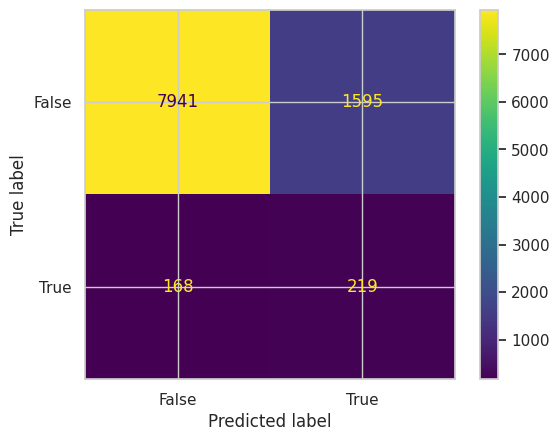

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(fastdetect_comp['manual_tag_int'], predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fastdetect_comp['manual_tag_int'].unique())
disp.plot()
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print("Confusion Matrix:\n", classification_report(fastdetect_comp['manual_tag_int'], predictions))

Confusion Matrix:
               precision    recall  f1-score   support

       False       0.98      0.83      0.90      9536
        True       0.12      0.57      0.20       387

    accuracy                           0.82      9923
   macro avg       0.55      0.70      0.55      9923
weighted avg       0.95      0.82      0.87      9923



#### FastDetect: DecisionTreeClassifier (f1=0.17)

Accuracy: 93.42%


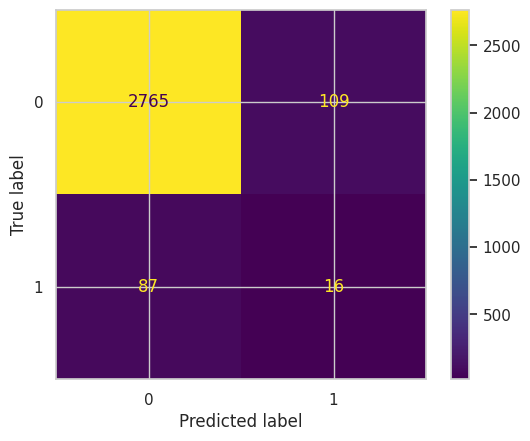

              precision    recall  f1-score   support

       False       0.97      0.96      0.97      2874
        True       0.13      0.16      0.14       103

    accuracy                           0.93      2977
   macro avg       0.55      0.56      0.55      2977
weighted avg       0.94      0.93      0.94      2977



In [ ]:
train_DT(fastdetect_comp[proba_cols], fastdetect_comp['manual_tag_int'])

#### FastDetect: XBoostClassifier (f1=0.31)

Accuracy: 85.96%


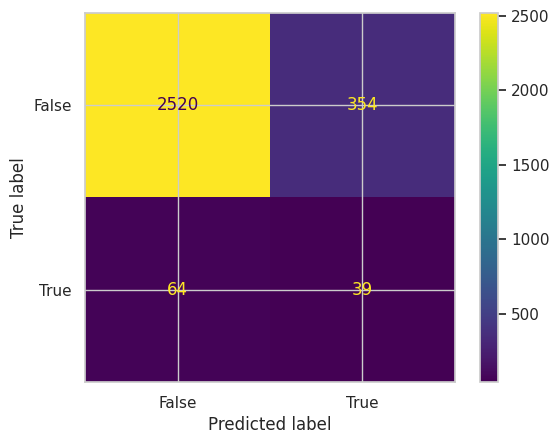

Classification report (w/o threhold tuning):
               precision    recall  f1-score   support

       False       0.98      0.88      0.92      2874
        True       0.10      0.38      0.16       103

    accuracy                           0.86      2977
   macro avg       0.54      0.63      0.54      2977
weighted avg       0.94      0.86      0.90      2977

Optimal threshold: 0.8359299
F1-score: 0.257
Classification report (with threshold tuning):
               precision    recall  f1-score   support

       False       0.97      0.98      0.98      2874
        True       0.32      0.21      0.26       103

    accuracy                           0.96      2977
   macro avg       0.65      0.60      0.62      2977
weighted avg       0.95      0.96      0.95      2977



In [ ]:
train_GB(fastdetect_comp[proba_cols], fastdetect_comp['manual_tag_int'])

#### FastDetect: SVM (f1=0.34)

Accuracy: 96.93%


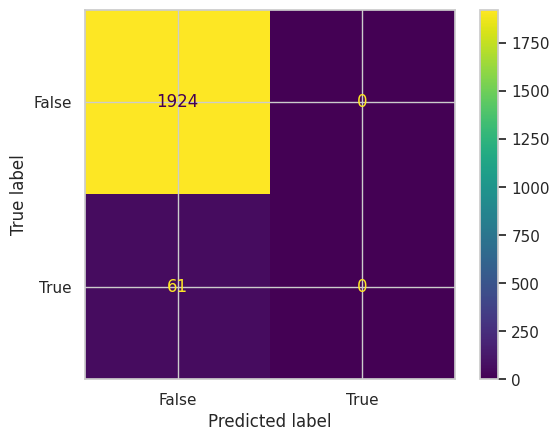

Confusion Matrix (w/o threshold tuning):
               precision    recall  f1-score   support

       False       0.97      1.00      0.98      1924
        True       0.00      0.00      0.00        61

    accuracy                           0.97      1985
   macro avg       0.48      0.50      0.49      1985
weighted avg       0.94      0.97      0.95      1985

Optimal threshold: 0.04619024401782575
F1-score: 0.304
Confusion Matrix (with threshold tuning):
               precision    recall  f1-score   support

       False       0.98      0.99      0.98      1924
        True       0.45      0.23      0.30        61

    accuracy                           0.97      1985
   macro avg       0.71      0.61      0.64      1985
weighted avg       0.96      0.97      0.96      1985



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
train_SVM(fastdetect_comp[proba_cols], fastdetect_comp['manual_tag_int'])

### Lingua

In [ ]:
df.filter(regex='lingua')

,lingua__best_lang,lingua__kaz,lingua__eng,lingua__rus,lingua__all_langs
0,KAZAKH,1.0,0.0,0.000000e+00,kz
1,KAZAKH,1.0,0.0,0.000000e+00,kz-ru
2,KAZAKH,1.0,0.0,0.000000e+00,kz
3,KAZAKH,1.0,0.0,0.000000e+00,kz
4,KAZAKH,1.0,0.0,0.000000e+00,kz-ru
...,...,...,...,...,...
9918,KAZAKH,1.0,0.0,0.000000e+00,kz
9919,KAZAKH,1.0,0.0,0.000000e+00,kz
9920,KAZAKH,1.0,0.0,0.000000e+00,kz
9921,KAZAKH,1.0,0.0,3.918711e-60,kz-unk


In [ ]:
proba_cols = ['lingua__rus', 'lingua__kaz', 'lingua__eng']
cols = main_cols + proba_cols
cols

['id',
 'comment_tokens',
 'comment_words',
 'manual_tag',
 'manual_tag_int',
 'lingua__rus',
 'lingua__kaz',
 'lingua__eng']

In [ ]:
lingua_comp = df[cols]
lingua_comp

,id,comment_tokens,comment_words,manual_tag,manual_tag_int,lingua__rus,lingua__kaz,lingua__eng
0,62,"['сандж', 'тәуелсіз', 'зерттеу', 'орталығының'...",сандж тәуелсіз зерттеу орталығының хабарлауынш...,kz,False,0.000000e+00,1.0,0.0
1,63,"['заңгер', 'алексей', 'сонның', 'консультацияс...",заңгер алексей сонның консультациясына мына сі...,kz,False,0.000000e+00,1.0,0.0
2,71,"['шымкентте', 'елуге', 'жуық', 'әйел', 'әкімді...",шымкентте елуге жуық әйел әкімдік алдына жинал...,kz,False,0.000000e+00,1.0,0.0
3,73,"['өте', 'маңызды', 'жобаға', 'сұхбат', 'кейіпк...",өте маңызды жобаға сұхбат кейіпкері ретінде кі...,kz,False,0.000000e+00,1.0,0.0
4,82,"['айсұлтанның', 'құпиясы', 'британиялық', 'fin...",айсұлтанның құпиясы британиялық financial time...,kz,False,0.000000e+00,1.0,0.0
...,...,...,...,...,...,...,...,...
9918,0,"['дінді', 'керек', 'қылмасаң', 'сенің', 'шашың...",дінді керек қылмасаң сенің шашың сияқты жабайы...,kz-ru,True,0.000000e+00,1.0,0.0
9919,0,"['қарапайым', 'адамдар', 'мен', 'ғалымдар', 'а...",қарапайым адамдар мен ғалымдар арасында діндар...,kz,False,0.000000e+00,1.0,0.0
9920,0,"['керемет', 'өтте', 'дұрыс', 'аитасын', 'бізді...",керемет өтте дұрыс аитасын біздің сауатсыз үкі...,kz,False,0.000000e+00,1.0,0.0
9921,0,"['батыстын', 'адтлетсиз', 'куреси', 'тек', 'ис...",батыстын адтлетсиз куреси тек исламнын пайгамб...,skz,False,3.918711e-60,1.0,0.0


In [ ]:
# lingua_comp['lingua_other'] = 1 - lingua_comp[['lingua__rus', 'lingua__kaz', 'lingua__eng']].sum(axis=1)
# proba_cols += ['lingua_other']

#### Lingua: threshold-based (f1=0.22)

In [ ]:
THRESHOLD = 0.05

predictions = np.where((lingua_comp['lingua__kaz']>=THRESHOLD) & (lingua_comp['lingua__rus']>=THRESHOLD), 1, 0)

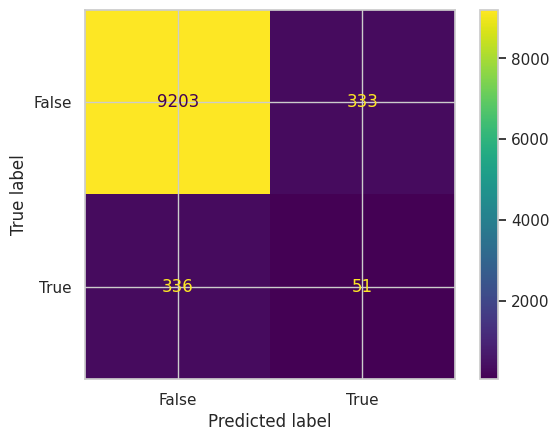

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(lingua_comp['manual_tag_int'], predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lingua_comp['manual_tag_int'].unique())
disp.plot()
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
# print(classification_report(y_encoded, y_pred, target_names=le.classes_))
print("Confusion Matrix:\n", classification_report(lingua_comp['manual_tag_int'], predictions))

Confusion Matrix:
               precision    recall  f1-score   support

       False       0.96      0.97      0.96      9536
        True       0.13      0.13      0.13       387

    accuracy                           0.93      9923
   macro avg       0.55      0.55      0.55      9923
weighted avg       0.93      0.93      0.93      9923



In [ ]:
lingua__multilabel_pred = df['lingua__all_langs'].str.contains('kz-ru').astype(int)
print("Confusion Matrix:\n", classification_report(lingua_comp['manual_tag_int'], lingua__multilabel_pred))

Confusion Matrix:
               precision    recall  f1-score   support

       False       0.98      0.95      0.96      9536
        True       0.28      0.46      0.35       387

    accuracy                           0.93      9923
   macro avg       0.63      0.71      0.66      9923
weighted avg       0.95      0.93      0.94      9923



#### Lingua: DecisionTreeClassifier (f1=0.11)

Accuracy: 93.95%


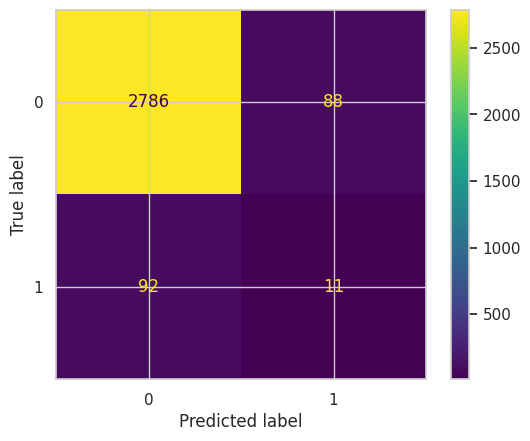

              precision    recall  f1-score   support

       False       0.97      0.97      0.97      2874
        True       0.11      0.11      0.11       103

    accuracy                           0.94      2977
   macro avg       0.54      0.54      0.54      2977
weighted avg       0.94      0.94      0.94      2977



In [ ]:
train_DT(lingua_comp[proba_cols], lingua_comp['manual_tag_int'])

#### Lingua: XBoostClassifier (f1=0.25)


Accuracy: 76.32%


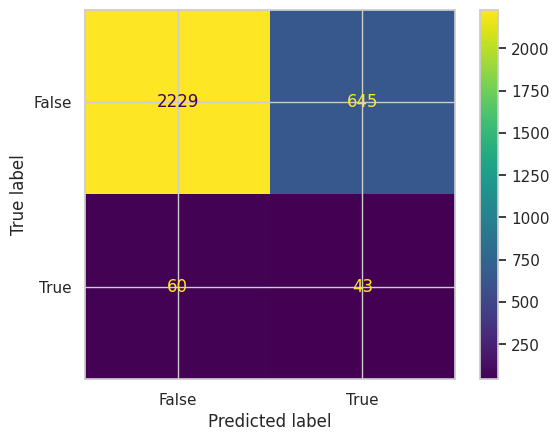

Classification report (w/o threhold tuning):
               precision    recall  f1-score   support

       False       0.97      0.78      0.86      2874
        True       0.06      0.42      0.11       103

    accuracy                           0.76      2977
   macro avg       0.52      0.60      0.49      2977
weighted avg       0.94      0.76      0.84      2977

Optimal threshold: 0.81126904
F1-score: 0.213
Classification report (with threshold tuning):
               precision    recall  f1-score   support

       False       0.97      0.98      0.98      2874
        True       0.25      0.18      0.21       103

    accuracy                           0.95      2977
   macro avg       0.61      0.58      0.59      2977
weighted avg       0.95      0.95      0.95      2977



/tmp/ipykernel_65109/2475705217.py:31: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * precisions * recalls / (precisions + recalls)


In [ ]:
train_GB(lingua_comp[proba_cols], lingua_comp['manual_tag_int'])

#### Lingua: SVM (f1=0.26)


Accuracy: 96.93%


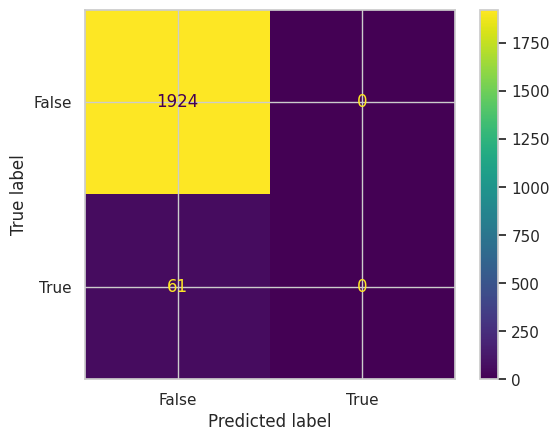

Confusion Matrix (w/o threshold tuning):
               precision    recall  f1-score   support

       False       0.97      1.00      0.98      1924
        True       0.00      0.00      0.00        61

    accuracy                           0.97      1985
   macro avg       0.48      0.50      0.49      1985
weighted avg       0.94      0.97      0.95      1985

Optimal threshold: 0.04653860959425859
F1-score: 0.000
Confusion Matrix (with threshold tuning):
               precision    recall  f1-score   support

       False       0.97      0.99      0.98      1924
        True       0.00      0.00      0.00        61

    accuracy                           0.96      1985
   macro avg       0.48      0.50      0.49      1985
weighted avg       0.94      0.96      0.95      1985



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/tmp/ipykernel_65109/1023690739.py:34: RuntimeWar

In [ ]:
train_SVM(lingua_comp[proba_cols], lingua_comp['manual_tag_int'])

### cld2

In [ ]:
df.filter(regex='cld2')

,cld2__all_langs,cld2__best_lang,cld2__kaz,cld2__rus,cld2__eng
0,kz,kz,0.99,0.0,0.0
1,kz,kz,0.99,0.0,0.0
2,kz,kz,0.99,0.0,0.0
3,kz,kz,0.99,0.0,0.0
4,kz,kz,0.98,0.0,0.0
...,...,...,...,...,...
9918,kz,kz,0.99,0.0,0.0
9919,kz,kz,0.99,0.0,0.0
9920,kz,kz,0.99,0.0,0.0
9921,unk,un,0.00,0.0,0.0


In [ ]:
METHOD = 'cld2'
proba_cols = ['cld2__rus', 'cld2__kaz', 'cld2__eng']
cols = main_cols + proba_cols
cols

['id',
 'comment_tokens',
 'comment_words',
 'manual_tag',
 'manual_tag_int',
 'cld2__rus',
 'cld2__kaz',
 'cld2__eng']

In [ ]:
cld2_comp = df[cols]
cld2_comp

,id,comment_tokens,comment_words,manual_tag,manual_tag_int,cld2__rus,cld2__kaz,cld2__eng
0,62,"['сандж', 'тәуелсіз', 'зерттеу', 'орталығының'...",сандж тәуелсіз зерттеу орталығының хабарлауынш...,kz,False,0.0,0.99,0.0
1,63,"['заңгер', 'алексей', 'сонның', 'консультацияс...",заңгер алексей сонның консультациясына мына сі...,kz,False,0.0,0.99,0.0
2,71,"['шымкентте', 'елуге', 'жуық', 'әйел', 'әкімді...",шымкентте елуге жуық әйел әкімдік алдына жинал...,kz,False,0.0,0.99,0.0
3,73,"['өте', 'маңызды', 'жобаға', 'сұхбат', 'кейіпк...",өте маңызды жобаға сұхбат кейіпкері ретінде кі...,kz,False,0.0,0.99,0.0
4,82,"['айсұлтанның', 'құпиясы', 'британиялық', 'fin...",айсұлтанның құпиясы британиялық financial time...,kz,False,0.0,0.98,0.0
...,...,...,...,...,...,...,...,...
9918,0,"['дінді', 'керек', 'қылмасаң', 'сенің', 'шашың...",дінді керек қылмасаң сенің шашың сияқты жабайы...,kz-ru,True,0.0,0.99,0.0
9919,0,"['қарапайым', 'адамдар', 'мен', 'ғалымдар', 'а...",қарапайым адамдар мен ғалымдар арасында діндар...,kz,False,0.0,0.99,0.0
9920,0,"['керемет', 'өтте', 'дұрыс', 'аитасын', 'бізді...",керемет өтте дұрыс аитасын біздің сауатсыз үкі...,kz,False,0.0,0.99,0.0
9921,0,"['батыстын', 'адтлетсиз', 'куреси', 'тек', 'ис...",батыстын адтлетсиз куреси тек исламнын пайгамб...,skz,False,0.0,0.00,0.0


In [ ]:
# lingua_comp['lingua_other'] = 1 - lingua_comp[['lingua__rus', 'lingua__kaz', 'lingua__eng']].sum(axis=1)
# proba_cols += ['lingua_other']

#### cld2: threshold-based (f1=0.16)

In [ ]:
# cld2_comp['manual_tag_int'] = cld2_comp['manual_tag'].str.contains('kz-ru').astype(int)

/tmp/ipykernel_777/3676530486.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cld2_comp['manual_tag_int'] = cld2_comp['manual_tag'].str.contains('kz-ru').astype(int)


In [ ]:
THRESHOLD = 0.0002

predictions = np.where((cld2_comp[f'{METHOD}__kaz']>=THRESHOLD) & (cld2_comp[f'{METHOD}__rus']>=THRESHOLD), 1, 0)
# predictions = (cld2_comp[[f'{METHOD}__kaz', f'{METHOD}__rus']].max(axis=1)<0.99).astype(int)

In [ ]:
# cld2_comp[(cld2_comp[f'{METHOD}__kaz']>=THRESHOLD) & (cld2_comp[f'{METHOD}__rus']>=THRESHOLD)]['manual_tag'].value_counts()

In [ ]:
# cld2_comp['max_proba'] = cld2_comp[[f'{METHOD}__kaz', f'{METHOD}__rus']].max(axis=1)

# cld2_comp.groupby('manual_tag_int')['max_proba'].describe()

In [ ]:
# cld2_comp.groupby('manual_tag_int')['max_proba'].plot.kde()

In [ ]:
# df[df['manual_tag']=='ru']['cld2__kaz'].describe()

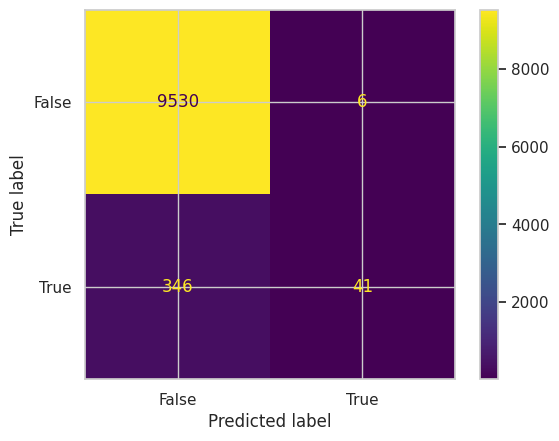

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(cld2_comp['manual_tag_int'], predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cld2_comp['manual_tag_int'].unique())
disp.plot()
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
# print(classification_report(y_encoded, y_pred, target_names=le.classes_))
print("Confusion Matrix:\n", classification_report(cld2_comp['manual_tag_int'], predictions))

Confusion Matrix:
               precision    recall  f1-score   support

       False       0.96      1.00      0.98      9536
        True       0.87      0.11      0.19       387

    accuracy                           0.96      9923
   macro avg       0.92      0.55      0.59      9923
weighted avg       0.96      0.96      0.95      9923



In [ ]:
cld2__multilabel_pred = df['cld2__all_langs'].str.contains('kz-ru').astype(int)
print("Confusion Matrix:\n", classification_report(cld2_comp['manual_tag_int'], cld2__multilabel_pred))

Confusion Matrix:
               precision    recall  f1-score   support

       False       0.95      1.00      0.97      9378
        True       0.98      0.08      0.16       545

    accuracy                           0.95      9923
   macro avg       0.96      0.54      0.56      9923
weighted avg       0.95      0.95      0.93      9923



#### cld2: DecisionTreeClassifier (f1=0.14)

Accuracy: 96.81%


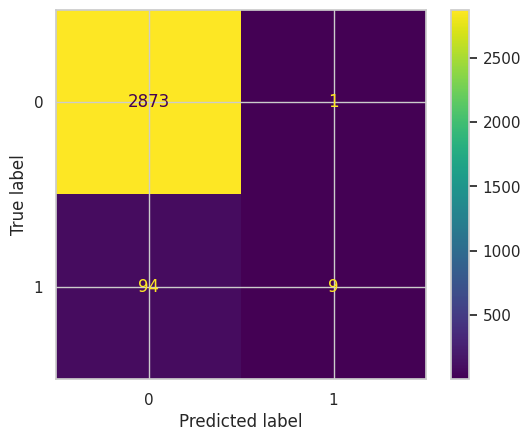

              precision    recall  f1-score   support

       False       0.97      1.00      0.98      2874
        True       0.90      0.09      0.16       103

    accuracy                           0.97      2977
   macro avg       0.93      0.54      0.57      2977
weighted avg       0.97      0.97      0.96      2977



In [ ]:
train_DT(cld2_comp[proba_cols], cld2_comp['manual_tag_int'])

#### cld2: XBoostClassifier (f1=0.16)


Accuracy: 86.36%


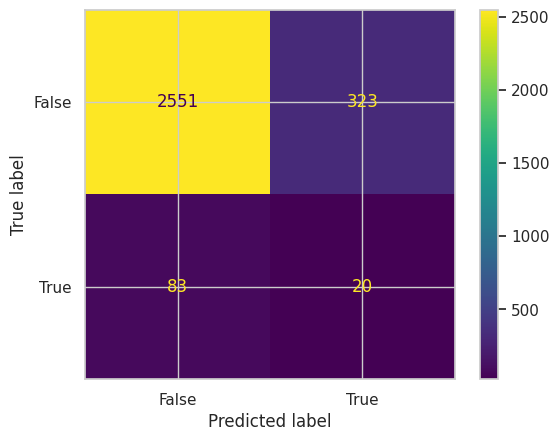

Classification report (w/o threhold tuning):
               precision    recall  f1-score   support

       False       0.97      0.89      0.93      2874
        True       0.06      0.19      0.09       103

    accuracy                           0.86      2977
   macro avg       0.51      0.54      0.51      2977
weighted avg       0.94      0.86      0.90      2977

Optimal threshold: 0.95923907
F1-score: 0.159
Classification report (with threshold tuning):
               precision    recall  f1-score   support

       False       0.97      1.00      0.98      2874
        True       0.90      0.09      0.16       103

    accuracy                           0.97      2977
   macro avg       0.93      0.54      0.57      2977
weighted avg       0.97      0.97      0.96      2977



In [ ]:
train_GB(cld2_comp[proba_cols], cld2_comp['manual_tag_int'])

#### cld2: SVM (f1=0.15)


Accuracy: 97.18%


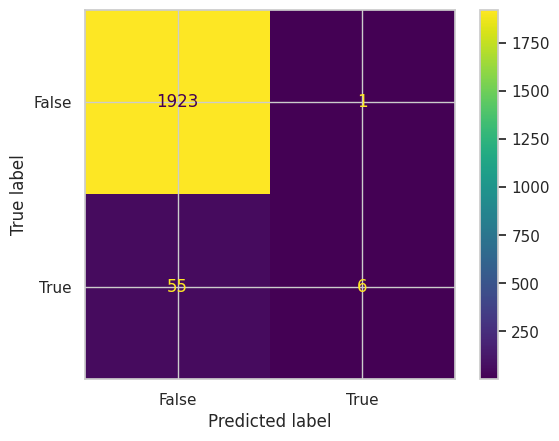

Confusion Matrix (w/o threshold tuning):
               precision    recall  f1-score   support

       False       0.97      1.00      0.99      1924
        True       0.86      0.10      0.18        61

    accuracy                           0.97      1985
   macro avg       0.91      0.55      0.58      1985
weighted avg       0.97      0.97      0.96      1985

Optimal threshold: 0.04857163464821998
F1-score: 0.176
Confusion Matrix (with threshold tuning):
               precision    recall  f1-score   support

       False       0.97      1.00      0.99      1924
        True       0.86      0.10      0.18        61

    accuracy                           0.97      1985
   macro avg       0.91      0.55      0.58      1985
weighted avg       0.97      0.97      0.96      1985



In [ ]:
train_SVM(cld2_comp[proba_cols], cld2_comp['manual_tag_int'])

### cld3

In [ ]:
df.filter(regex='cld3')

,cld3__best_lang,cld3__kaz,cld3__eng,cld3__ru-latn,cld3__rus
0,kk,0.999996,0.00000,0.0,0.0
1,kk,0.999802,0.00000,0.0,0.0
2,kk,0.999981,0.00000,0.0,0.0
3,kk,0.999996,0.00000,0.0,0.0
4,kk,0.999997,0.51944,0.0,0.0
...,...,...,...,...,...
9918,kk,0.999909,0.00000,0.0,0.0
9919,kk,1.000000,0.00000,0.0,0.0
9920,kk,0.999998,0.00000,0.0,0.0
9921,ky,0.000000,0.00000,0.0,0.0


In [ ]:
METHOD = 'cld3'
proba_cols = ['cld3__rus', 'cld3__kaz', 'cld3__eng']
cols = main_cols + proba_cols
cols

['id',
 'comment_tokens',
 'comment_words',
 'manual_tag',
 'manual_tag_int',
 'cld3__rus',
 'cld3__kaz',
 'cld3__eng']

In [ ]:
cld3_comp = df[cols]
cld3_comp

,id,comment_tokens,comment_words,manual_tag,manual_tag_int,cld3__rus,cld3__kaz,cld3__eng
0,62,"['сандж', 'тәуелсіз', 'зерттеу', 'орталығының'...",сандж тәуелсіз зерттеу орталығының хабарлауынш...,kz,False,0.0,0.999996,0.00000
1,63,"['заңгер', 'алексей', 'сонның', 'консультацияс...",заңгер алексей сонның консультациясына мына сі...,kz,False,0.0,0.999802,0.00000
2,71,"['шымкентте', 'елуге', 'жуық', 'әйел', 'әкімді...",шымкентте елуге жуық әйел әкімдік алдына жинал...,kz,False,0.0,0.999981,0.00000
3,73,"['өте', 'маңызды', 'жобаға', 'сұхбат', 'кейіпк...",өте маңызды жобаға сұхбат кейіпкері ретінде кі...,kz,False,0.0,0.999996,0.00000
4,82,"['айсұлтанның', 'құпиясы', 'британиялық', 'fin...",айсұлтанның құпиясы британиялық financial time...,kz,False,0.0,0.999997,0.51944
...,...,...,...,...,...,...,...,...
9918,0,"['дінді', 'керек', 'қылмасаң', 'сенің', 'шашың...",дінді керек қылмасаң сенің шашың сияқты жабайы...,kz-ru,True,0.0,0.999909,0.00000
9919,0,"['қарапайым', 'адамдар', 'мен', 'ғалымдар', 'а...",қарапайым адамдар мен ғалымдар арасында діндар...,kz,False,0.0,1.000000,0.00000
9920,0,"['керемет', 'өтте', 'дұрыс', 'аитасын', 'бізді...",керемет өтте дұрыс аитасын біздің сауатсыз үкі...,kz,False,0.0,0.999998,0.00000
9921,0,"['батыстын', 'адтлетсиз', 'куреси', 'тек', 'ис...",батыстын адтлетсиз куреси тек исламнын пайгамб...,skz,False,0.0,0.000000,0.00000


In [ ]:
# lingua_comp['lingua_other'] = 1 - lingua_comp[['lingua__rus', 'lingua__kaz', 'lingua__eng']].sum(axis=1)
# proba_cols += ['lingua_other']

#### cld3: threshold-based (f1=0.20)

In [ ]:
# cld2_comp['manual_tag_int'] = cld2_comp['manual_tag'].str.contains('kz-ru').astype(int)

/tmp/ipykernel_777/3676530486.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cld2_comp['manual_tag_int'] = cld2_comp['manual_tag'].str.contains('kz-ru').astype(int)


In [ ]:
# THRESHOLD = 0.0001
THRESHOLD = 0.99

# predictions = np.where((cld3_comp[f'{METHOD}__kaz']>=THRESHOLD) & (cld3_comp[f'{METHOD}__rus']>=THRESHOLD), 1, 0)
predictions = (cld3_comp[[f'{METHOD}__kaz', f'{METHOD}__rus']].max(axis=1)<THRESHOLD).astype(int)

In [ ]:
# cld3_comp[(cld3_comp[f'{METHOD}__kaz']>=THRESHOLD) & (cld3_comp[f'{METHOD}__rus']>=THRESHOLD)]['manual_tag'].value_counts()

In [ ]:
# cld3_comp['max_proba'] = cld3_comp[[f'{METHOD}__kaz', f'{METHOD}__rus']].max(axis=1)

# cld3_comp.groupby('manual_tag_int')['max_proba'].describe()

In [ ]:
# cld3_comp.groupby('manual_tag_int')['max_proba'].plot.kde()

In [ ]:
# df[df['manual_tag']=='ru']['cld2__kaz'].describe()

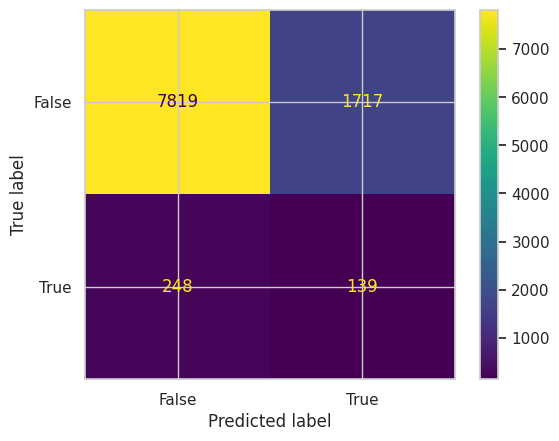

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(cld3_comp['manual_tag_int'], predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cld3_comp['manual_tag_int'].unique())
disp.plot()
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
# print(classification_report(y_encoded, y_pred, target_names=le.classes_))
print("Confusion Matrix:\n", classification_report(cld3_comp['manual_tag_int'], predictions))

Confusion Matrix:
               precision    recall  f1-score   support

       False       0.97      0.82      0.89      9536
        True       0.07      0.36      0.12       387

    accuracy                           0.80      9923
   macro avg       0.52      0.59      0.51      9923
weighted avg       0.93      0.80      0.86      9923



#### cld3: DecisionTreeClassifier (f1=0.06)

Accuracy: 94.32%


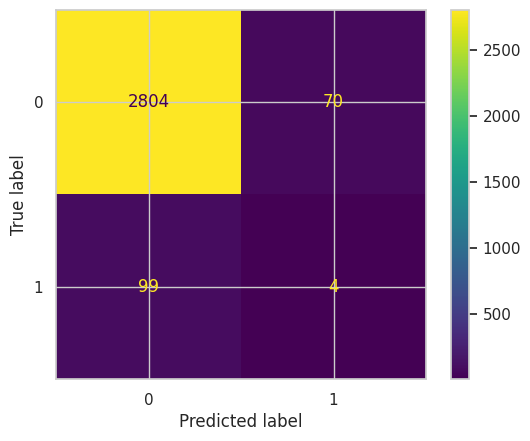

              precision    recall  f1-score   support

       False       0.97      0.98      0.97      2874
        True       0.05      0.04      0.05       103

    accuracy                           0.94      2977
   macro avg       0.51      0.51      0.51      2977
weighted avg       0.93      0.94      0.94      2977



In [ ]:
train_DT(cld3_comp[proba_cols], cld3_comp['manual_tag_int'])

#### cld3: XBoostClassifier (f1=0.20)


Accuracy: 61.00%


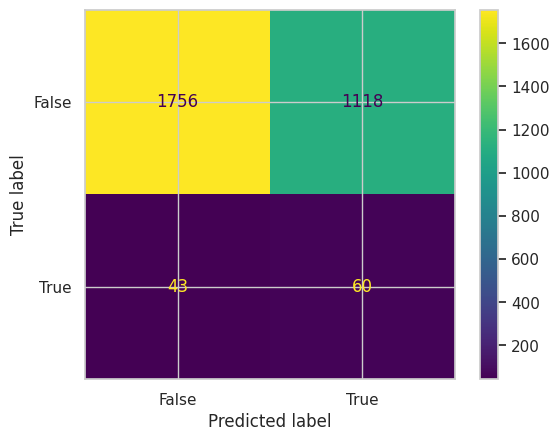

Classification report (w/o threhold tuning):
               precision    recall  f1-score   support

       False       0.98      0.61      0.75      2874
        True       0.05      0.58      0.09       103

    accuracy                           0.61      2977
   macro avg       0.51      0.60      0.42      2977
weighted avg       0.94      0.61      0.73      2977

Optimal threshold: 0.77097046
F1-score: 0.134
Classification report (with threshold tuning):
               precision    recall  f1-score   support

       False       0.97      0.97      0.97      2874
        True       0.13      0.14      0.13       103

    accuracy                           0.94      2977
   macro avg       0.55      0.55      0.55      2977
weighted avg       0.94      0.94      0.94      2977



/tmp/ipykernel_65109/2475705217.py:31: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * precisions * recalls / (precisions + recalls)


In [ ]:
train_GB(cld3_comp[proba_cols], cld3_comp['manual_tag_int'])

#### cld3: SVM (f1=0.0)


Accuracy: 96.93%


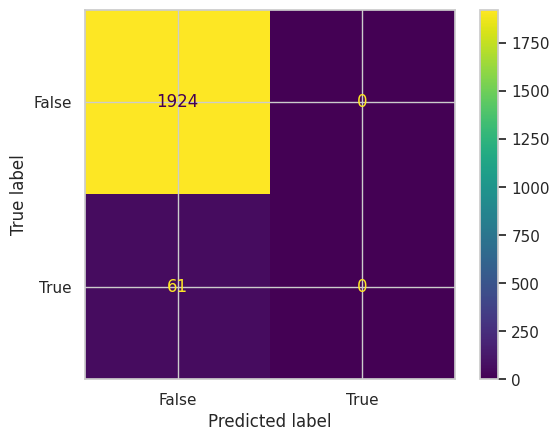

Confusion Matrix (w/o threshold tuning):
               precision    recall  f1-score   support

       False       0.97      1.00      0.98      1924
        True       0.00      0.00      0.00        61

    accuracy                           0.97      1985
   macro avg       0.48      0.50      0.49      1985
weighted avg       0.94      0.97      0.95      1985

Optimal threshold: 0.04704812514562546
F1-score: 0.000
Confusion Matrix (with threshold tuning):
               precision    recall  f1-score   support

       False       0.97      0.99      0.98      1924
        True       0.00      0.00      0.00        61

    accuracy                           0.96      1985
   macro avg       0.48      0.50      0.49      1985
weighted avg       0.94      0.96      0.95      1985



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/tmp/ipykernel_65109/1023690739.py:34: RuntimeWar

In [ ]:
train_SVM(cld3_comp[proba_cols], cld3_comp['manual_tag_int'])

### Mediapipe

In [ ]:
df.filter(regex='mediapipe')

,mediapipe__best_lang,mediapipe__kaz,mediapipe__rus,mediapipe__eng
0,kk,0.998277,3.233161e-06,0.000064
1,kk,0.998983,4.976115e-07,0.000055
2,kk,0.999882,1.407501e-08,0.000001
3,kk,0.999540,3.963503e-08,0.000018
4,kk,0.996526,2.842448e-06,0.000230
...,...,...,...,...
9918,kk,0.998592,4.043142e-07,0.000065
9919,kk,0.999751,6.900285e-08,0.000003
9920,kk,0.998360,1.147143e-06,0.000072
9921,ky,0.001832,1.381028e-04,0.000212


In [ ]:
proba_cols = ['mediapipe__rus', 'mediapipe__kaz', 'mediapipe__eng']
cols = main_cols + proba_cols
cols

['id',
 'comment_tokens',
 'comment_words',
 'manual_tag',
 'manual_tag_int',
 'mediapipe__rus',
 'mediapipe__kaz',
 'mediapipe__eng']

In [ ]:
mediapipe_comp = df[cols]
mediapipe_comp

,id,comment_tokens,comment_words,manual_tag,manual_tag_int,mediapipe__rus,mediapipe__kaz,mediapipe__eng
0,62,"['сандж', 'тәуелсіз', 'зерттеу', 'орталығының'...",сандж тәуелсіз зерттеу орталығының хабарлауынш...,kz,False,3.233161e-06,0.998277,0.000064
1,63,"['заңгер', 'алексей', 'сонның', 'консультацияс...",заңгер алексей сонның консультациясына мына сі...,kz,False,4.976115e-07,0.998983,0.000055
2,71,"['шымкентте', 'елуге', 'жуық', 'әйел', 'әкімді...",шымкентте елуге жуық әйел әкімдік алдына жинал...,kz,False,1.407501e-08,0.999882,0.000001
3,73,"['өте', 'маңызды', 'жобаға', 'сұхбат', 'кейіпк...",өте маңызды жобаға сұхбат кейіпкері ретінде кі...,kz,False,3.963503e-08,0.999540,0.000018
4,82,"['айсұлтанның', 'құпиясы', 'британиялық', 'fin...",айсұлтанның құпиясы британиялық financial time...,kz,False,2.842448e-06,0.996526,0.000230
...,...,...,...,...,...,...,...,...
9918,0,"['дінді', 'керек', 'қылмасаң', 'сенің', 'шашың...",дінді керек қылмасаң сенің шашың сияқты жабайы...,kz-ru,True,4.043142e-07,0.998592,0.000065
9919,0,"['қарапайым', 'адамдар', 'мен', 'ғалымдар', 'а...",қарапайым адамдар мен ғалымдар арасында діндар...,kz,False,6.900285e-08,0.999751,0.000003
9920,0,"['керемет', 'өтте', 'дұрыс', 'аитасын', 'бізді...",керемет өтте дұрыс аитасын біздің сауатсыз үкі...,kz,False,1.147143e-06,0.998360,0.000072
9921,0,"['батыстын', 'адтлетсиз', 'куреси', 'тек', 'ис...",батыстын адтлетсиз куреси тек исламнын пайгамб...,skz,False,1.381028e-04,0.001832,0.000212


In [ ]:
# mediapipe_comp['mediapipe_other'] = 1 - mediapipe_comp[['mediapipe__rus', 'mediapipe__kaz', 'mediapipe__eng']].sum(axis=1)
# proba_cols += ['mediapipe_other']

#### Mediapipe: threshold-based (f1=0.35)

In [ ]:
THRESHOLD = 0.003

predictions = np.where((mediapipe_comp['mediapipe__kaz']>=THRESHOLD) & (mediapipe_comp['mediapipe__rus']>=THRESHOLD), 1, 0)

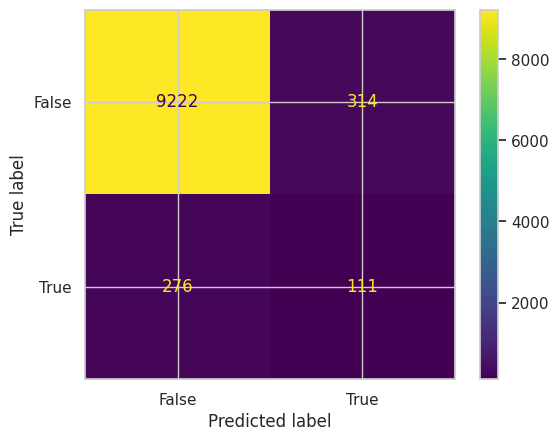

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(mediapipe_comp['manual_tag_int'], predictions)

# Assuming 'cm' from the previous example
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=mediapipe_comp['manual_tag_int'].unique())
disp.plot()
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
# print(classification_report(y_encoded, y_pred, target_names=le.classes_))
print("Confusion Matrix:\n", classification_report(mediapipe_comp['manual_tag_int'], predictions))

Confusion Matrix:
               precision    recall  f1-score   support

       False       0.97      0.97      0.97      9536
        True       0.26      0.29      0.27       387

    accuracy                           0.94      9923
   macro avg       0.62      0.63      0.62      9923
weighted avg       0.94      0.94      0.94      9923



#### Mediapipe: DecisionTreeClassifier (f1=0.23)

Accuracy: 93.85%


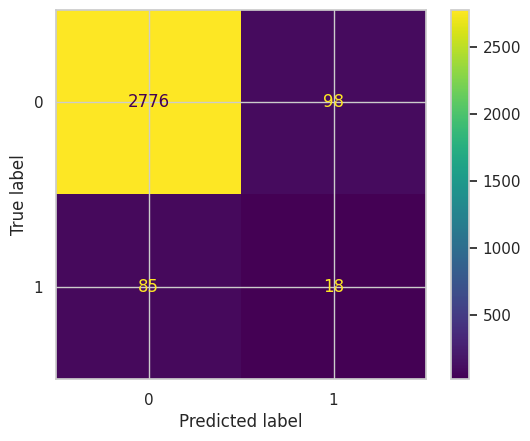

              precision    recall  f1-score   support

       False       0.97      0.97      0.97      2874
        True       0.16      0.17      0.16       103

    accuracy                           0.94      2977
   macro avg       0.56      0.57      0.57      2977
weighted avg       0.94      0.94      0.94      2977



In [ ]:
train_DT(mediapipe_comp[proba_cols], mediapipe_comp['manual_tag_int'])

#### Mediapipe: XBoostClassifier (f1=0.36)

Accuracy: 87.67%


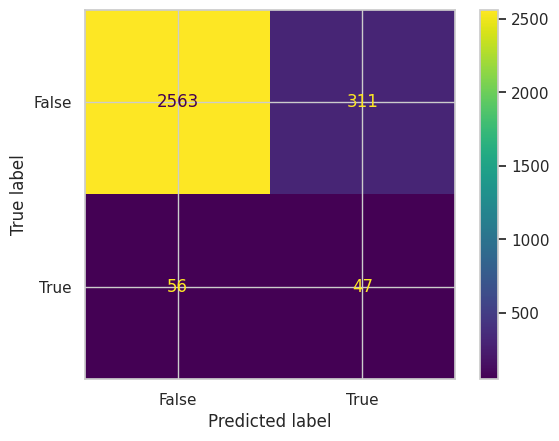

Classification report (w/o threhold tuning):
               precision    recall  f1-score   support

       False       0.98      0.89      0.93      2874
        True       0.13      0.46      0.20       103

    accuracy                           0.88      2977
   macro avg       0.55      0.67      0.57      2977
weighted avg       0.95      0.88      0.91      2977

Optimal threshold: 0.8961696
F1-score: 0.270
Classification report (with threshold tuning):
               precision    recall  f1-score   support

       False       0.97      0.99      0.98      2874
        True       0.44      0.19      0.27       103

    accuracy                           0.96      2977
   macro avg       0.71      0.59      0.63      2977
weighted avg       0.95      0.96      0.96      2977



In [ ]:
train_GB(mediapipe_comp[proba_cols], mediapipe_comp['manual_tag_int'])

#### Mediapipe: SVM (f1=0.36)

Accuracy: 96.93%


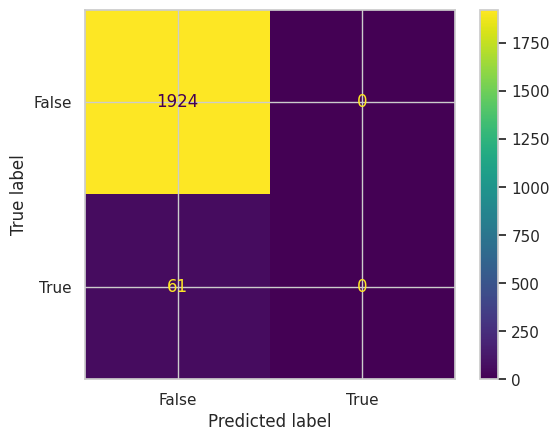

Confusion Matrix (w/o threshold tuning):
               precision    recall  f1-score   support

       False       0.97      1.00      0.98      1924
        True       0.00      0.00      0.00        61

    accuracy                           0.97      1985
   macro avg       0.48      0.50      0.49      1985
weighted avg       0.94      0.97      0.95      1985

Optimal threshold: 0.9927004945681178
F1-score: 0.000
Confusion Matrix (with threshold tuning):
               precision    recall  f1-score   support

       False       0.97      1.00      0.98      1924
        True       0.00      0.00      0.00        61

    accuracy                           0.97      1985
   macro avg       0.48      0.50      0.49      1985
weighted avg       0.94      0.97      0.95      1985



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/tmp/ipykernel_65109/1023690739.py:34: RuntimeWar

In [ ]:
train_SVM(mediapipe_comp[proba_cols], mediapipe_comp['manual_tag_int'])